# Data Mining Project

<div class="alert alert-block">
<b>Step 1:</b> Data Analysis and Preprocessing</div>

_Imports_

In [1]:
import numpy as np
print(np.__version__)


2.2.6


In [1]:
import pandas as pd
import geopandas as gpd # (.shp)
import matplotlib.pyplot as plt
import rasterio # (.tif)
from rasterio.mask import mask
from tqdm import tqdm
import os
import glob
import seaborn as sns
import numpy as np
import pyodbc
from rasterstats import zonal_stats
import pickle
from shapely.geometry import Point 



_Loading Datasets_

In [5]:
save_path = "data/processed/merged_countries_landcover.pkl"

with open(save_path, "rb") as f:
    merged_countries_landcover = pickle.load(f)

save_path = "data/processed/df_wilaya_climate.pkl"

with open(save_path, "rb") as f:
    df_wilaya_climate = pickle.load(f)

save_path = "data/processed/df_tmin.pkl"

with open(save_path, "rb") as f:
    df_tmin = pickle.load(f)

save_path = "data/processed/df_tmax.pkl"

with open(save_path, "rb") as f:
    df_tmax = pickle.load(f)

save_path = "data/processed/df_prec.pkl"

with open(save_path, "rb") as f:
    df_prec = pickle.load(f)

save_path = "data/processed/df_soil.pkl"

with open(save_path, "rb") as f:
    df_soil = pickle.load(f)

save_path = "data/processed/df_mu.pkl"

with open(save_path, "rb") as f:
    df_mu = pickle.load(f)

save_path = "data/processed/df_layers.pkl"

with open(save_path, "rb") as f:
    df_layers = pickle.load(f)

save_path = "data/processed/df_elev.pkl"

with open(save_path, "rb") as f:
    df_elev = pickle.load(f)

save_path = "data/processed/df_d1.pkl"

with open(save_path, "rb") as f:
    df_d1 = pickle.load(f)

save_path = "data/processed/merged_countries_landcover_no_legend.pkl"

with open(save_path, "rb") as f:
    merged_countries_landcover_no_legend = pickle.load(f)

save_path = "data/processed/Fire_with_climate.pkl"

with open(save_path, "rb") as f:
       df_fire_with_climate = pickle.load(f)


""" save_path = "data/processed/df_fire_climate_land_cover_elevation.pkl"

with open(save_path, "rb") as f:
       df_fire_landcover_final_2 = pickle.load(f)   """  
       
""" save_path = "data/processed/df_pixels.pkl"

with open(save_path, "rb") as f:
       df_pixels = pickle.load(f)    """

""" save_path = "data/processed/df_fire_landcover_final_3.pkl"

with open(save_path, "rb") as f:
       df_fire_landcover_final_3 = pickle.load(f)    

save_path = "data/processed/df_fire_landcover_final_4.pkl"

with open(save_path, "rb") as f:
       df_fire_landcover_final_4 = pickle.load(f)      

save_path = "data/processed/df_fire_landcover_final_5.pkl"

with open(save_path, "rb") as f:
       df_fire_landcover_final_5 = pickle.load(f)   """       

save_path = "data/processed/df_fire_landcover_final_cut.pkl"

with open(save_path, "rb") as f:
       df_fire_landcover_final_cut = pickle.load(f)        
        

    

<div class="alert alert-block alert-success">
<b>Step 1.1</b> Exploratory Data Analysis (EDA)
</div>

# _Data Loading + Clipping_

## Fire Dataset

`Here we load the datasets and read them + fuse alg and tun`

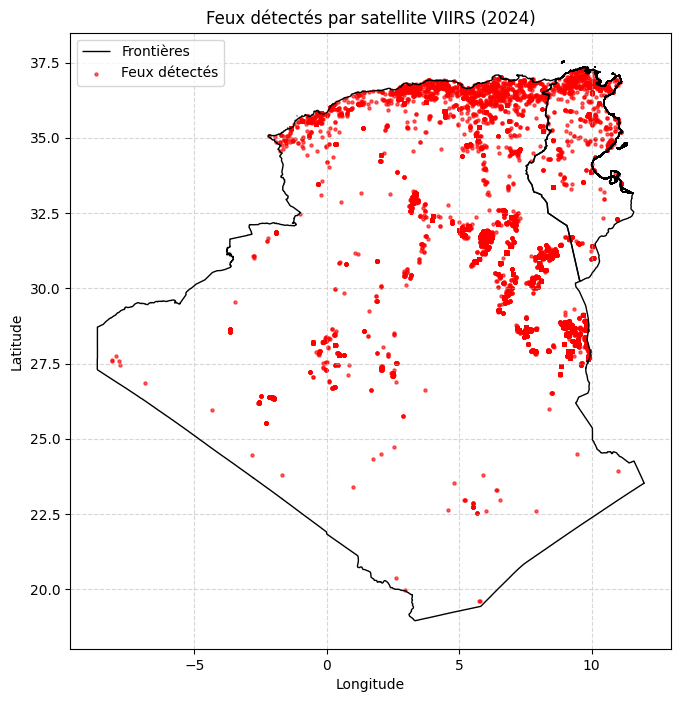

In [46]:
#Lecture des données CSV
fire_dz = pd.read_csv("Datasets/Fire_Dataset/viirs-jpss1_2024_Algeria.csv")
fire_tun = pd.read_csv("Datasets/Fire_Dataset/viirs-jpss1_2024_Tunisia.csv")

# rajouter une colonne 'country' pour le regroupement de datasets 
fire_dz["country"] = "Algeria"
fire_tun["country"] = "Tunisia"

# Fusion des deux datasets
fire_all = pd.concat([fire_dz, fire_tun], ignore_index=True)

# Conversion en GeoDataFrame
gdf_fire = gpd.GeoDataFrame(
    fire_all,
    geometry=gpd.points_from_xy(fire_all["longitude"], fire_all["latitude"]),
    crs="EPSG:4326"   # Coordonnées géographiques (degrés)
)

# Lecture des shapefiles
algeria = gpd.read_file("Datasets/dz_shp/gadm41_DZA_0.shp")
tunisia = gpd.read_file("Datasets/tun_shp/gadm41_TUN_shp/gadm41_TUN_0.shp")

# Harmonisation du système de coordonnées
algeria = algeria.to_crs("EPSG:4326")
tunisia = tunisia.to_crs("EPSG:4326")

# Fusion des shapefiles (Algérie + Tunisie)
north_africa = pd.concat([algeria, tunisia])


# Affichage
fig, ax = plt.subplots(figsize=(8, 8))

north_africa.boundary.plot(ax=ax, color='black', linewidth=1, label='Frontières')
gdf_fire.plot(ax=ax, color='red', markersize=5, alpha=0.6, label='Feux détectés')

"""
algeria.boundary.plot(ax=ax, color='black', linewidth=1, label='Frontière Algérie')
tunisia.boundary.plot(ax=ax, color='gray', linewidth=1, label='Frontière Tunisie')

# Points
gdf_fire[gdf_fire["country"] == "Algeria"].plot(ax=ax, color='red', markersize=5, alpha=0.6, label='Feux Algérie')
gdf_fire[gdf_fire["country"] == "Tunisia"].plot(ax=ax, color='blue', markersize=5, alpha=0.6, label='Feux Tunisie')
"""

plt.title("Feux détectés par satellite VIIRS (2024)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [47]:
gdf_fire.head()

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,country,geometry
0,27.72818,9.87200,295.51,0.76,0.77,2024-01-01,3,N20,VIIRS,n,2,277.66,1.24,N,2,Algeria,POINT (9.872 27.72818)
1,28.63288,9.77909,301.80,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.05,1.57,N,2,Algeria,POINT (9.77909 28.63288)
2,28.64012,9.77953,298.65,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.04,1.34,N,2,Algeria,POINT (9.77953 28.64012)
3,36.74886,6.25409,338.04,0.46,0.39,2024-01-01,141,N20,VIIRS,n,2,257.28,5.21,N,2,Algeria,POINT (6.25409 36.74886)
4,35.87978,4.44782,309.49,0.41,0.37,2024-01-01,141,N20,VIIRS,n,2,272.08,1.58,N,2,Algeria,POINT (4.44782 35.87978)


## Land Cover Dataset

### _Algeria_

#### 1-Loading the Algeria Shapefile

In [4]:
# load the shapefile
algeria_shapefile = gpd.read_file('Datasets/Land_Cover_Dataset/DZA/dza_gc_adg.shp')

# show basic info
print(algeria_shapefile.head())
print(algeria_shapefile.crs) #coordinate system

   ID  GRIDCODE          AREA       LCCCODE  \
0   4       210  6.228187e+06  7001 // 8001   
1   2       210  6.242408e+06  7001 // 8001   
2   1       210  1.482995e+06  7001 // 8001   
3   8        50  4.590841e+08  21497-121340   
4  13       210  6.371533e+06  7001 // 8001   

                                            geometry  
0  POLYGON ((6.41528 37.08696, 6.43103 37.0855, 6...  
1  POLYGON ((7.18084 37.07917, 7.17998 37.08091, ...  
2  POLYGON ((7.37137 37.08194, 7.3709 37.08717, 7...  
3  POLYGON ((6.12361 36.68472, 6.12361 36.69306, ...  
4  POLYGON ((6.26181 37.02361, 6.26193 37.02514, ...  
EPSG:4326


#### 2-Visualisation

<Axes: >

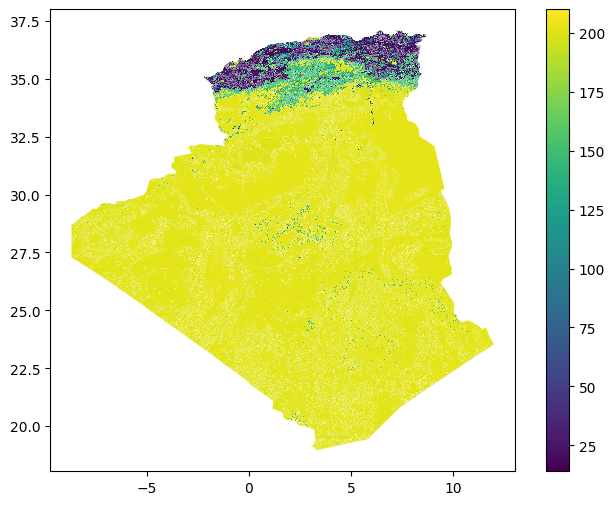

In [4]:
algeria_shapefile.plot(column="GRIDCODE", legend=True, figsize=(8,6))

#### 3-With Legend

`Here we're merging in the africa legend but with a twist: instead of keeping all africa's legend we'll only keep the algeria legend part`

In [5]:
# Load legend
legend = pd.read_excel('Datasets/Land_Cover_Dataset/DZA/globcover_LCCS_legend_africa.xls')

# Convert MapCode to numeric (ignore invalid entries)
legend['MapCode'] = pd.to_numeric(legend['MapCode'], errors='coerce')

# Keep only codes present in Algeria shapefile
used_codes = algeria_shapefile['GRIDCODE'].unique()
legend_filtered = legend[legend['MapCode'].isin(used_codes)]

# Merge only the relevant legend entries
merged_alg = algeria_shapefile.merge(legend_filtered, left_on="GRIDCODE", right_on="MapCode", how="left")


C:\Users\dell\AppData\Local\Temp\ipykernel_18792\454061393.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


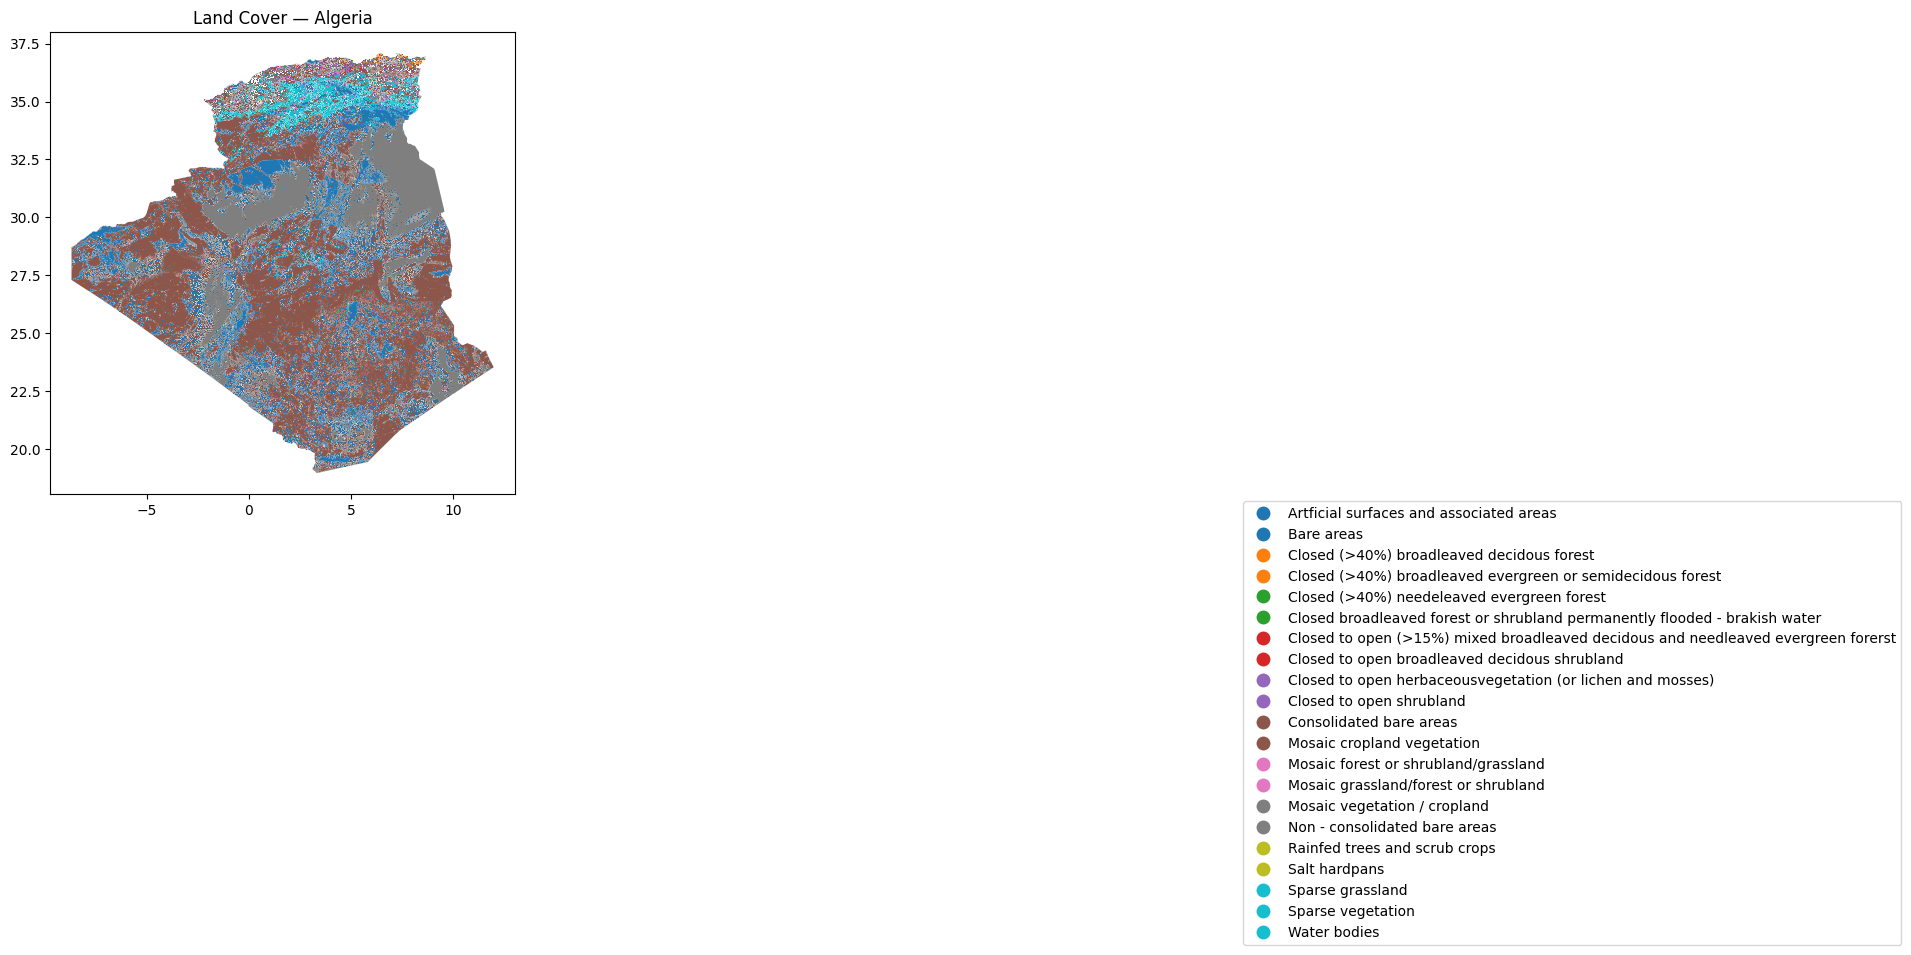

In [6]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
merged_alg.plot(column="LCCOwnLabel", legend=True, ax=ax)
# Move the legend outside the plot area
leg = ax.get_legend()
if leg is not None:
    leg.set_bbox_to_anchor((4, 0))  # (x, y) position outside the map
    leg._legend_box.align = "left"

ax.set_title("Land Cover — Algeria")
plt.tight_layout()
plt.show()

### _Tunisia_

#### 1-Loading the Algeria Shapefile

In [5]:
# load the shapefile
tunisia_shapefile = gpd.read_file("Datasets/Land_Cover_Dataset/TUN/tun_gc_adg.shp")

# show basic info
print(tunisia_shapefile.head())
print(tunisia_shapefile.crs) #coordinate system

     AREA_M2  ID  GRIDCODE                  LCCCode  \
0  3110936.0   1       210             7001 // 8001   
1   982723.0   3        20              0003 / 0004   
2   151388.0   2        30             0004 // 0003   
3   151391.0   6       120  21454 // 21446 // 21450   
4   151391.0   4        70             21499-121340   

                                            geometry  
0  POLYGON ((8.89941 37.52083, 8.89923 37.52117, ...  
1  POLYGON ((8.94028 37.52361, 8.94028 37.52917, ...  
2  POLYGON ((8.94583 37.53472, 8.94861 37.53472, ...  
3  POLYGON ((8.91528 37.52917, 8.91528 37.53194, ...  
4  POLYGON ((8.93194 37.53194, 8.9375 37.53194, 8...  
EPSG:4326


#### 2-Visualisation

<Axes: >

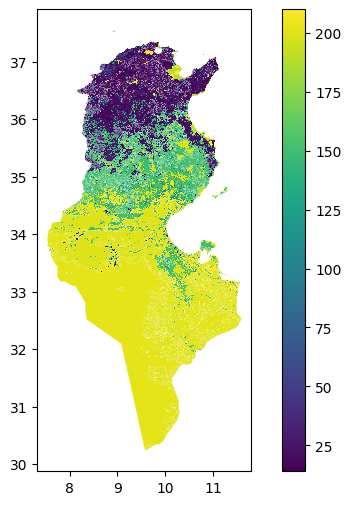

In [8]:
tunisia_shapefile.plot(column="GRIDCODE", legend=True, figsize=(8,6))

#### 3-With legend

In [9]:
# Load legend
legend_tun = pd.read_excel('Datasets/Land_Cover_Dataset/DZA/globcover_LCCS_legend_africa.xls')

# Convert MapCode to numeric (ignore invalid entries)
legend_tun['MapCode'] = pd.to_numeric(legend['MapCode'], errors='coerce')

# Keep only codes present in Algeria shapefile
used_codes = tunisia_shapefile['GRIDCODE'].unique()
legend_tun_filtered = legend_tun[legend['MapCode'].isin(used_codes)]

# Merge only the relevant legend entries
merged_tun = tunisia_shapefile.merge(legend_tun_filtered, left_on="GRIDCODE", right_on="MapCode", how="left")

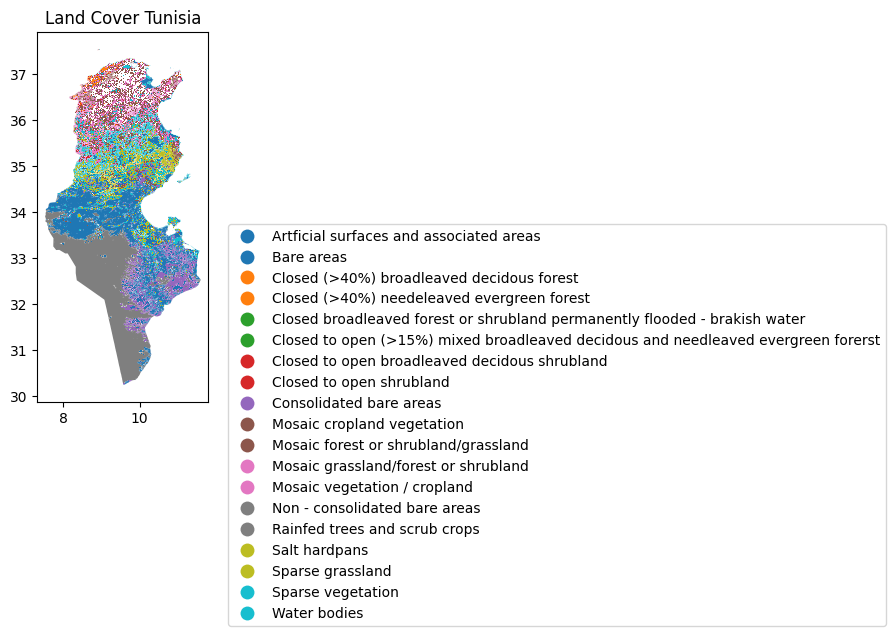

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
merged_tun.plot(column="LCCOwnLabel", legend=True, ax=ax)

# Move the legend outside the plot area
leg = ax.get_legend()
if leg is not None:
    leg.set_bbox_to_anchor((5, 0.5))  # (x, y) position outside the map
    leg._legend_box.align = "left"

ax.set_title("Land Cover Tunisia")
plt.tight_layout()
plt.show()

### _Concatenation of Algeria and Tunisia without Legend_

In [10]:
algeria_shapefile = algeria_shapefile.rename(columns={'AREA': 'AREA_M2', 'LCCCODE': 'LCCCode'})

In [11]:
common_cols = list(set(algeria_shapefile.columns) & set(tunisia_shapefile.columns))
merged_countries_landcover_no_legend = gpd.GeoDataFrame(
    pd.concat([algeria_shapefile[common_cols], tunisia_shapefile[common_cols]], ignore_index=True),
    crs=algeria_shapefile.crs
)

In [8]:
print(algeria_shapefile.columns)


Index(['ID', 'GRIDCODE', 'AREA', 'LCCCODE', 'geometry'], dtype='object')


In [9]:
print(tunisia_shapefile.columns)

Index(['AREA_M2', 'ID', 'GRIDCODE', 'LCCCode', 'geometry'], dtype='object')


In [12]:
print(merged_countries_landcover_no_legend.columns)


Index(['ID', 'AREA_M2', 'geometry', 'LCCCode', 'GRIDCODE'], dtype='object')


### _Concatenation of Algeria and Tunisia with Legend_

In [11]:
common_cols = list(set(merged_alg.columns) & set(merged_tun.columns))
merged_countries_landcover = gpd.GeoDataFrame(
    pd.concat([merged_alg[common_cols], merged_tun[common_cols]], ignore_index=True),
    crs=algeria_shapefile.crs
)

In [12]:
print(merged_countries_landcover.columns)


Index(['LCCLevel', 'LCCOwnLabel', 'GRIDCODE', 'LPos', 'LCCOwnDescr', 'ID',
       'MapCode', 'geometry', 'LCCLabel', 'LCCMode', 'LC'],
      dtype='object')


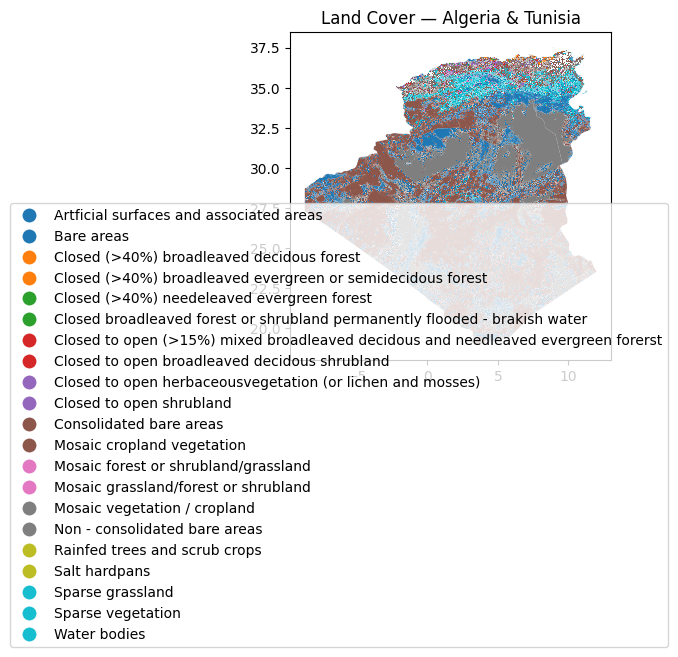

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
merged_countries_landcover.plot(column="LCCOwnLabel", legend=True, ax=ax)

# Move the legend outside the plot area
leg = ax.get_legend()
if leg is not None:
    leg.set_bbox_to_anchor((1.2, 0.5))  # (x, y) position outside the map
    leg._legend_box.align = "left"

ax.set_title("Land Cover — Algeria & Tunisia")
plt.tight_layout()
plt.show()

## Climate Dataset

`Here we will reuse the shapefile north_africa that we already loaded`

In [14]:
print(north_africa.shape)

(2, 3)


#### Loading the list of .tif files

In [31]:
climate_prec = glob.glob("Datasets/Climate/wc2.1_cruts4.09_5m_prec_2020-2024/*.tif")
climate_max  = glob.glob("Datasets/Climate/wc2.1_cruts4.09_5m_tmax_2020-2024/*.tif")
climate_min  = glob.glob("Datasets/Climate/wc2.1_cruts4.09_5m_tmin_2020-2024/*.tif")

#### Output Directory

In [32]:
# Separate output folders
output_dir_prec = "Datasets\Climate\clip_prec"
output_dir_tmax = "Datasets\Climate\clip_tmax"
output_dir_tmin = "Datasets\Climate\clip_tmin"

# Create folders if they don't exist
os.makedirs(output_dir_prec, exist_ok=True)
os.makedirs(output_dir_tmax, exist_ok=True)
os.makedirs(output_dir_tmin, exist_ok=True)

#### Clipping function

In [33]:
# Clipping function
def clip_raster(raster_path, shape, output_dir):
    try:
        with rasterio.open(raster_path) as src:
            # Reproject shapefile if needed
            shape = shape.to_crs(src.crs)
            # Clip raster
            out_image, out_transform = mask(src, shape.geometry, crop=True)
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform
            })
            # Save clipped raster
            out_path = os.path.join(output_dir, os.path.basename(raster_path))
            with rasterio.open(out_path, "w", **out_meta) as dest:
                dest.write(out_image)
            print(f"Clip terminé pour : {os.path.basename(raster_path)}")
    except Exception as e:
        print(f"Erreur sur {os.path.basename(raster_path)} : {e}")

# CLIP EACH TYPE INTO ITS FOLDER
print("\nClipping precipitation rasters...")
for path in climate_prec:
    clip_raster(path, north_africa, output_dir_prec)

print("\nClipping max temperature rasters...")
for path in climate_max:
    clip_raster(path, north_africa, output_dir_tmax)

print("\nClipping min temperature rasters...")
for path in climate_min:
    clip_raster(path, north_africa, output_dir_tmin)



Clipping precipitation rasters...
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2020-01.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2020-02.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2020-03.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2020-04.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2020-05.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2020-06.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2020-07.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2020-08.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2020-09.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2020-10.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2020-11.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2020-12.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2021-01.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2021-02.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2021-03.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2021-04.tif
Clip terminé pour : wc2.1_cruts4.09_5m_prec_2021-05.tif
Clip terminé 

#### Visualisation

In [15]:
def visualiser_type_climat(region_nom, folder_path, climate_type, show_all=False):
    """Visualise un type spécifique de données climatiques pour la région."""

    # Définir les informations selon le type de climat
    climate_info = {
        'prec': {'unit': 'Précipitations (mm)', 'title': 'Précipitations', 'cmap': 'YlGnBu'},
        'tmax': {'unit': 'Température maximale (°C)', 'title': 'Températures maximales', 'cmap': 'hot'},
        'tmin': {'unit': 'Température minimale (°C)', 'title': 'Températures minimales', 'cmap': 'cool'}
    }

    print(f"VISUALISATION {region_nom.upper()} - {climate_info[climate_type]['title']}")

    # Liste des fichiers dans le dossier
    files = sorted(glob.glob(os.path.join(folder_path, "*.tif")))
    if not files:
        print(f"Aucun fichier trouvé dans {folder_path}")
        return

    # Choisir les fichiers à afficher
    files_to_show = files if show_all else [files[0]]

    for file_path in files_to_show:
        with rasterio.open(file_path) as src:
            data = src.read(1)
            data = np.where(data == src.nodata, np.nan, data)  # gérer les valeurs nodata
            extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

        # Affichage avec matplotlib
        plt.figure(figsize=(8, 6))
        plt.imshow(data, cmap=climate_info[climate_type]['cmap'], extent=extent)
        plt.colorbar(label=climate_info[climate_type]['unit'])
        plt.title(f"{region_nom} – {climate_info[climate_type]['title']}\n{os.path.basename(file_path)}")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.show()


VISUALISATION NORTH AFRICA - Précipitations


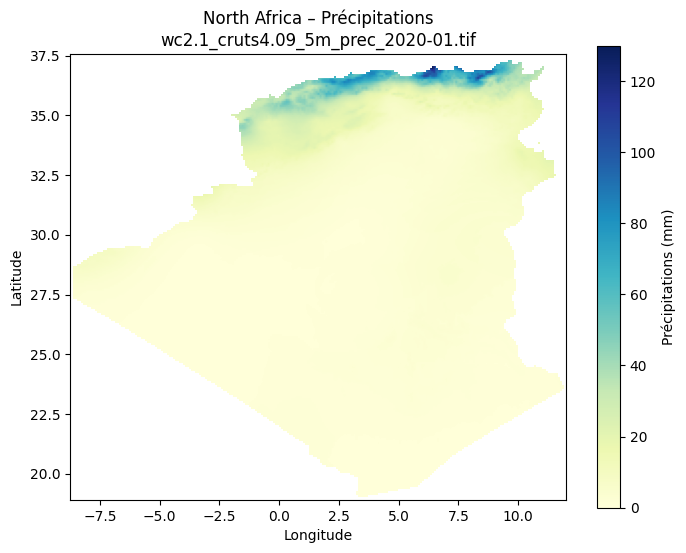

VISUALISATION NORTH AFRICA - Températures maximales


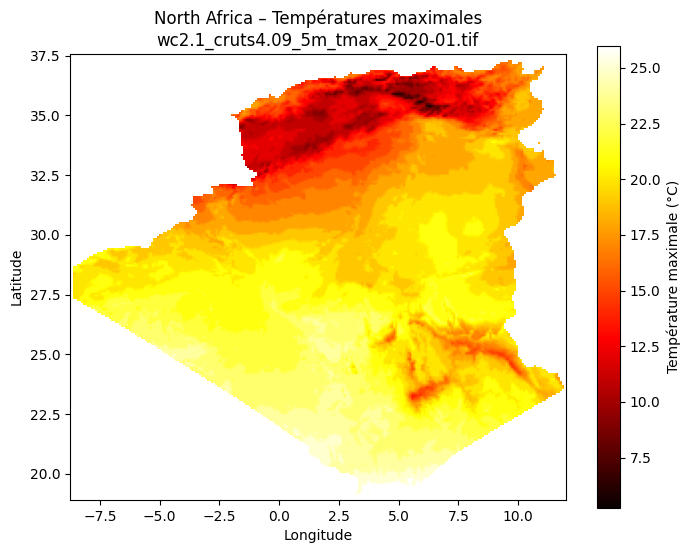

VISUALISATION NORTH AFRICA - Températures minimales


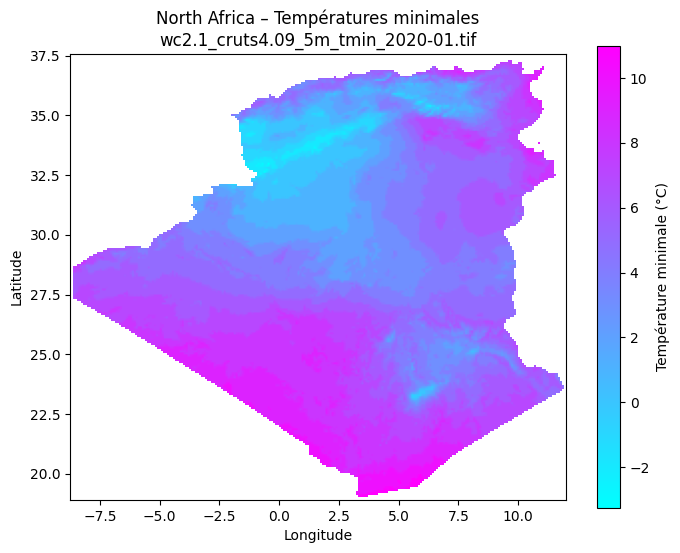

In [16]:
# Visualiser le premier raster de précipitations pour North Africa
visualiser_type_climat("North Africa", "Datasets\Climate\clip_prec", "prec")

# Visualiser tous les fichiers de tmax
visualiser_type_climat("North Africa", "Datasets\Climate\clip_tmax", "tmax")

#tmin
visualiser_type_climat("North Africa", "Datasets\Climate\clip_tmin", "tmin")


## Elevation Dataset

#### 1-Clipping

`Here we are clipping adf files to algeria+tunisia only, the output file is in .tif extension because we are using the rastrio library`

`when executing this cell comment out the function call to not redo all the clipping process`

In [ ]:
# Chemin du raster d'élévation
elevation_path = "Datasets/Elevation/be15_grd/be15_grd/w001001.adf"

# Dossier de sortie unique
output_elev_all = "Datasets/Elevation/clip_north_africa"
os.makedirs(output_elev_all, exist_ok=True)

# Fonction de clipping
def clip_raster_elevation(raster_path, shape, output_path):
    with rasterio.open(raster_path) as src:
        # S’assurer que le shapefile est dans la même projection
        shape = shape.to_crs(src.crs)
        # Clip du raster
        out_image, out_transform = mask(src, shape.geometry, crop=True)
        out_meta = src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })
        with rasterio.open(output_path, "w", **out_meta) as dest:
            dest.write(out_image)
        print(f" Clip terminé pour : {output_path}")

# === Clip unique pour l'ensemble Algérie + Tunisie ===
output_file_all = os.path.join(output_elev_all, "elevation_north_africa.tif")
clip_raster_elevation(elevation_path, north_africa, output_file_all)



#### 2-Visualisation

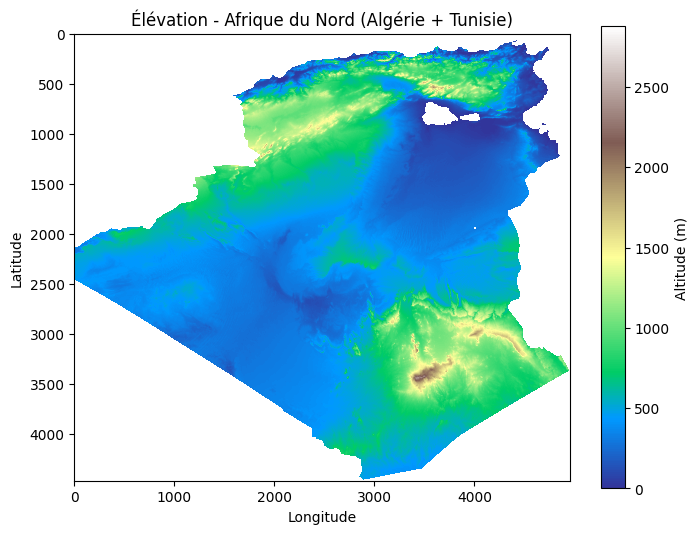

In [19]:
# Fonction de visualisation
def visualize_elevation(file_path, region_name):
    with rasterio.open(file_path) as src:
        data = src.read(1)
        data = np.where(data < 0, np.nan, data)  # masque les valeurs négatives aberrantes
        plt.figure(figsize=(8,6))
        img = plt.imshow(data, cmap='terrain')
        plt.colorbar(img, label='Altitude (m)')
        plt.title(f"Élévation - {region_name}")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.show()

visualize_elevation(output_file_all, "Afrique du Nord (Algérie + Tunisie)")


## Soil Dataset

#### 1- Loading the HWSD2_LAYERS Table + Selecting columns

In [9]:
mdb_path = "Datasets\Soil\HWSD2\data\HWSD2.mdb"

conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)

conn = pyodbc.connect(conn_str)

# Lecture des tables utiles
df_layers = pd.read_sql("SELECT * FROM HWSD2_LAYERS", conn)
df_mu = pd.read_sql("SELECT * FROM HWSD2_SMU", conn)
conn.close()

print("\n Tables chargées :")
print("HWSD2_LAYERS →", df_layers.shape)
print("HWSD2_MU_GLOBAL →", df_mu.shape)


# Garder uniquement la couche D1 (0–20 cm)
df_d1 = df_layers[df_layers["LAYER"] == "D1"]

cols = [
    "COARSE", "SAND", "SILT", "CLAY", "TEXTURE_USDA", "TEXTURE_SOTER",
    "BULK", "REF_BULK", "ORG_CARBON", "PH_WATER", "TOTAL_N", "CN_RATIO",
    "CEC_SOIL", "CEC_CLAY", "CEC_EFF", "TEB", "BSAT", "ALUM_SAT", "ESP",
    "TCARBON_EQ", "GYPSUM", "ELEC_COND"
]

df_soil = df_d1[cols]
print("\n Caractéristiques de la couche D1 extraites :")
print(df_soil.head())

C:\Users\dell\AppData\Local\Temp\ipykernel_10892\3978259246.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_layers = pd.read_sql("SELECT * FROM HWSD2_LAYERS", conn)
C:\Users\dell\AppData\Local\Temp\ipykernel_10892\3978259246.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_mu = pd.read_sql("SELECT * FROM HWSD2_SMU", conn)



 Tables chargées :
HWSD2_LAYERS → (408835, 48)
HWSD2_MU_GLOBAL → (29538, 23)

 Caractéristiques de la couche D1 extraites :
     COARSE  SAND  SILT  CLAY  TEXTURE_USDA TEXTURE_SOTER  BULK  REF_BULK  \
666       5    67    18    15          11.0             C  1.35      1.63   
667       5    67    18    15          11.0             C  1.35      1.63   
668       5    67    18    15          11.0             C  1.35      1.63   
669       5    67    18    15          11.0             C  1.35      1.63   
694       2    24    52    24           7.0             M  1.44      1.76   

     ORG_CARBON  PH_WATER  ...  CEC_SOIL  CEC_CLAY  CEC_EFF  TEB  BSAT  \
666       1.062       6.3  ...         8        46      6.0  5.0    59   
667       1.062       6.3  ...         8        46      6.0  5.0    59   
668       1.062       6.3  ...         8        46      6.0  5.0    59   
669       1.062       6.3  ...         8        46      6.0  5.0    59   
694       1.475       5.2  ...         9  

In [10]:
# Folder path
save_dir = "data/processed"
os.makedirs(save_dir, exist_ok=True)  # Create folder if it doesn't exist

# File path
save_path = os.path.join(save_dir, "df_layers.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(df_layers, f);

# File path
save_path = os.path.join(save_dir, "df_mu.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(df_mu, f);

# File path
save_path = os.path.join(save_dir, "df_d1.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(df_d1, f);

# File path
save_path = os.path.join(save_dir, "df_soil.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(df_soil, f);

#### 2- Connecting dimensiions with data + Clipping

In [11]:
# Lier la dimension spatiale (la carte du monde des sols) avec les données tabulaires de la base .mdb.
raster_path = "Datasets/Soil/HWSD2/data/HWSD2_RASTER/HWSD2.bil"
output_dir = "Datasets/Soil/Clip"
os.makedirs(output_dir, exist_ok=True)

def clip_raster(raster_path, shape, output_path):
    with rasterio.open(raster_path) as src:
        # Adapter le shapefile au CRS du raster
        shape = shape.to_crs(src.crs)
        out_image, out_transform = mask(src, shape.geometry, crop=True)
        
        out_meta = src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })
        
        with rasterio.open(output_path, "w", **out_meta) as dest:
            dest.write(out_image)
        print(f" Clip terminé → {output_path}")

# Clip combiné
north_africa_clip = os.path.join(output_dir, "hwsd2_north_africa.tif")
#clip_raster(raster_path, north_africa, north_africa_clip)



#### 3- Plotting

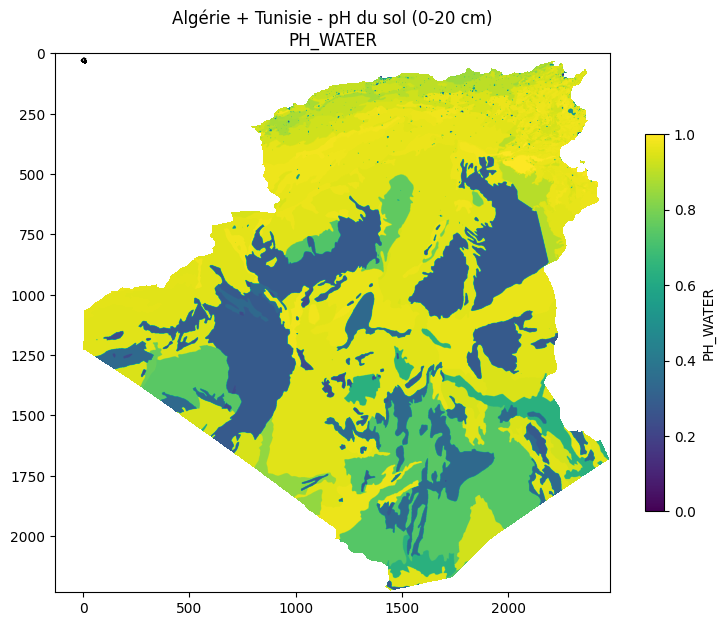

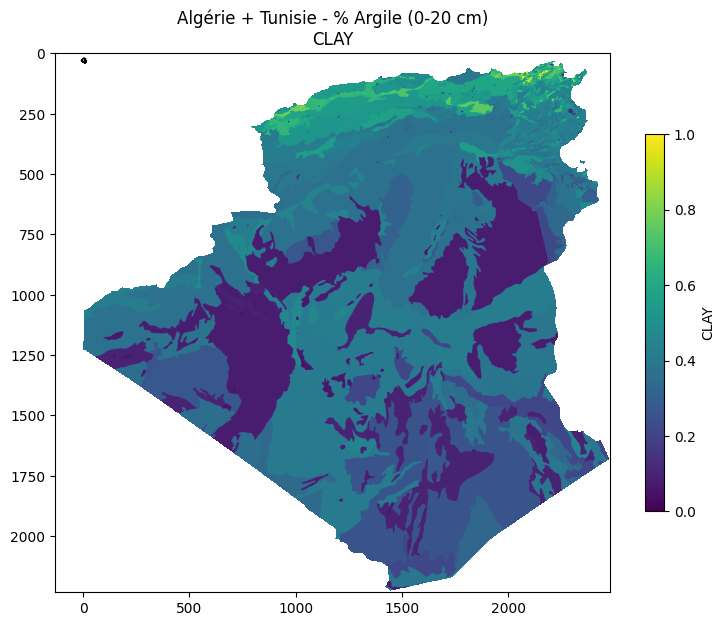

In [12]:
def plot_soil_map(raster_path, shape, df_mu, df_layers, feature_name, title):
    """Affiche la carte du pays avec les valeurs du feature choisi (HWSD2)."""

    # Harmonisation des noms de colonnes (en majuscules)
    df_mu.columns = df_mu.columns.str.upper()
    df_layers.columns = df_layers.columns.str.upper()

    with rasterio.open(raster_path) as src:
        raster = src.read(1).astype("float32")  # conversion en float pour accepter np.nan
        nodata = src.nodata

        if nodata is not None:
            raster[raster == nodata] = np.nan
        else:
            print(" \n Aucun pixel nodata défini dans le raster.")
        transform = src.transform

    # Identifier les unités de sol présentes dans le raster
    valid_mask = ~np.isnan(raster)
    mu_ids = np.unique(raster[valid_mask]).astype(int)

    # Filtrer les unités de sol présentes
    df_sel = df_mu[df_mu["HWSD2_SMU_ID"].isin(mu_ids)]

    # Jointure avec la table des couches (0–20 cm)
    df_merged = df_sel.merge(
        df_layers[df_layers["LAYER"] == "D1"],
        on="HWSD2_SMU_ID",
        how="left"
    )

    # Calculer la moyenne du paramètre choisi par unité de sol
    feature_table = df_merged.groupby("HWSD2_SMU_ID")[feature_name].mean()

    # Remplacer les identifiants dans le raster par les valeurs du feature
    raster_feature = np.copy(raster)
    for mu, val in feature_table.items():
        raster_feature[raster == mu] = val

    # --- AFFICHAGE ---
    plt.figure(figsize=(9, 7))
    plt.imshow(raster_feature, cmap="viridis", origin="upper")
    shape.boundary.plot(ax=plt.gca(), color="black", linewidth=1)
    plt.title(f"{title}\n{feature_name}")
    cbar = plt.colorbar(
        plt.cm.ScalarMappable(cmap="viridis"),
        ax=plt.gca(),
        orientation="vertical",
        shrink=0.7
    )
    cbar.set_label(feature_name)
    plt.show()

output_dir = "Datasets/Soil/Clip"
north_africa_clip = os.path.join(output_dir, "hwsd2_north_africa.tif")

# Affichage exemple : pH et % argile
plot_soil_map(north_africa_clip, north_africa, df_mu, df_layers, "PH_WATER", "Algérie + Tunisie - pH du sol (0-20 cm)")
plot_soil_map(north_africa_clip, north_africa, df_mu, df_layers, "CLAY", "Algérie + Tunisie - % Argile (0-20 cm)")


# _Data Exploratory Analysis_

## _Fire Datasets_

# __Univariate analysis__

### Measuring Central tendencies

In [51]:
print("\n Aperçu des données ")
print(gdf_fire.head())

print("\n Informations générales ")
print(gdf_fire.info())  

print("\n Statistiques descriptives ")
print(gdf_fire.describe())

print("\n Nombre total de feux par pays ")
print(gdf_fire["country"].value_counts())


 Aperçu des données 
   latitude  longitude  bright_ti4  scan  track    acq_date  acq_time  \
0  27.72818    9.87200      295.51  0.76   0.77  2024-01-01         3   
1  28.63288    9.77909      301.80  0.79   0.78  2024-01-01         3   
2  28.64012    9.77953      298.65  0.79   0.78  2024-01-01         3   
3  36.74886    6.25409      338.04  0.46   0.39  2024-01-01       141   
4  35.87978    4.44782      309.49  0.41   0.37  2024-01-01       141   

  satellite instrument confidence  version  bright_ti5   frp daynight  type  \
0       N20      VIIRS          n        2      277.66  1.24        N     2   
1       N20      VIIRS          n        2      277.05  1.57        N     2   
2       N20      VIIRS          n        2      277.04  1.34        N     2   
3       N20      VIIRS          n        2      257.28  5.21        N     2   
4       N20      VIIRS          n        2      272.08  1.58        N     2   

   country                  geometry  
0  Algeria    POINT (9.87

In [64]:
cols_numeriques = gdf_fire.select_dtypes(include=["float64", "int64"]).columns

print("\n MOYENNE (Mean)")
print(gdf_fire[cols_numeriques].mean())

print("\n MÉDIANE (Median)")
print(gdf_fire[cols_numeriques].median())

print("\n MODE (Mode)")
print(gdf_fire[cols_numeriques].mode().iloc[0])



 MOYENNE (Mean)
latitude       31.476760
longitude       6.280033
bright_ti4    321.091793
scan            0.475991
track           0.515446
acq_time      380.331623
version         2.000000
bright_ti5    291.726092
frp             3.447776
type            1.690936
dtype: float64

 MÉDIANE (Median)
latitude       31.409125
longitude       6.557880
bright_ti4    316.710000
scan            0.450000
track           0.490000
acq_time      140.000000
version         2.000000
bright_ti5    290.790000
frp             2.060000
type            2.000000
dtype: float64

 MODE (Mode)
latitude       31.66165
longitude       6.05312
bright_ti4    367.00000
scan            0.39000
track           0.36000
acq_time      200.00000
version         2.00000
bright_ti5    293.88000
frp             0.85000
type            2.00000
Name: 0, dtype: float64


for bright_ti4

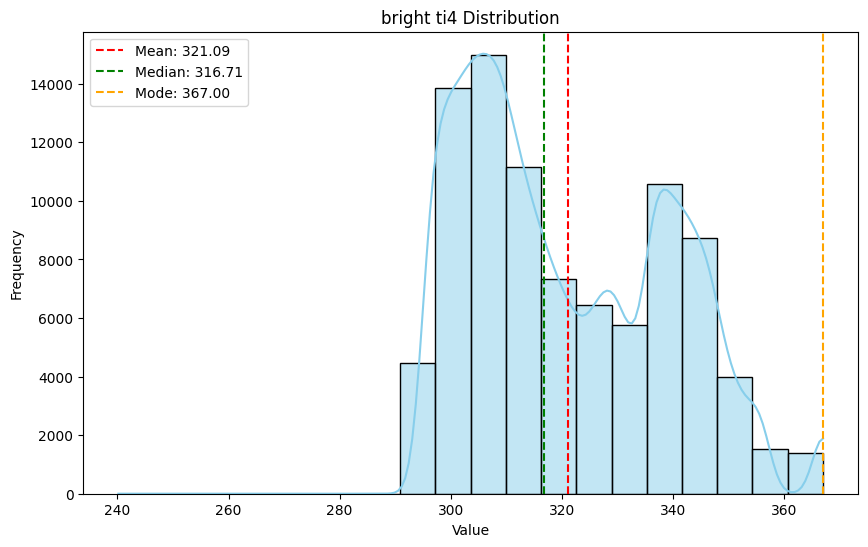

In [55]:
# Compute statistics
mean_val = gdf_fire["bright_ti4"].mean()
median_val = gdf_fire["bright_ti4"].median()
mode_val = gdf_fire["bright_ti4"].mode().iloc[0]

# Plot
plt.figure(figsize=(10,6))
sns.histplot(gdf_fire["bright_ti4"], bins=20, kde=True, color='skyblue')

# Plot mean, median, mode
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
plt.axvline(mode_val, color='orange', linestyle='--', label=f'Mode: {mode_val:.2f}')

plt.title(f"bright ti4 Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

`It's negatively skewed`

for bright ti5

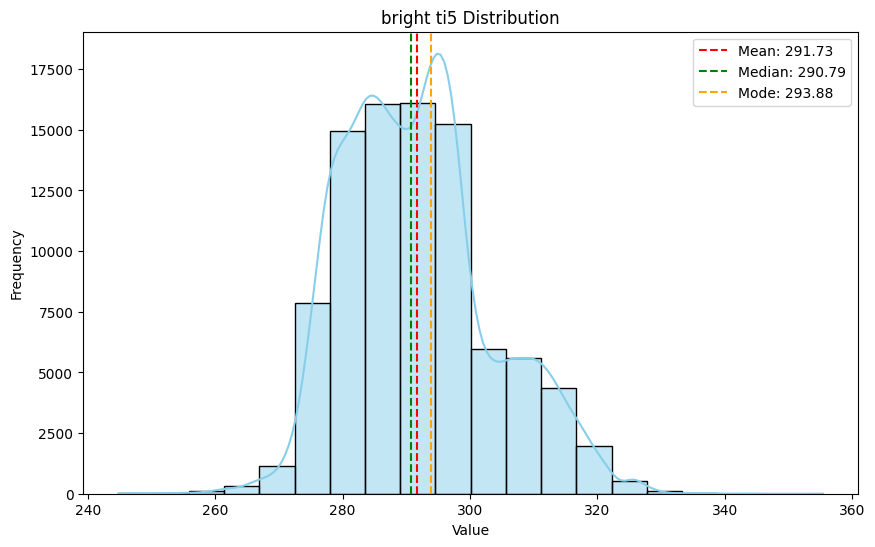

In [57]:
# Compute statistics
mean_val = gdf_fire["bright_ti5"].mean()
median_val = gdf_fire["bright_ti5"].median()
mode_val = gdf_fire["bright_ti5"].mode().iloc[0]

# Plot
plt.figure(figsize=(10,6))
sns.histplot(gdf_fire["bright_ti5"], bins=20, kde=True, color='skyblue')

# Plot mean, median, mode
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
plt.axvline(mode_val, color='orange', linestyle='--', label=f'Mode: {mode_val:.2f}')

plt.title(f"bright ti5 Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

`Symmetrical distribution!`

for frp

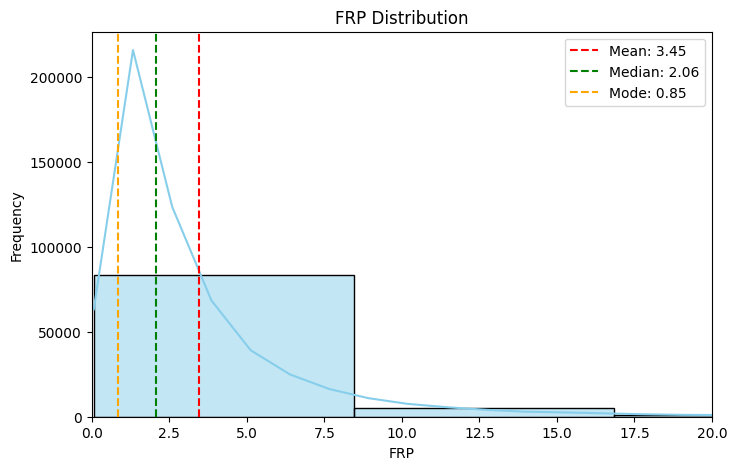

In [63]:
# Compute statistics
mean_val = gdf_fire["frp"].mean()
median_val = gdf_fire["frp"].median()
mode_val = gdf_fire["frp"].mode().iloc[0]

# Plot
plt.figure(figsize=(8,5))
sns.histplot(gdf_fire["frp"], bins=30, kde=True, color='skyblue')

# Plot mean, median, mode
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
plt.axvline(mode_val, color='orange', linestyle='--', label=f'Mode: {mode_val:.2f}')

# Zoom in on the bulk of the data (adjust depending on your data)
plt.xlim(0, 20)  # <-- change this to fit your “small value” range

plt.title(f"FRP Distribution")
plt.xlabel("FRP")
plt.ylabel("Frequency")
plt.legend()
plt.show()

`Positively skewed`

### Measuring Data Dispersion

In [65]:
print("\n ÉCART-TYPE (Standard Deviation)")
print(gdf_fire[cols_numeriques].std())

print("\n QUARTILES (Q1, Q2, Q3)")
print(gdf_fire[cols_numeriques].quantile([0.25, 0.5, 0.75])) 

print("\n MINIMUM (Min)")
print(gdf_fire[cols_numeriques].min())

print("\n MAXIMUM (Max)")
print(gdf_fire[cols_numeriques].max())

print("\n ÉTENDUE (Range)")
print(gdf_fire[cols_numeriques].max() - gdf_fire[cols_numeriques].min())


 ÉCART-TYPE (Standard Deviation)
latitude        2.666477
longitude       2.593748
bright_ti4     18.205551
scan            0.101596
track           0.126508
acq_time      480.710563
version         0.000000
bright_ti5     11.700269
frp             5.222111
type            0.735207
dtype: float64

 QUARTILES (Q1, Q2, Q3)
       latitude  longitude  bright_ti4  scan  track  acq_time  version  \
0.25  28.911510   5.642160      305.38  0.40   0.39      59.0      2.0   
0.50  31.409125   6.557880      316.71  0.45   0.49     140.0      2.0   
0.75  32.560313   8.083758      337.40  0.54   0.62     232.0      2.0   

      bright_ti5   frp  type  
0.25      282.90  1.15   2.0  
0.50      290.79  2.06   2.0  
0.75      298.10  3.92   2.0  

 MINIMUM (Min)
latitude       19.60323
longitude      -8.11805
bright_ti4    240.17000
scan            0.32000
track           0.36000
acq_time        0.00000
version         2.00000
bright_ti5    244.79000
frp             0.06000
type            0.00000

### Missing Value / Data

In [66]:
# ANALYSE DES VALEURS MANQUANTES
print("\n Valeurs manquantes par colonne")
missing = gdf_fire.isnull().sum()
print(missing)


 Valeurs manquantes par colonne
latitude      0
longitude     0
bright_ti4    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_ti5    0
frp           0
daynight      0
type          0
country       0
geometry      0
dtype: int64


### Unique Values

In [67]:
# Number of unique values per column
unique_counts = gdf_fire.nunique()

print(unique_counts)

latitude      54957
longitude     56922
bright_ti4     6189
scan             49
track            43
acq_date        364
acq_time        348
satellite         1
instrument        1
confidence        3
version           1
bright_ti5     6180
frp            2565
daynight          2
type              3
country           2
geometry      90189
dtype: int64


### Outliers

In [68]:
# Assume your dataset is gdf_fire and numeric columns are cols_numeriques
outlier_counts = {}

for col in cols_numeriques:
    data = gdf_fire[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    # Count outliers
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    outlier_counts[col] = len(outliers)

# Convert to DataFrame for nice display
outlier_counts_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['nb_outliers'])
print(outlier_counts_df)

            nb_outliers
latitude             31
longitude          6889
bright_ti4            1
scan               1496
track                 0
acq_time          21271
version               0
bright_ti5          994
frp                7210
type              14755


### Visual Analysis

#### __BoxPlots__

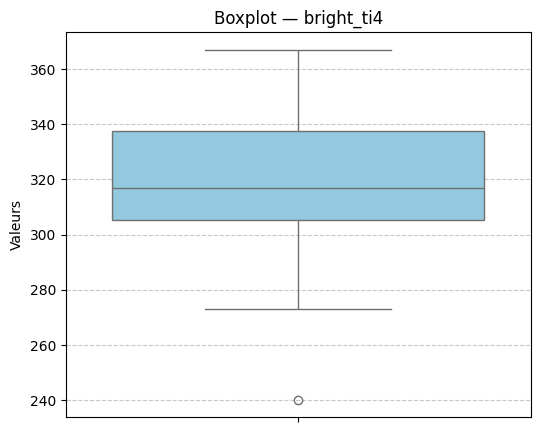

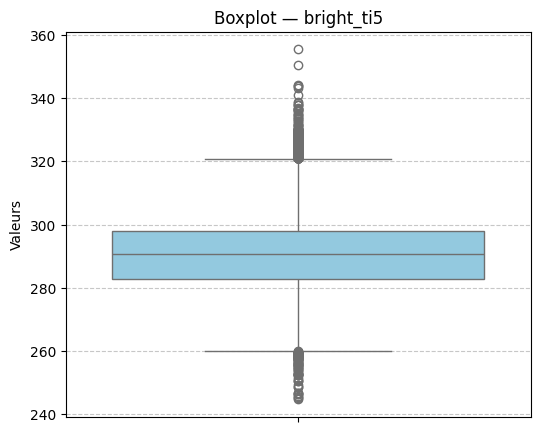

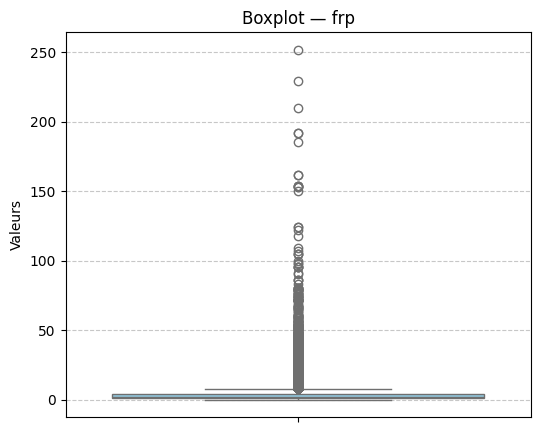

In [70]:
cols_to_plot = ['bright_ti4', 'bright_ti5', 'frp']

for col in cols_to_plot:
    plt.figure(figsize=(6,5))
    sns.boxplot(y=gdf_fire[col], color='skyblue')
    plt.title(f"Boxplot — {col}")
    plt.ylabel("Valeurs")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


#### __Histograms__

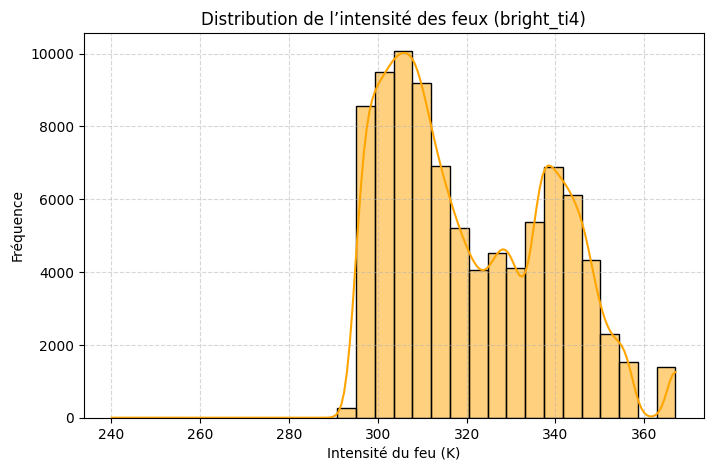

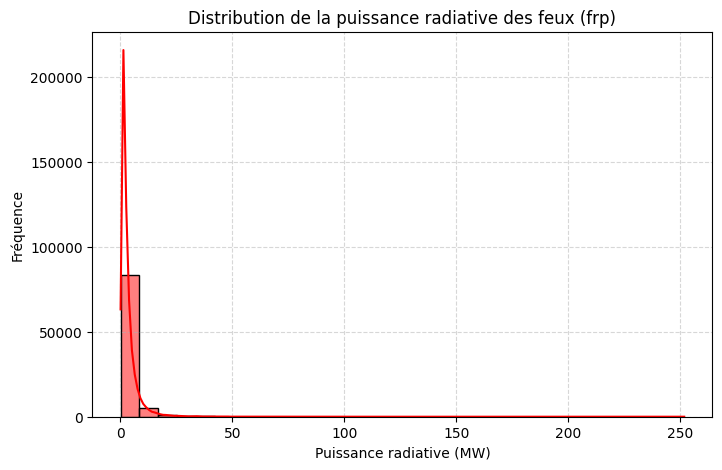

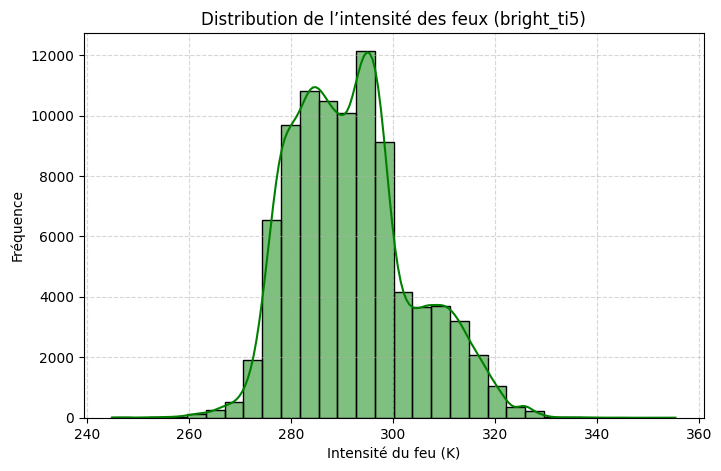

In [71]:
# Histogramme de l’intensité du feu (bright_ti4)
plt.figure(figsize=(8,5))
sns.histplot(gdf_fire["bright_ti4"], bins=30, kde=True, color="orange")
plt.title("Distribution de l’intensité des feux (bright_ti4)")
plt.xlabel("Intensité du feu (K)")
plt.ylabel("Fréquence")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Histogramme de la puissance radiative (frp)
plt.figure(figsize=(8,5))
sns.histplot(gdf_fire["frp"], bins=30, kde=True, color="red")
plt.title("Distribution de la puissance radiative des feux (frp)")
plt.xlabel("Puissance radiative (MW)")
plt.ylabel("Fréquence")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(gdf_fire["bright_ti5"], bins=30, kde=True, color="green")
plt.title("Distribution de l’intensité des feux (bright_ti5)")
plt.xlabel("Intensité du feu (K)")
plt.ylabel("Fréquence")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show() 

# __Bivariate analysis__

### Scatter Plot

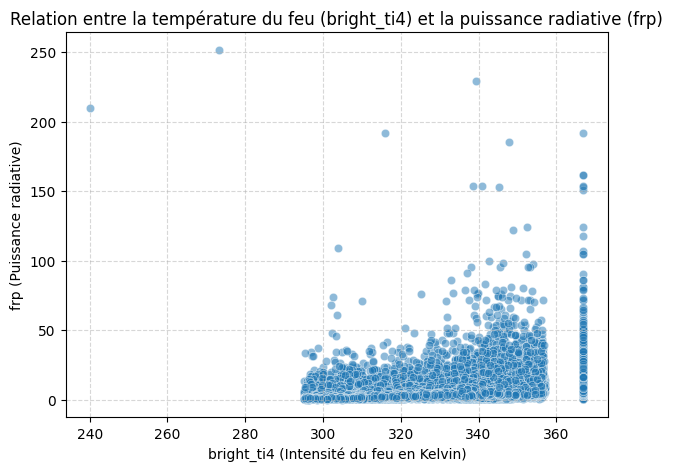

In [72]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=gdf_fire, x="bright_ti4", y="frp", alpha=0.5)
plt.title("Relation entre la température du feu (bright_ti4) et la puissance radiative (frp)")
plt.xlabel("bright_ti4 (Intensité du feu en Kelvin)")
plt.ylabel("frp (Puissance radiative)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

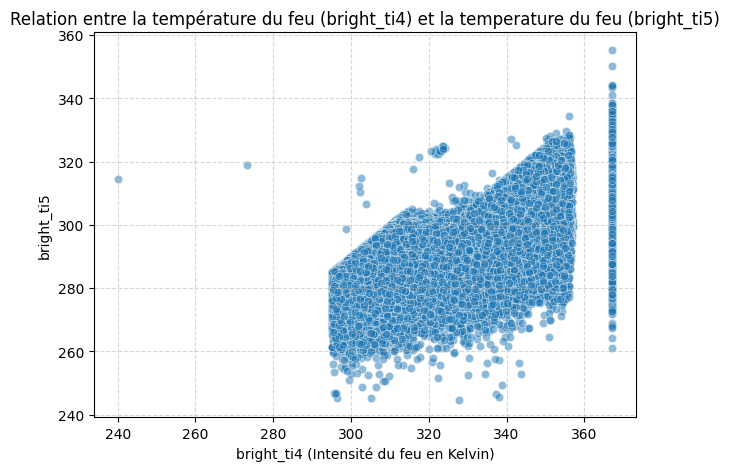

In [73]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=gdf_fire, x="bright_ti4", y="bright_ti5", alpha=0.5)
plt.title("Relation entre la température du feu (bright_ti4) et la temperature du feu (bright_ti5)")
plt.xlabel("bright_ti4 (Intensité du feu en Kelvin)")
plt.ylabel("bright_ti5")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

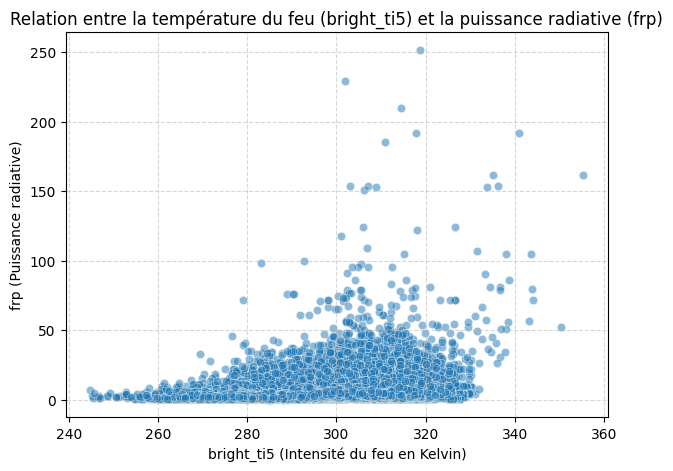

In [74]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=gdf_fire, x="bright_ti5", y="frp", alpha=0.5)
plt.title("Relation entre la température du feu (bright_ti5) et la puissance radiative (frp)")
plt.xlabel("bright_ti5 (Intensité du feu en Kelvin)")
plt.ylabel("frp (Puissance radiative)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Correlation


 MATRICE DE CORRÉLATION
            bright_ti4       frp  bright_ti5
bright_ti4    1.000000  0.444251    0.668842
frp           0.444251  1.000000    0.319401
bright_ti5    0.668842  0.319401    1.000000


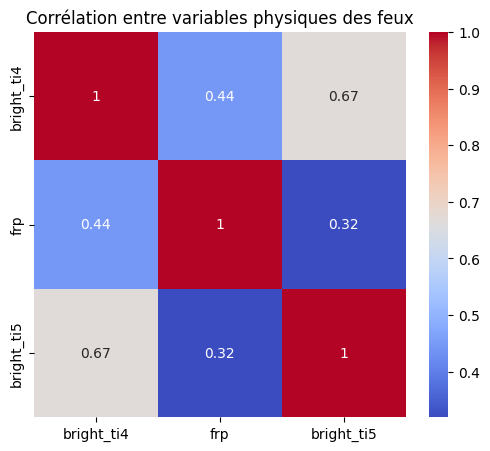

In [76]:
cols_physiques = [col for col in ["bright_ti4", "frp","bright_ti5"] if col in gdf_fire.columns]
# Conversion des variables physiques en numériques (si possible)
for col in cols_physiques:
    gdf_fire[col] = pd.to_numeric(gdf_fire[col], errors='coerce')

# CORRÉLATION ENTRE VARIABLES
# la relation statistique entre deux variables — la façon dont elles varient ensemble.
if len(cols_physiques) >= 2:
    corr = gdf_fire[cols_physiques].corr()
    print("\n MATRICE DE CORRÉLATION")
    print(corr)

    plt.figure(figsize=(6,5))
    sns.heatmap(gdf_fire[cols_physiques].corr(), annot=True, cmap="coolwarm")
    plt.title("Corrélation entre variables physiques des feux")
    plt.show()


## _Land Cover Dataset_

# __Univariate analysis__

### Measuring Central tendencies

In [ ]:
print("\n  APERÇU DES DONNÉES (Land Cover Algérie + Tunisie)")
print(merged_countries_landcover.head())

print("\n ℹ INFORMATIONS GÉNÉRALES SUR LE DATASET")
print(merged_countries_landcover.info())

print("\n  STATISTIQUES DESCRIPTIVES (colonnes numériques uniquement)")
print(merged_countries_landcover.describe())

print("\n  NOMBRE DE POLYGONES (zones) PAR TYPE DE COUVERTURE")
print(merged_countries_landcover["LCCOwnLabel"].value_counts())

print("\n  SYSTÈME DE COORDONNÉES (CRS)")
print(merged_countries_landcover.crs)

print("\n  TAILLE DU DATAFRAME (lignes, colonnes)")
print(merged_countries_landcover.shape)



  APERÇU DES DONNÉES (Land Cover Algérie + Tunisie)
   LCCMode                                LCCOwnLabel  \
0      0.0                               Water bodies   
1      0.0                               Water bodies   
2      0.0                               Water bodies   
3      0.0  Closed (>40%) broadleaved decidous forest   
4      0.0                               Water bodies   

                                            LCCLabel  GRIDCODE  ID  \
0  artificial waterbodies\r\n // natural waterbodies       210   4   
1  artificial waterbodies\r\n // natural waterbodies       210   2   
2  artificial waterbodies\r\n // natural waterbodies       210   1   
3  broadleaved deciduous closed to open (100-40)%...        50   8   
4  artificial waterbodies\r\n // natural waterbodies       210  13   

                                            geometry            LC  LPos  \
0  POLYGON ((6.41528 37.08696, 6.43103 37.0855, 6...  9mixed class   1.0   
1  POLYGON ((7.18084 37.07917, 

In [ ]:
# Sélectionner toutes les colonnes numériques (int, float, peu importe la précision)
cols_numeriques = merged_countries_landcover.select_dtypes(include=[np.number]).columns

print("\n--- MESURES STATISTIQUES DES VARIABLES NUMÉRIQUES ---")

# Moyenne
print("\nMOYENNE (Mean) :")
print(merged_countries_landcover[cols_numeriques].mean())

# Médiane
print("\nMÉDIANE (Median) :")
print(merged_countries_landcover[cols_numeriques].median())

# Mode
print("\nMODE (Mode) :")
mode_df = merged_countries_landcover[cols_numeriques].mode()
if not mode_df.empty:
    print(mode_df.iloc[0])
else:
    print("Aucun mode trouvé (toutes les valeurs sont uniques).")




--- MESURES STATISTIQUES DES VARIABLES NUMÉRIQUES ---

MOYENNE (Mean) :
LCCMode          0.000000
GRIDCODE       156.209934
ID          173378.294498
LPos             1.000000
MapCode        161.202242
dtype: float64

MÉDIANE (Median) :
LCCMode          0.0
GRIDCODE       200.0
ID          167198.0
LPos             1.0
MapCode        200.0
dtype: float64

MODE (Mode) :
LCCMode       0.0
GRIDCODE    200.0
ID            1.0
LPos          1.0
MapCode     200.0
Name: 0, dtype: float64


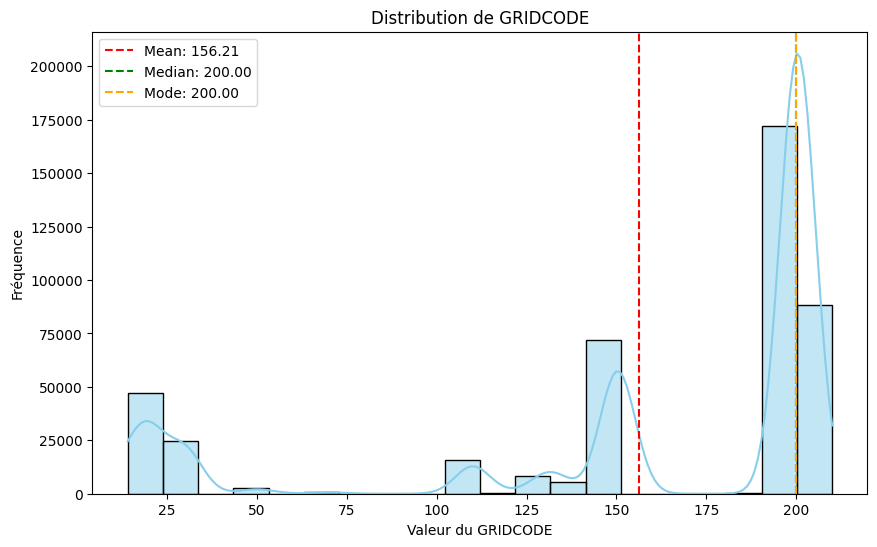

Généralement, la distribution des GRIDCODE est catégorique et peut être légèrement asymétrique selon les types de sol.


In [ ]:
# Exemple 1 : Distribution des valeurs GRIDCODE
col = "GRIDCODE"
mean_val = merged_countries_landcover[col].mean()
median_val = merged_countries_landcover[col].median()
mode_val = merged_countries_landcover[col].mode().iloc[0]

plt.figure(figsize=(10,6))
sns.histplot(merged_countries_landcover[col], bins=20, kde=True, color='skyblue')

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
plt.axvline(mode_val, color='orange', linestyle='--', label=f'Mode: {mode_val:.2f}')

plt.title(f"Distribution de {col}")
plt.xlabel("Valeur du GRIDCODE")
plt.ylabel("Fréquence")
plt.legend()
plt.show()
print("Généralement, la distribution des GRIDCODE est catégorique et peut être légèrement asymétrique selon les types de sol.")

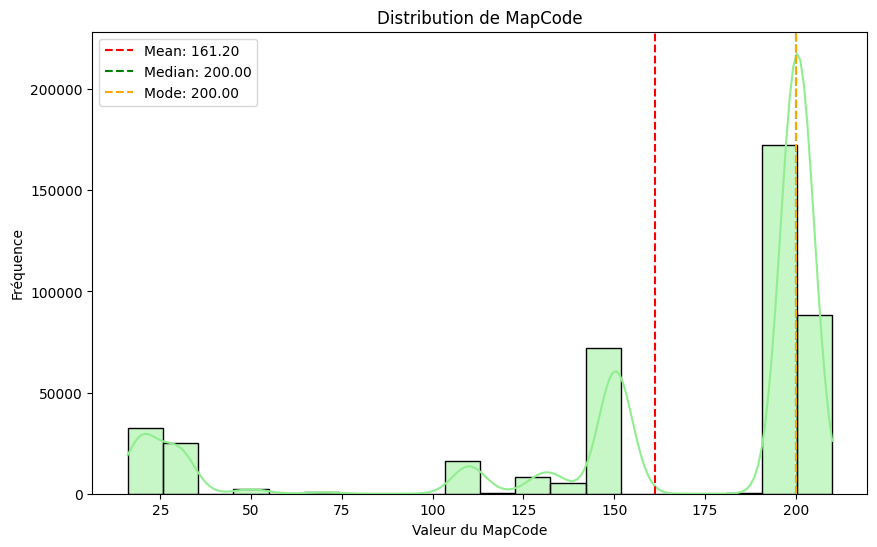

 Comme GRIDCODE, MapCode représente les classes de couverture du sol. La distribution est catégorique et reflète les types dominants (désert, zones agricoles, etc.).


In [ ]:
col = "MapCode"
mean_val = merged_countries_landcover[col].mean()
median_val = merged_countries_landcover[col].median()
mode_val = merged_countries_landcover[col].mode().iloc[0]

plt.figure(figsize=(10,6))
sns.histplot(merged_countries_landcover[col], bins=20, kde=True, color='lightgreen')

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
plt.axvline(mode_val, color='orange', linestyle='--', label=f'Mode: {mode_val:.2f}')

plt.title(f"Distribution de {col}")
plt.xlabel("Valeur du MapCode")
plt.ylabel("Fréquence")
plt.legend()
plt.show()
print(" Comme GRIDCODE, MapCode représente les classes de couverture du sol. La distribution est catégorique et reflète les types dominants (désert, zones agricoles, etc.).")


### Measuring Data Dispersion

In [ ]:
print("\n  ÉCART-TYPE (Standard Deviation)")
print(merged_countries_landcover[cols_numeriques].std())

print("\n  QUARTILES (Q1, Q2, Q3)")
print(merged_countries_landcover[cols_numeriques].quantile([0.25, 0.5, 0.75]))

print("\n ⬇ MINIMUM (Min)")
print(merged_countries_landcover[cols_numeriques].min())

print("\n ⬆ MAXIMUM (Max)")
print(merged_countries_landcover[cols_numeriques].max())

print("\n ↔ ÉTENDUE (Range)")
print(merged_countries_landcover[cols_numeriques].max() - merged_countries_landcover[cols_numeriques].min())


  ÉCART-TYPE (Standard Deviation)
LCCMode     0.000000
LPos        0.000000
MapCode    61.056576
dtype: float64

  QUARTILES (Q1, Q2, Q3)
      LCCMode  LPos  MapCode
0.25      0.0   1.0    150.0
0.50      0.0   1.0    200.0
0.75      0.0   1.0    200.0

 ⬇ MINIMUM (Min)
LCCMode     0.0
LPos        1.0
MapCode    16.0
dtype: float64

 ⬆ MAXIMUM (Max)
LCCMode      0.0
LPos         1.0
MapCode    210.0
dtype: float64

 ↔ ÉTENDUE (Range)
LCCMode      0.0
LPos         0.0
MapCode    194.0
dtype: float64


### Missing Values

In [ ]:
# Nombre de valeurs manquantes par colonne
missing_counts = merged_countries_landcover.isna().sum()

# Pourcentage de valeurs manquantes par colonne
missing_percent = (merged_countries_landcover.isna().sum() / len(merged_countries_landcover)) * 100

# Affichage résumé
missing_summary = pd.DataFrame({
    "Nombre de valeurs manquantes": missing_counts,
    "Pourcentage (%)": missing_percent
})

print("\n VALEURS MANQUANTES PAR COLONNE ")
print(missing_summary)



 VALEURS MANQUANTES PAR COLONNE 
             Nombre de valeurs manquantes  Pourcentage (%)
LCCMode                             14872         3.391462
LCCOwnLabel                         14872         3.391462
LCCLabel                            14872         3.391462
GRIDCODE                                0         0.000000
ID                                      0         0.000000
geometry                                0         0.000000
LC                                  14872         3.391462
LPos                                14872         3.391462
MapCode                             14872         3.391462
LCCLevel                            14872         3.391462


### Unique Values

In [ ]:
print("\n  NOMBRE DE VALEURS UNIQUES PAR COLONNE")
unique_counts = merged_countries_landcover.nunique()
print(unique_counts)


  NOMBRE DE VALEURS UNIQUES PAR COLONNE
LCCMode             1
LCCOwnLabel        21
LCCLabel           21
GRIDCODE           22
ID             386454
geometry       438513
LC                  6
LPos                1
MapCode            21
LCCLevel           21
dtype: int64


### Outliers Detection

In [ ]:
outlier_counts = {}
for col in cols_numeriques:
    data = merged_countries_landcover[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    outlier_counts[col] = len(outliers)

outlier_counts_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['nb_outliers'])
print("\n  NOMBRE D’OUTLIERS PAR VARIABLE NUMÉRIQUE")
print(outlier_counts_df)


  NOMBRE D’OUTLIERS PAR VARIABLE NUMÉRIQUE
         nb_outliers
LCCMode            0
LPos               0
MapCode        60698


# __Visual Analysis__

### Boxplots


  BOXPLOTS DES VARIABLES NUMÉRIQUES IMPORTANTES (GRIDCODE & MapCode)


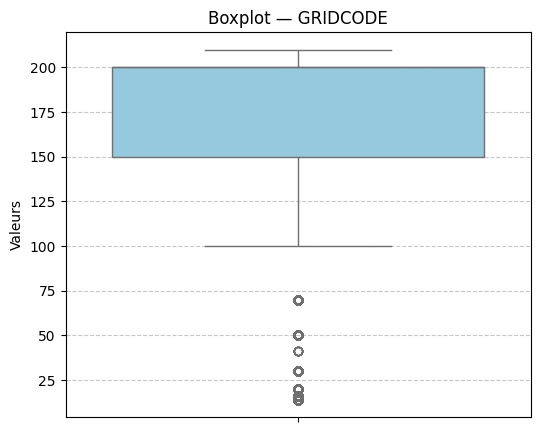

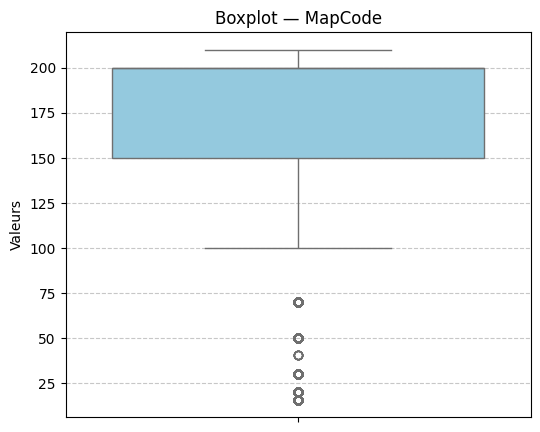

 Les boxplots de GRIDCODE et MapCode permettent d'observer la répartition et la présence éventuelle d'anomalies dans les codes de classification des types de couverture des sols.


In [ ]:
print("\n  BOXPLOTS DES VARIABLES NUMÉRIQUES IMPORTANTES (GRIDCODE & MapCode)")

cols_a_visualiser = ["GRIDCODE", "MapCode"]

for col in cols_a_visualiser:
    plt.figure(figsize=(6,5))
    sns.boxplot(y=merged_countries_landcover[col], color='skyblue')
    plt.title(f"Boxplot — {col}")
    plt.ylabel("Valeurs")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

print(" Les boxplots de GRIDCODE et MapCode permettent d'observer la répartition et la présence éventuelle d'anomalies dans les codes de classification des types de couverture des sols.")


### HISTOGRAMMES


  HISTOGRAMMES DES VARIABLES NUMÉRIQUES IMPORTANTES (GRIDCODE & MapCode)


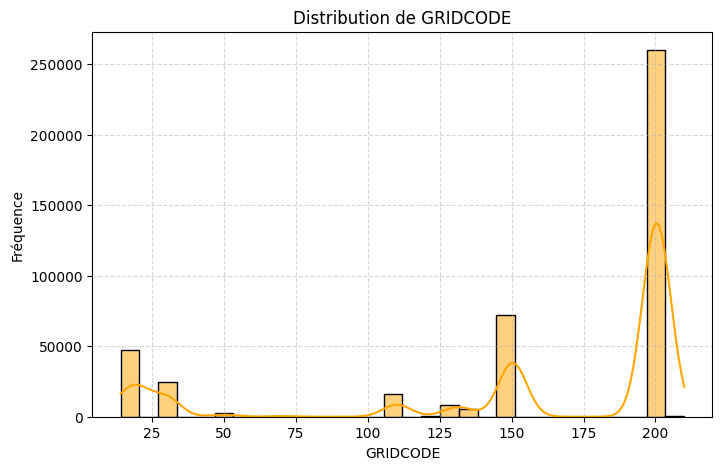

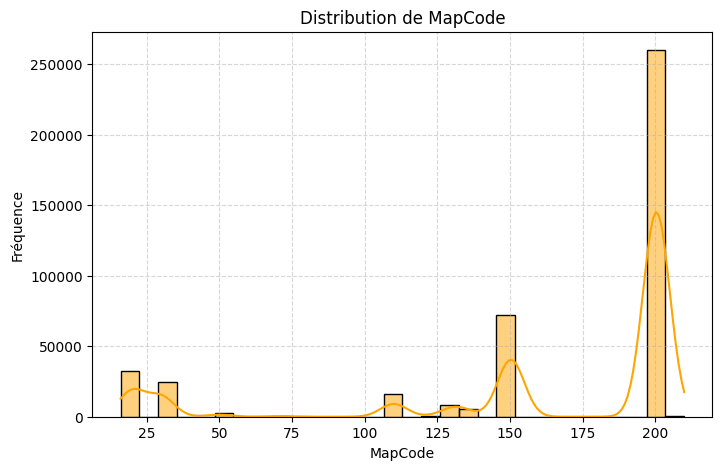

 Ces histogrammes permettent de visualiser la fréquence des différents codes de classification (GRIDCODE et MapCode) utilisés pour représenter les types de couverture des sols en Algérie et en Tunisie.


In [ ]:
print("\n  HISTOGRAMMES DES VARIABLES NUMÉRIQUES IMPORTANTES (GRIDCODE & MapCode)")

cols_a_visualiser = ["GRIDCODE", "MapCode"]

for col in cols_a_visualiser:
    plt.figure(figsize=(8,5))
    sns.histplot(merged_countries_landcover[col], bins=30, kde=True, color="orange")
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

print(" Ces histogrammes permettent de visualiser la fréquence des différents codes de classification (GRIDCODE et MapCode) utilisés pour représenter les types de couverture des sols en Algérie et en Tunisie.")


## Bivariante 

### SCATTER PLOTS


  SCATTER PLOTS ENTRE LES VARIABLES NUMÉRIQUES PRINCIPALES (GRIDCODE & MapCode)


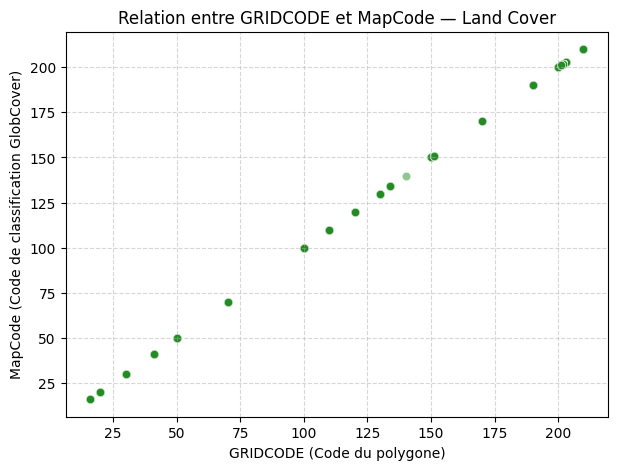

In [ ]:
print("\n  SCATTER PLOTS ENTRE LES VARIABLES NUMÉRIQUES PRINCIPALES (GRIDCODE & MapCode)")

plt.figure(figsize=(7,5))
sns.scatterplot(data=merged_countries_landcover, x="GRIDCODE", y="MapCode", alpha=0.5, color='forestgreen')
plt.title("Relation entre GRIDCODE et MapCode — Land Cover")
plt.xlabel("GRIDCODE (Code du polygone)")
plt.ylabel("MapCode (Code de classification GlobCover)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### MATRICE DE CORRÉLATION — Land Cover


  MATRICE DE CORRÉLATION — Land Cover (Algérie + Tunisie)
          GRIDCODE  MapCode
GRIDCODE       1.0      1.0
MapCode        1.0      1.0


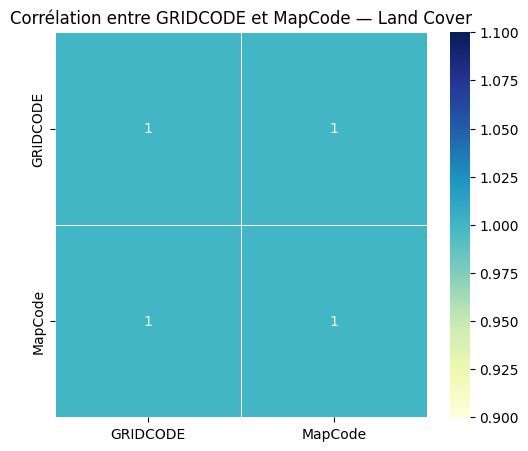

In [ ]:

cols_landcover = [col for col in ["GRIDCODE", "MapCode"] if col in merged_countries_landcover.columns]

# Conversion des variables en numériques (au cas où certaines valeurs seraient mal typées)
for col in cols_landcover:
    merged_countries_landcover[col] = pd.to_numeric(merged_countries_landcover[col], errors='coerce')

if len(cols_landcover) >= 2:
    corr_landcover = merged_countries_landcover[cols_landcover].corr()
    print("\n  MATRICE DE CORRÉLATION — Land Cover (Algérie + Tunisie)")
    print(corr_landcover)

    plt.figure(figsize=(6,5))
    sns.heatmap(corr_landcover, annot=True, cmap="YlGnBu", linewidths=0.5)
    plt.title("Corrélation entre GRIDCODE et MapCode — Land Cover")
    plt.show()


## _Climate Dataset_

## __Univariante Analysis__

### Measuring Central tendencies

In [ ]:

# Aperçu et statistiques
print("\nAperçu des données climatiques :")
print(df_climate.head())

print("\nInformations générales :")
print(df_climate.info())

print("\nStatistiques descriptives :")
print(df_climate.describe())




Aperçu des données climatiques :
   value                                 file climate_type
0    NaN  wc2.1_cruts4.09_5m_prec_2020-01.tif         prec
1    NaN  wc2.1_cruts4.09_5m_prec_2020-01.tif         prec
2    NaN  wc2.1_cruts4.09_5m_prec_2020-01.tif         prec
3    NaN  wc2.1_cruts4.09_5m_prec_2020-01.tif         prec
4    NaN  wc2.1_cruts4.09_5m_prec_2020-01.tif         prec

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10039680 entries, 0 to 10039679
Data columns (total 3 columns):
 #   Column        Dtype  
---  ------        -----  
 0   value         float32
 1   file          object 
 2   climate_type  object 
dtypes: float32(1), object(2)
memory usage: 191.5+ MB
None

Statistiques descriptives :
              value
count  5.902380e+06
mean   1.773409e+01
std    1.472533e+01
min   -4.000000e+00
25%    3.500000e+00
50%    1.717500e+01
75%    2.750000e+01
max    3.686750e+02


### Measuring Data Dispersion

In [ ]:
import pandas as pd

# Liste des variables climatiques
variables = ["prec", "tmax", "tmin"]

# Fonction pour calculer et afficher les statistiques
def afficher_stats(df, variable):
    print(f"\nStatistiques pour {variable} :")
    df_var = df[df['variable'] == variable]['moyenne'].dropna()  # supprimer les NaN
    
    print("Moyenne :", df_var.mean())
    print("Médiane :", df_var.median())
    
    mode_val = df_var.mode()
    if not mode_val.empty:
        print("Mode :", mode_val.iloc[0])
    else:
        print("Mode : Aucun mode trouvé")
    
    print("Écart-type :", df_var.std())
    print("Quartiles :")
    print(df_var.quantile([0.25, 0.5, 0.75]))
    print("Minimum :", df_var.min())
    print("Maximum :", df_var.max())
    print("Étendue :", df_var.max() - df_var.min())

# Appliquer la fonction à chaque variable
for var in variables:
    afficher_stats(df_wilaya_climate, var)



Statistiques pour prec :
Moyenne : 24.761042307522164
Médiane : 13.309373462302755
Mode : 0.0009633027085470497
Écart-type : 31.529070220657655
Quartiles :
0.25     3.834375
0.50    13.309373
0.75    33.965335
Name: moyenne, dtype: float64
Minimum : 0.0008256881062043916
Maximum : 310.02065641983694
Étendue : 310.01983073173074

Statistiques pour tmax :
Moyenne : 25.459356237741137
Médiane : 24.86784778131436
Mode : 17.0
Écart-type : 8.177650692507877
Quartiles :
0.25    18.455038
0.50    24.867848
0.75    32.394280
Name: moyenne, dtype: float64
Minimum : 8.73421052631579
Maximum : 46.17277856135402
Étendue : 37.43856803503823

Statistiques pour tmin :
Moyenne : 13.588060466057067
Médiane : 12.926350048216008
Mode : 8.75
Écart-type : 6.775780642412231
Quartiles :
0.25     7.897226
0.50    12.926350
0.75    19.433148
Name: moyenne, dtype: float64
Minimum : -0.9162650602409639
Maximum : 30.810648801128348
Étendue : 31.72691386136931


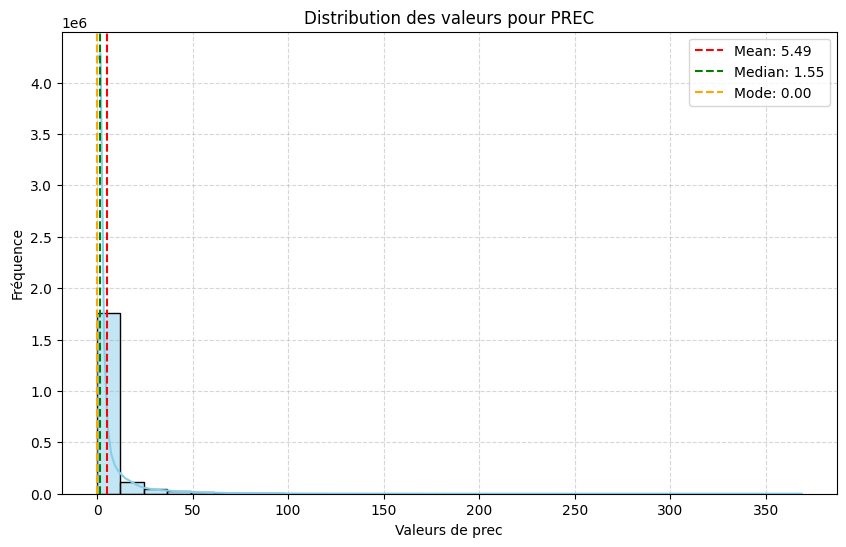

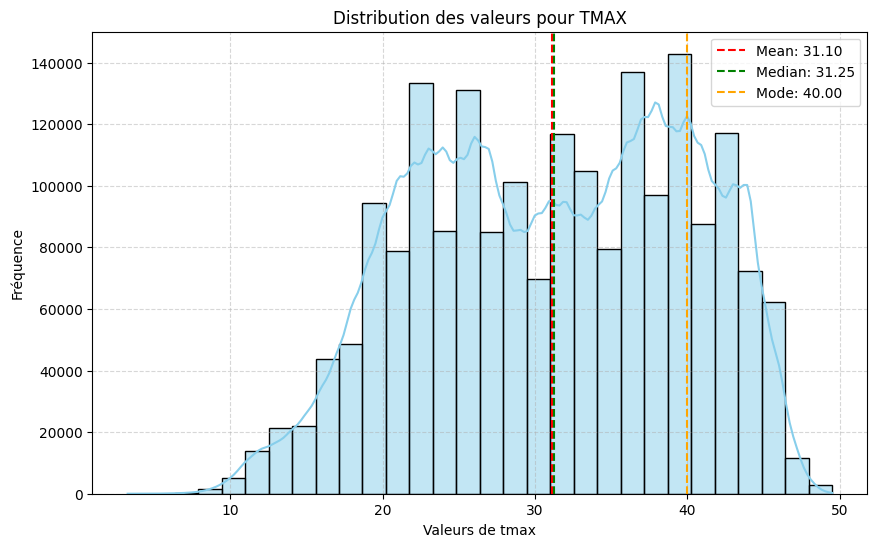

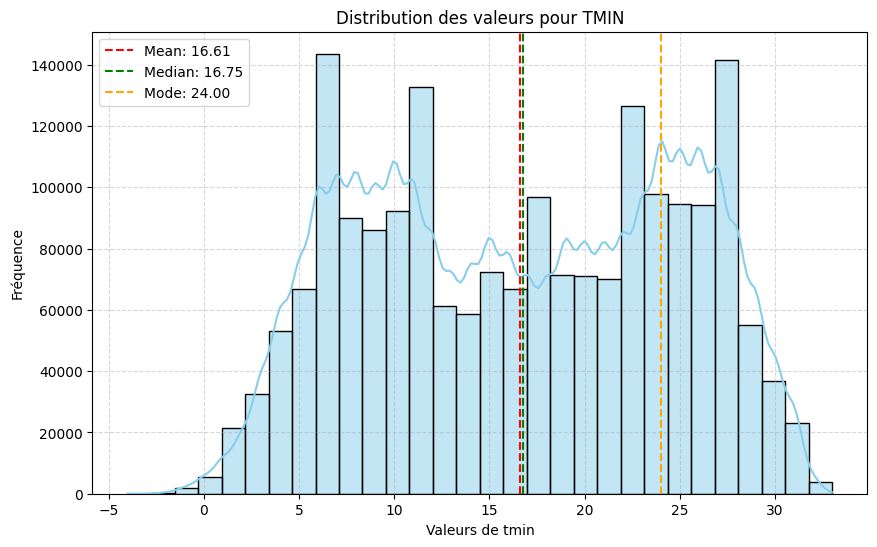

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Liste des types de climat
climate_types = ['prec', 'tmax', 'tmin']

for ctype in climate_types:
    vals = df_climate.loc[df_climate['climate_type'] == ctype, 'value'].dropna()
    
    mean_val = vals.mean()
    median_val = vals.median()
    mode_val = vals.mode().iloc[0] if not vals.mode().empty else None
    
    plt.figure(figsize=(10,6))
    sns.histplot(vals, bins=30, kde=True, color='skyblue')
    
    # Ajouter lignes pour moyenne, médiane et mode
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
    if mode_val is not None:
        plt.axvline(mode_val, color='orange', linestyle='--', label=f'Mode: {mode_val:.2f}')
    
    plt.title(f"Distribution des valeurs pour {ctype.upper()}")
    plt.xlabel(f"Valeurs de {ctype}")
    plt.ylabel("Fréquence")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()



### Missing values 

In [ ]:
# Valeurs manquantes dans le GeoDataFrame Land Cover
print("\nValeurs manquantes par colonne dans merged_countries_landcover :")
print(merged_countries_landcover.isnull().sum())





Valeurs manquantes par colonne dans merged_countries_landcover :
LCCMode        14872
LCCOwnLabel    14872
LCCLabel       14872
GRIDCODE           0
ID                 0
geometry           0
LC             14872
LPos           14872
MapCode        14872
LCCLevel       14872
dtype: int64


### Valeurs Uniques

In [ ]:
def afficher_valeurs_uniques(df):
    """
    Affiche le nombre de valeurs uniques dans la colonne 'moyenne' pour chaque variable,
    et montre un aperçu des premières valeurs arrondies à 2 décimales.
    """
    variables = df['variable'].unique()
    
    for var in variables:
        sub = df[df['variable'] == var]['moyenne']
        n_unique = sub.nunique()
        # Convertir en float normal avant arrondi
        exemples = [round(float(x), 2) for x in sorted(sub.unique())[:10]] 
        print(f"\n Variable : {var.upper()} ")
        print(f"Nombre de valeurs uniques : {n_unique}")
        print(f"Exemples de valeurs uniques : {exemples}")

# Afficher les valeurs uniques
afficher_valeurs_uniques(df_wilaya_climate)



 Variable : PREC 
Nombre de valeurs uniques : 4313
Exemples de valeurs uniques : [0.0, 0.0, 0.0, 0.0, 0.01, 0.01, 0.01, 0.01, 0.03, 0.04]

 Variable : TMAX 
Nombre de valeurs uniques : 4185
Exemples de valeurs uniques : [8.73, 8.88, 9.3, 9.35, 9.36, 9.46, 9.76, 9.81, 10.07, 10.08]

 Variable : TMIN 
Nombre de valeurs uniques : 4159
Exemples de valeurs uniques : [-0.92, -0.15, 0.06, 0.09, 0.1, 0.11, 0.15, 0.23, 0.44, 0.55]


### Detection des outliers 

In [ ]:
def detect_outliers_iqr(df, variable_name):
    """
    Detects outliers in the 'moyenne' column for a specific variable using IQR.
    """
    sub = df[df['variable'] == variable_name]['moyenne']
    Q1 = sub.quantile(0.25)
    Q3 = sub.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = sub[(sub < lower_bound) | (sub > upper_bound)]
    
    print(f"\n Variable : {variable_name.upper()} ")
    print(f"Nombre d'outliers : {len(outliers)}")
    if len(outliers) > 0:
        print("Valeurs des outliers :")
        print(outliers.sort_values())
    else:
        print("Aucun outlier détecté.")
    
    return outliers

# Détecter et afficher les outliers pour chaque variable
outliers_prec = detect_outliers_iqr(df_wilaya_climate, "prec")
outliers_tmax = detect_outliers_iqr(df_wilaya_climate, "tmax")
outliers_tmin = detect_outliers_iqr(df_wilaya_climate, "tmin")



 Variable : PREC 
Nombre d'outliers : 262
Valeurs des outliers :
155      79.342540
902      79.452461
1102     79.475925
764      79.826850
1059     79.891323
           ...    
1587    278.157633
1628    290.872233
1596    291.657895
1630    294.203488
1593    310.020656
Name: moyenne, Length: 262, dtype: float64

 Variable : TMAX 
Nombre d'outliers : 0
Aucun outlier détecté.

 Variable : TMIN 
Nombre d'outliers : 0
Aucun outlier détecté.


### __Visual Analysis__

### Boxplots


  BOXPLOTS DES VARIABLES CLIMATIQUES (prec, tmax, tmin)


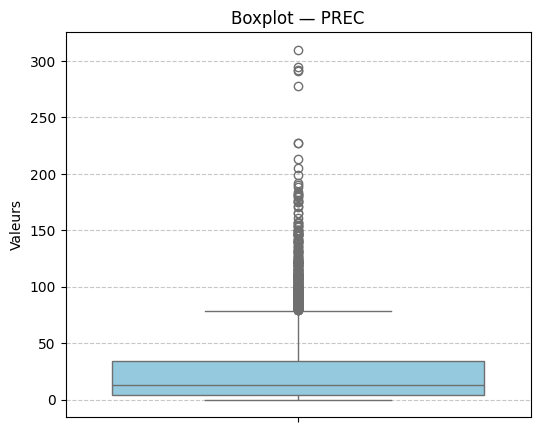

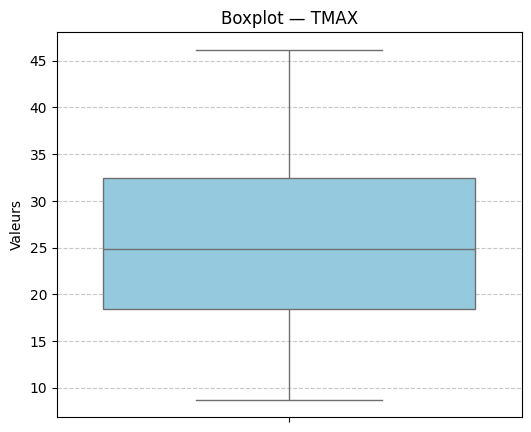

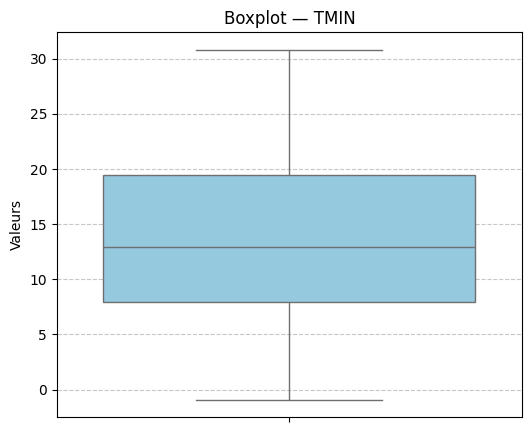

Les boxplots permettent d'observer la répartition et la présence éventuelle d'anomalies pour les variables climatiques (précipitations, TMAX, TMIN).


In [ ]:
variables_clim = ["prec", "tmax", "tmin"]
print("\n  BOXPLOTS DES VARIABLES CLIMATIQUES (prec, tmax, tmin)")

for var in variables_clim:
    plt.figure(figsize=(6,5))
    sns.boxplot(y=df_wilaya_climate[df_wilaya_climate['variable'] == var]['moyenne'], color='skyblue')
    plt.title(f"Boxplot — {var.upper()}")
    plt.ylabel("Valeurs")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

print("Les boxplots permettent d'observer la répartition et la présence éventuelle d'anomalies pour les variables climatiques (précipitations, TMAX, TMIN).")

### HISTOGRAMMES


  HISTOGRAMMES DES VARIABLES CLIMATIQUES (prec, tmax, tmin)


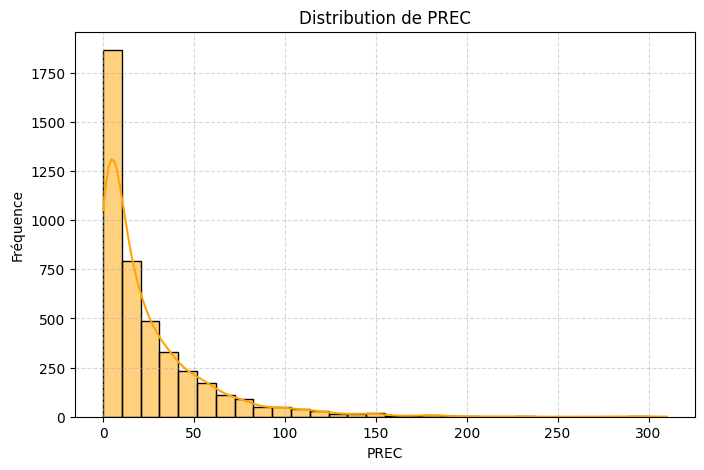

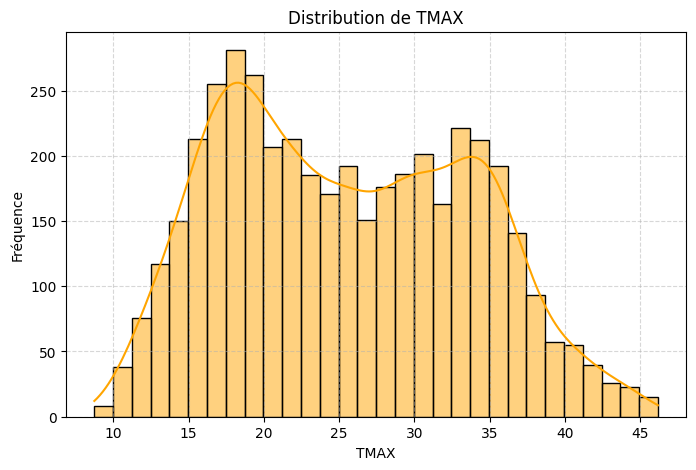

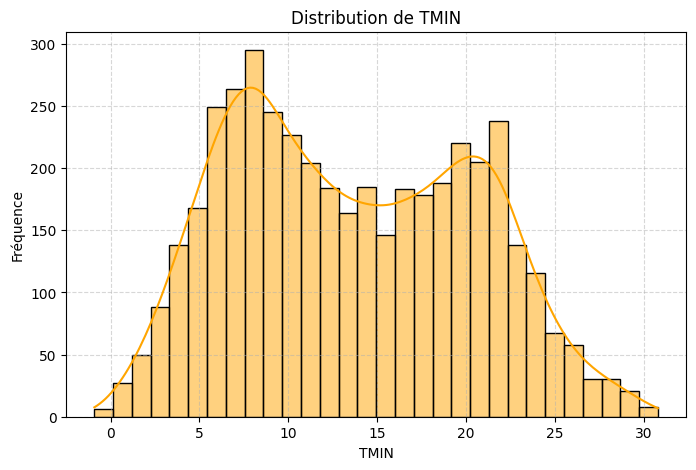

Ces histogrammes permettent de visualiser la fréquence des valeurs pour les variables climatiques par wilaya.


In [ ]:
print("\n  HISTOGRAMMES DES VARIABLES CLIMATIQUES (prec, tmax, tmin)")

for var in variables_clim:
    plt.figure(figsize=(8,5))
    sns.histplot(df_wilaya_climate[df_wilaya_climate['variable'] == var]['moyenne'],
                 bins=30, kde=True, color="orange")
    plt.title(f"Distribution de {var.upper()}")
    plt.xlabel(var.upper())
    plt.ylabel("Fréquence")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

print("Ces histogrammes permettent de visualiser la fréquence des valeurs pour les variables climatiques par wilaya.")

## __Bivariante Analysis__

### Scatter Plot 


  SCATTER PLOTS ENTRE LES VARIABLES CLIMATIQUES (prec, tmax, tmin)


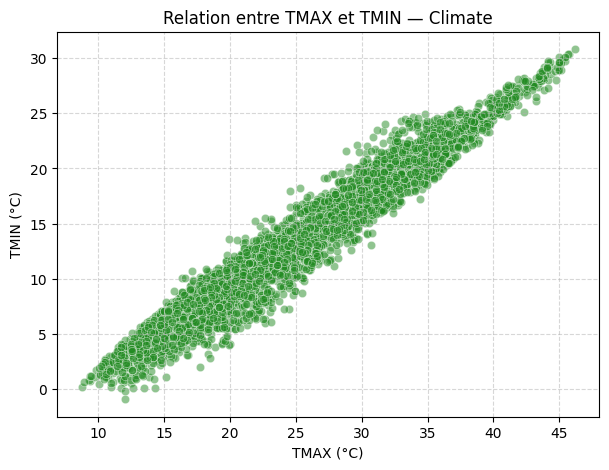

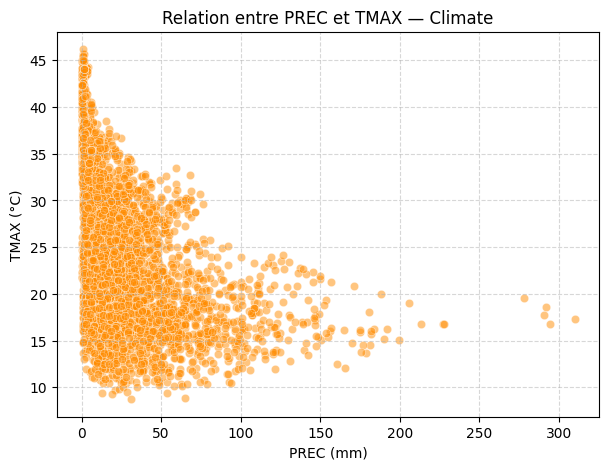

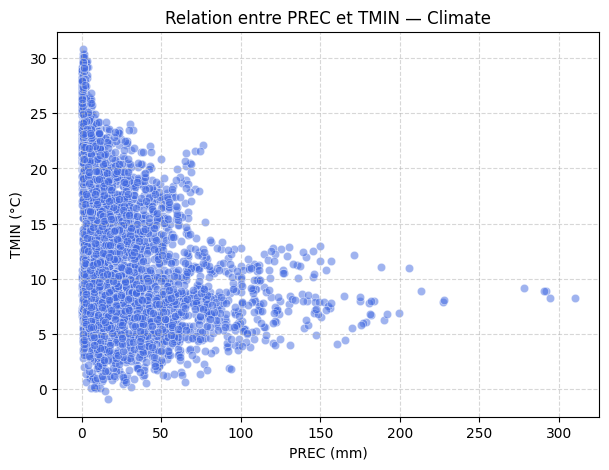

In [ ]:
print("\n  SCATTER PLOTS ENTRE LES VARIABLES CLIMATIQUES (prec, tmax, tmin)")

# Préparer un DataFrame pivoté pour avoir une colonne par variable
df_climate_pivot = df_wilaya_climate.pivot_table(
    index=['wilaya', 'annee', 'mois'],
    columns='variable',
    values='moyenne'
).reset_index()

plt.figure(figsize=(7,5))
sns.scatterplot(data=df_climate_pivot, x="tmax", y="tmin", alpha=0.5, color='forestgreen')
plt.title("Relation entre TMAX et TMIN — Climate")
plt.xlabel("TMAX (°C)")
plt.ylabel("TMIN (°C)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(data=df_climate_pivot, x="prec", y="tmax", alpha=0.5, color='darkorange')
plt.title("Relation entre PREC et TMAX — Climate")
plt.xlabel("PREC (mm)")
plt.ylabel("TMAX (°C)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(data=df_climate_pivot, x="prec", y="tmin", alpha=0.5, color='royalblue')
plt.title("Relation entre PREC et TMIN — Climate")
plt.xlabel("PREC (mm)")
plt.ylabel("TMIN (°C)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### MATRICE DE CORRÉLATION — Climate


  MATRICE DE CORRÉLATION — Climate (Algérie + Tunisie)
variable      prec      tmax      tmin
variable                              
prec      1.000000 -0.481069 -0.399479
tmax     -0.481069  1.000000  0.974749
tmin     -0.399479  0.974749  1.000000


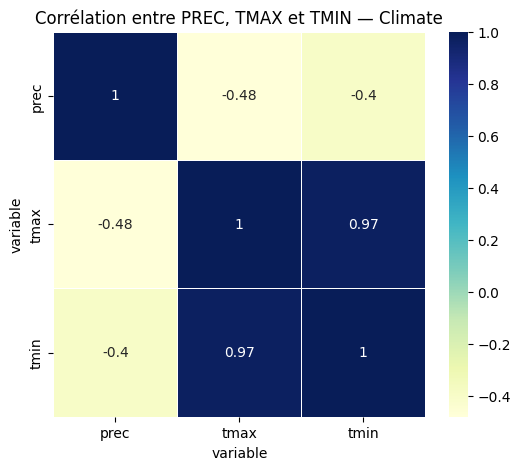

In [ ]:
cols_climate = ["prec", "tmax", "tmin"]

# Conversion en numérique au cas où
for col in cols_climate:
    df_climate_pivot[col] = pd.to_numeric(df_climate_pivot[col], errors='coerce')

if len(cols_climate) >= 2:
    corr_climate = df_climate_pivot[cols_climate].corr()
    print("\n  MATRICE DE CORRÉLATION — Climate (Algérie + Tunisie)")
    print(corr_climate)

    plt.figure(figsize=(6,5))
    sns.heatmap(corr_climate, annot=True, cmap="YlGnBu", linewidths=0.5)
    plt.title("Corrélation entre PREC, TMAX et TMIN — Climate")
    plt.show()

## _Elevation Dataset_

In [ ]:

# Charger le raster d'élévation (celui que tu as clipé)
elevation_file = "Datasets/Elevation/clip_north_africa/elevation_north_africa.tif"

# Ouvrir le raster
with rasterio.open(elevation_file) as src:
    elevation_data = src.read(1)  # première bande
    elevation_data = np.where(elevation_data < 0, np.nan, elevation_data)  # masque les valeurs négatives
    profile = src.profile

# Convertir le raster en DataFrame
# On garde uniquement les valeurs valides
elevation_values = elevation_data[~np.isnan(elevation_data)]
df_elevation = pd.DataFrame({'elevation': elevation_values})

print(" DataFrame créé avec succès !")
print(df_elevation.head())
print(f"\nNombre total de pixels valides : {len(df_elevation)}")


 DataFrame créé avec succès !
   elevation
0        0.0
1        0.0
2        1.0
3        0.0
4        0.0

Nombre total de pixels valides : 13073078


### __Univariant Analysis__

### Measuring Central tendencies

In [ ]:


print("\n=== APERÇU DU DATASET D'ÉLÉVATION ===")
print(df_elevation.head())

print("\n=== INFORMATIONS GÉNÉRALES ===")
print(df_elevation.info())

print("\n=== STATISTIQUES DESCRIPTIVES ===")
print(df_elevation.describe())


=== APERÇU DU DATASET D'ÉLÉVATION ===
   elevation
0        0.0
1        0.0
2        1.0
3        0.0
4        0.0

=== INFORMATIONS GÉNÉRALES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13073078 entries, 0 to 13073077
Data columns (total 1 columns):
 #   Column     Dtype  
---  ------     -----  
 0   elevation  float64
dtypes: float64(1)
memory usage: 99.7 MB
None

=== STATISTIQUES DESCRIPTIVES ===
          elevation
count  1.307308e+07
mean   5.404164e+02
std    3.233159e+02
min    0.000000e+00
25%    3.140000e+02
50%    4.650000e+02
75%    6.990000e+02
max    2.877000e+03


### MESURES DE DISPERSION

In [ ]:
print("\n=== MESURES DE DISPERSION ===")
if "elevation" in df_elevation.columns:
    vals = df_elevation["elevation"].dropna()
    print("Moyenne :", vals.mean())
    print("Médiane :", vals.median())
    mode_val = vals.mode()
    if not mode_val.empty:
        print("Mode :", mode_val.iloc[0])
    else:
        print("Mode : Aucun mode trouvé")
    print("Écart-type :", vals.std())
    print("Minimum :", vals.min())
    print("Maximum :", vals.max())
    print("Étendue :", vals.max() - vals.min())
    print("Quartiles :")
    print(vals.quantile([0.25, 0.5, 0.75]))


=== MESURES DE DISPERSION ===
Moyenne : 540.4164096626671
Médiane : 465.0
Mode : 301.0
Écart-type : 323.3158822519701
Minimum : 0.0
Maximum : 2877.0
Étendue : 2877.0
Quartiles :
0.25    314.0
0.50    465.0
0.75    699.0
Name: elevation, dtype: float64


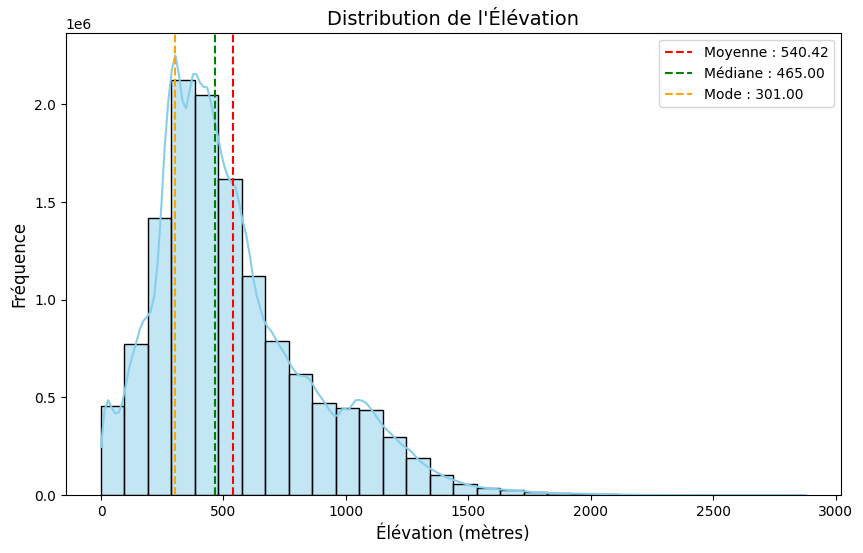

Moyenne : 540.42
Médiane : 465.00
Mode : 301.00


In [ ]:

# Variable à analyser
col = "elevation"

# Calcul des mesures statistiques
mean_val = df_elevation[col].mean()
median_val = df_elevation[col].median()
mode_val = df_elevation[col].mode().iloc[0]

# Tracé de la distribution
plt.figure(figsize=(10,6))
sns.histplot(df_elevation[col], bins=30, kde=True, color='skyblue')

# Lignes pour moyenne, médiane et mode
plt.axvline(mean_val, color='red', linestyle='--', label=f'Moyenne : {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Médiane : {median_val:.2f}')
plt.axvline(mode_val, color='orange', linestyle='--', label=f'Mode : {mode_val:.2f}')

# Titres et labels
plt.title("Distribution de l'Élévation", fontsize=14)
plt.xlabel("Élévation (mètres)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)
plt.legend()
plt.show()

print(f"Moyenne : {mean_val:.2f}")
print(f"Médiane : {median_val:.2f}")
print(f"Mode : {mode_val:.2f}")



### Missing values

In [ ]:
print("\n=== VALEURS MANQUANTES ===")
missing_counts = df_elevation.isna().sum()
missing_percent = (missing_counts / len(df_elevation)) * 100
missing_summary = pd.DataFrame({
    "Nombre de valeurs manquantes": missing_counts,
    "Pourcentage (%)": missing_percent
})
print(missing_summary)


=== VALEURS MANQUANTES ===
           Nombre de valeurs manquantes  Pourcentage (%)
elevation                             0              0.0


### Unique values

In [ ]:

print("Nombre de valeurs uniques :", df_elevation["elevation"].nunique())
print("Valeur minimale :", df_elevation["elevation"].min())
print("Valeur maximale :", df_elevation["elevation"].max())
print("Quelques valeurs uniques :", df_elevation["elevation"].unique()[:10])



Nombre de valeurs uniques : 2592
Valeur minimale : 0.0
Valeur maximale : 2877.0
Quelques valeurs uniques : [  0.   1.  12. 127.  58.  37.  36. 149. 145. 166.]


### Outliers

In [ ]:
# === DÉTECTION DES OUTLIERS PAR IQR ===
def detect_outliers_iqr(df, col):
    """
    Détecte les outliers d'une colonne numérique selon la méthode IQR.
    """
    vals = df[col].dropna()
    Q1 = vals.quantile(0.25)
    Q3 = vals.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = vals[(vals < lower_bound) | (vals > upper_bound)]
    print(f"\nVariable : {col}")
    print(f"Nombre d'outliers : {len(outliers)}")
    if not outliers.empty:
        print(f"Exemples d'outliers : {outliers.sort_values().head(10).values}")
    else:
        print("Aucun outlier détecté.")
    return outliers

# Application sur la colonne 'elevation'
if "elevation" in df_elevation.columns:
    outliers_elev = detect_outliers_iqr(df_elevation, "elevation")


Variable : elevation
Nombre d'outliers : 384298
Exemples d'outliers : [1277. 1277. 1277. 1277. 1277. 1277. 1277. 1277. 1277. 1277.]


## Boxplot

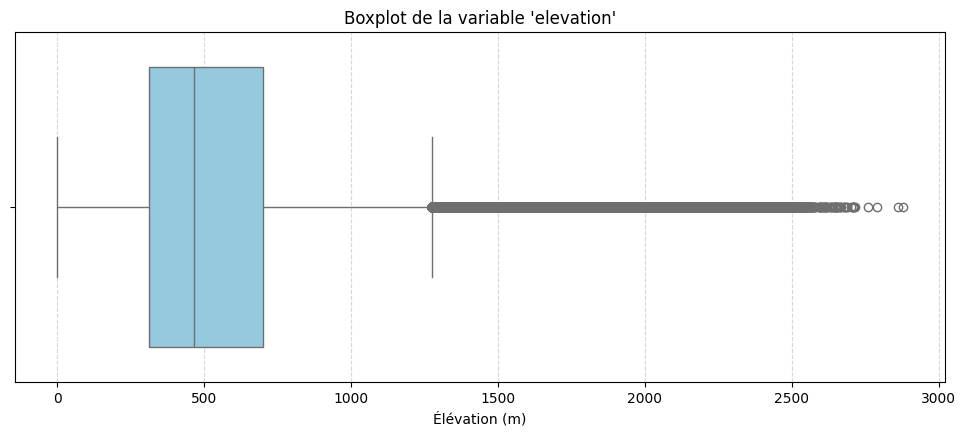

In [ ]:
# === VISUALISATION DES OUTLIERS : Boxplot & Histogramme ===
col = "elevation"

plt.figure(figsize=(12, 10))

# --- Boxplot ---
plt.subplot(2, 1, 1)
sns.boxplot(data=df_elevation, x=col, color="skyblue")
plt.title(f"Boxplot de la variable '{col}'")
plt.xlabel("Élévation (m)")
plt.grid(axis='x', linestyle='--', alpha=0.5)

### Histogramme

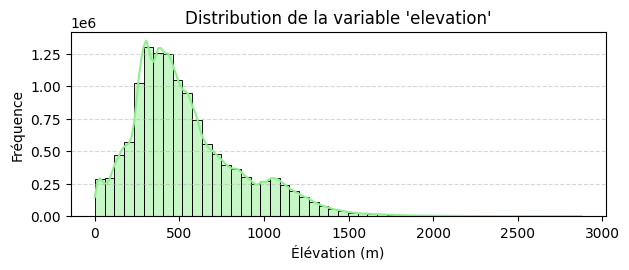

In [ ]:
plt.subplot(2, 1, 2)
sns.histplot(df_elevation[col], bins=50, kde=True, color="lightgreen")
plt.title(f"Distribution de la variable '{col}'")
plt.xlabel("Élévation (m)")
plt.ylabel("Fréquence")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## _Soil Datasets_

## __Univariante__

### Measuring Central tendencies

In [ ]:
print("\n Aperçu des données du sol (D1 - 0-20 cm) :")
print(df_soil.head())

print("\n Informations générales sur les données :")
print(df_soil.info())

print("\n Statistiques descriptives :")
print(df_soil.describe())


 Aperçu des données du sol (D1 - 0-20 cm) :
     COARSE  SAND  SILT  CLAY  TEXTURE_USDA TEXTURE_SOTER  BULK  REF_BULK  \
666       5    67    18    15          11.0             C  1.35      1.63   
667       5    67    18    15          11.0             C  1.35      1.63   
668       5    67    18    15          11.0             C  1.35      1.63   
669       5    67    18    15          11.0             C  1.35      1.63   
694       2    24    52    24           7.0             M  1.44      1.76   

     ORG_CARBON  PH_WATER  ...  CEC_SOIL  CEC_CLAY  CEC_EFF  TEB  BSAT  \
666       1.062       6.3  ...         8        46      6.0  5.0    59   
667       1.062       6.3  ...         8        46      6.0  5.0    59   
668       1.062       6.3  ...         8        46      6.0  5.0    59   
669       1.062       6.3  ...         8        46      6.0  5.0    59   
694       1.475       5.2  ...         9        20      6.0  4.0    41   

     ALUM_SAT  ESP  TCARBON_EQ  GYPSUM  ELEC_CO

### Measuring Data Dispersion

In [ ]:
### Measuring Data Dispersion  
# Définir les colonnes numériques
cols_numeriques = df_soil.select_dtypes(include=[np.number]).columns.tolist()

# MESURES STATISTIQUES
print("\nMOYENNE (Mean)")
print(df_soil[cols_numeriques].mean())

print("\nMÉDIANE (Median)")
print(df_soil[cols_numeriques].median())

print("\nMODE (Mode)")
mode_df = df_soil[cols_numeriques].mode()
if not mode_df.empty:
    print(mode_df.iloc[0])
else:
    print("Aucun mode trouvé (toutes les valeurs sont uniques).")



MOYENNE (Mean)
COARSE          11.184573
SAND            46.051879
SILT            30.209023
CLAY            21.282664
TEXTURE_USDA     8.602581
BULK             1.226432
REF_BULK         1.707009
ORG_CARBON       2.706419
PH_WATER         6.396850
TOTAL_N          1.720019
CN_RATIO        11.511412
CEC_SOIL        17.711720
CEC_CLAY        48.530708
CEC_EFF         21.153514
TEB             19.685352
BSAT            74.592090
ALUM_SAT         5.352230
ESP              3.379779
TCARBON_EQ       3.985683
GYPSUM           0.913780
ELEC_COND        0.980396
dtype: float64

MÉDIANE (Median)
COARSE          10.000
SAND            43.000
SILT            31.000
CLAY            20.000
TEXTURE_USDA     9.000
BULK             1.370
REF_BULK         1.710
ORG_CARBON       1.316
PH_WATER         6.600
TOTAL_N          1.140
CN_RATIO        11.000
CEC_SOIL        16.000
CEC_CLAY        48.000
CEC_EFF         20.000
TEB             16.000
BSAT            82.000
ALUM_SAT         0.000
ESP           

In [ ]:
print("\n ÉCART-TYPE (Standard Deviation)")
print(df_soil[cols_numeriques].std())

print("\n QUARTILES (Q1, Q2, Q3)")
print(df_soil[cols_numeriques].quantile([0.25, 0.5, 0.75]))

print("\n MINIMUM (Min)")
print(df_soil[cols_numeriques].min())

print("\n MAXIMUM (Max)")
print(df_soil[cols_numeriques].max())

print("\n ÉTENDUE (Range)")
print(df_soil[cols_numeriques].max() - df_soil[cols_numeriques].min())


 ÉCART-TYPE (Standard Deviation)
COARSE           8.437106
SAND            17.348953
SILT            11.973649
CLAY            10.549217
TEXTURE_USDA     2.500621
BULK             0.863178
REF_BULK         0.161498
ORG_CARBON       6.243177
PH_WATER         1.924548
TOTAL_N          2.559947
CN_RATIO         3.993419
CEC_SOIL        14.348210
CEC_CLAY        20.671863
CEC_EFF         14.940306
TEB             15.732238
BSAT            25.863499
ALUM_SAT        11.164197
ESP              7.312943
TCARBON_EQ       6.676669
GYPSUM           3.176970
ELEC_COND        2.110009
dtype: float64

 QUARTILES (Q1, Q2, Q3)
      COARSE  SAND  SILT  CLAY  TEXTURE_USDA  BULK  REF_BULK  ORG_CARBON  \
0.25     4.0  36.0  23.0  16.0           7.0  1.29      1.65       0.711   
0.50    10.0  43.0  31.0  20.0           9.0  1.37      1.71       1.316   
0.75    18.0  55.0  38.0  27.0          11.0  1.46      1.81       2.200   

      PH_WATER  TOTAL_N  ...  CEC_SOIL  CEC_CLAY  CEC_EFF   TEB  BSAT  \
0.

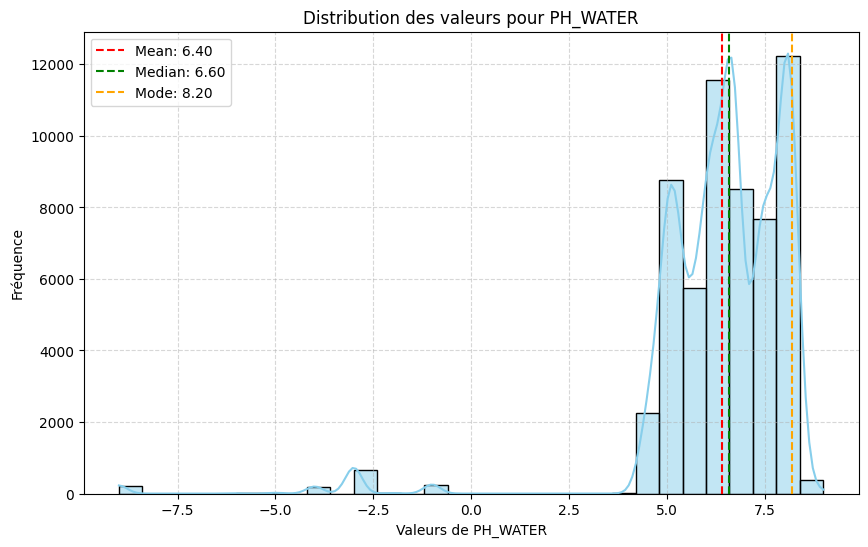

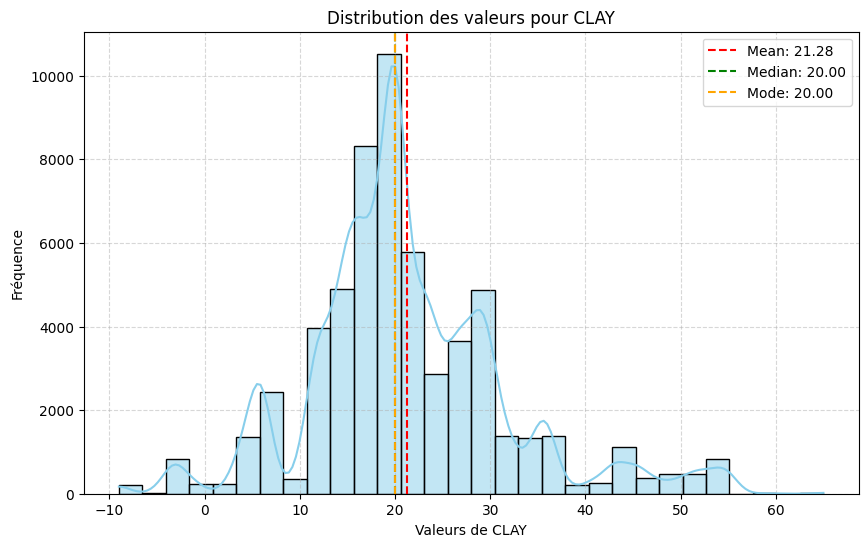

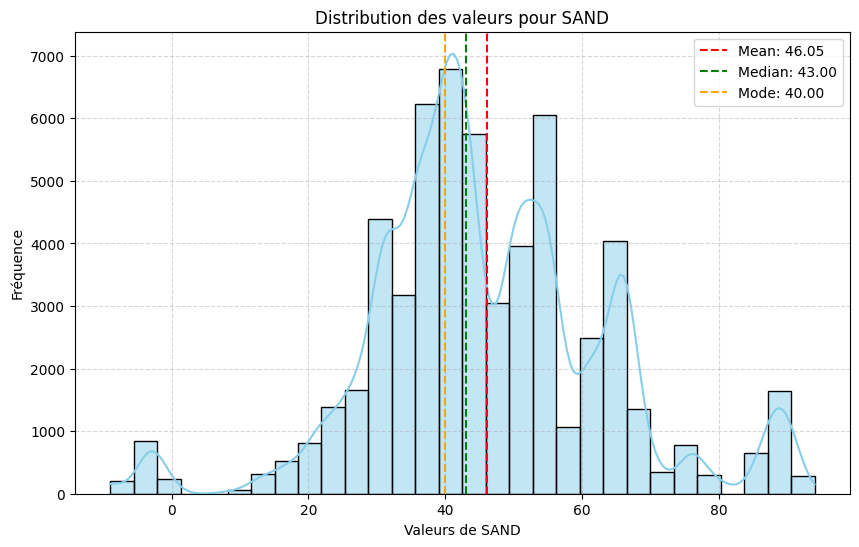

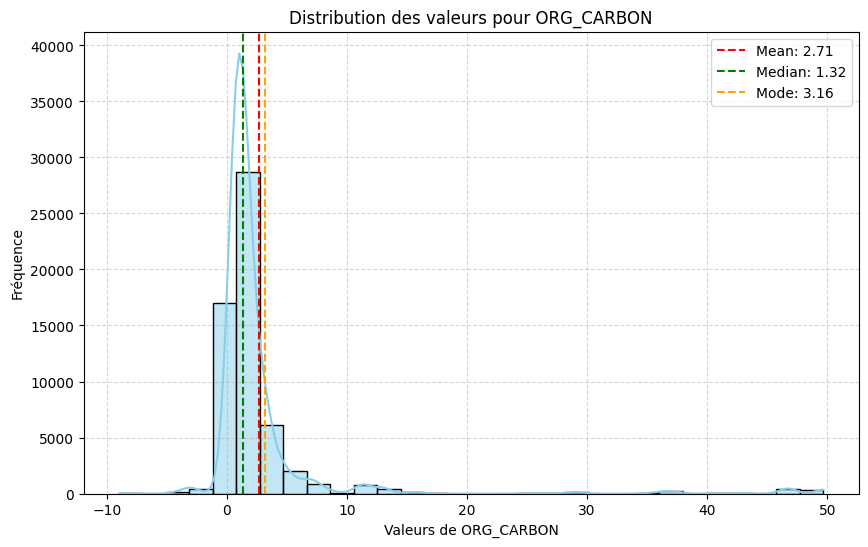

In [ ]:
soil_features = ["PH_WATER", "CLAY", "SAND", "ORG_CARBON"]

for feature in soil_features:
    vals = df_soil[feature].dropna()
    
    mean_val = vals.mean()
    median_val = vals.median()
    mode_val = vals.mode().iloc[0] if not vals.mode().empty else None
    
    plt.figure(figsize=(10,6))
    sns.histplot(vals, bins=30, kde=True, color='skyblue')
    
    # Ajouter lignes pour moyenne, médiane et mode
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
    if mode_val is not None:
        plt.axvline(mode_val, color='orange', linestyle='--', label=f'Mode: {mode_val:.2f}')
    
    plt.title(f"Distribution des valeurs pour {feature}")
    plt.xlabel(f"Valeurs de {feature}")
    plt.ylabel("Fréquence")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


### Missing values 

In [ ]:
print("\n Valeurs manquantes par colonne :")
missing = df_soil.isnull().sum()
print(missing)


 Valeurs manquantes par colonne :
COARSE              0
SAND                0
SILT                0
CLAY                0
TEXTURE_USDA     1289
TEXTURE_SOTER       0
BULK                0
REF_BULK         1289
ORG_CARBON        672
PH_WATER            0
TOTAL_N             0
CN_RATIO            0
CEC_SOIL            0
CEC_CLAY            0
CEC_EFF             0
TEB                 0
BSAT                0
ALUM_SAT            0
ESP                 0
TCARBON_EQ          0
GYPSUM              0
ELEC_COND           0
dtype: int64


### Valeurs Uniques

In [ ]:
# Afficher les valeurs uniques pour chaque colonne
for col in df_soil.columns:
    unique_vals = df_soil[col].dropna().unique()
    print(f"\nColonne : {col}")
    print(f"Nombre de valeurs uniques : {len(unique_vals)}")
    print(f"Valeurs uniques (extrait) : {unique_vals[:20]}{'...' if len(unique_vals) > 20 else ''}")



Colonne : COARSE
Nombre de valeurs uniques : 44
Valeurs uniques (extrait) : [ 5  2 16 11  9  8 12 17 20 15  4 19 21  3  7  6 10  1 14 13]...

Colonne : SAND
Nombre de valeurs uniques : 86
Valeurs uniques (extrait) : [67 24 52 57 59 78 53 26 35 56 68 36 54 77 25 50 55 45 49 64]...

Colonne : SILT
Nombre de valeurs uniques : 65
Valeurs uniques (extrait) : [18 52 27 28 11 34 25 20 23 21 12 51 24 32 31 56 16 41 50 26]...

Colonne : CLAY
Nombre de valeurs uniques : 63
Valeurs uniques (extrait) : [15 24 21 23 11 19 22 31 12 41 37 25 20 10 26 14 13 17 49 29]...

Colonne : TEXTURE_USDA
Nombre de valeurs uniques : 9
Valeurs uniques (extrait) : [11.  7. 10.  5.  3.  9. 12.  4.  8.]

Colonne : TEXTURE_SOTER
Nombre de valeurs uniques : 5
Valeurs uniques (extrait) : ['C' 'M' 'F' '-' 'V']

Colonne : BULK
Nombre de valeurs uniques : 103
Valeurs uniques (extrait) : [1.35000002 1.44000006 1.39999998 1.52999997 1.37       1.46000004
 1.07000005 1.41999996 1.27999997 1.40999997 1.48000002 1.42999995
 1.

### Detection des outliers

In [ ]:
def detect_outliers_iqr(df, col):
    """
    Détecte les outliers d'une colonne selon la méthode IQR.
    Retourne les valeurs considérées comme outliers.
    """
    vals = df[col].dropna()
    Q1 = vals.quantile(0.25)
    Q3 = vals.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = vals[(vals < lower_bound) | (vals > upper_bound)]
    return outliers

# Colonnes numériques
cols_numeriques = df_soil.select_dtypes(include=[np.number]).columns.tolist()

# Détection des outliers pour chaque colonne
outliers_dict = {}
for col in cols_numeriques:
    outliers_dict[col] = detect_outliers_iqr(df_soil, col)
    print(f"\nVariable : {col}")
    print(f"Nombre d'outliers : {len(outliers_dict[col])}")
    if not outliers_dict[col].empty:
        print(f"Exemples d'outliers : {outliers_dict[col].values[:10]}")
    else:
        print("Aucun outlier détecté")



Variable : COARSE
Nombre d'outliers : 458
Exemples d'outliers : [46 46 46 46 46 46 46 46 46 46]

Variable : SAND
Nombre d'outliers : 3871
Exemples d'outliers : [88 90 90 90 89 89 87 87 89 86]

Variable : SILT
Nombre d'outliers : 1307
Exemples d'outliers : [-4 -4 -4 -4 -4 -4 -4 -4 -4 -4]

Variable : CLAY
Nombre d'outliers : 3967
Exemples d'outliers : [49 49 49 49 49 49 49 49 49 49]

Variable : TEXTURE_USDA
Nombre d'outliers : 0
Aucun outlier détecté

Variable : BULK
Nombre d'outliers : 5859
Exemples d'outliers : [0.81999999 0.94999999 0.94999999 0.85000002 0.85000002 0.85000002
 0.85000002 0.85000002 0.85000002 0.83999997]

Variable : REF_BULK
Nombre d'outliers : 4022
Exemples d'outliers : [1.40999997 1.40999997 1.37       1.37       1.37       1.37
 1.37       1.37       1.37       1.37      ]

Variable : ORG_CARBON
Nombre d'outliers : 6105
Exemples d'outliers : [5.87699986 5.51699972 5.51699972 5.51699972 5.51699972 5.51699972
 5.51699972 5.51699972 5.51699972 5.51699972]

Variable :

### Boxplot

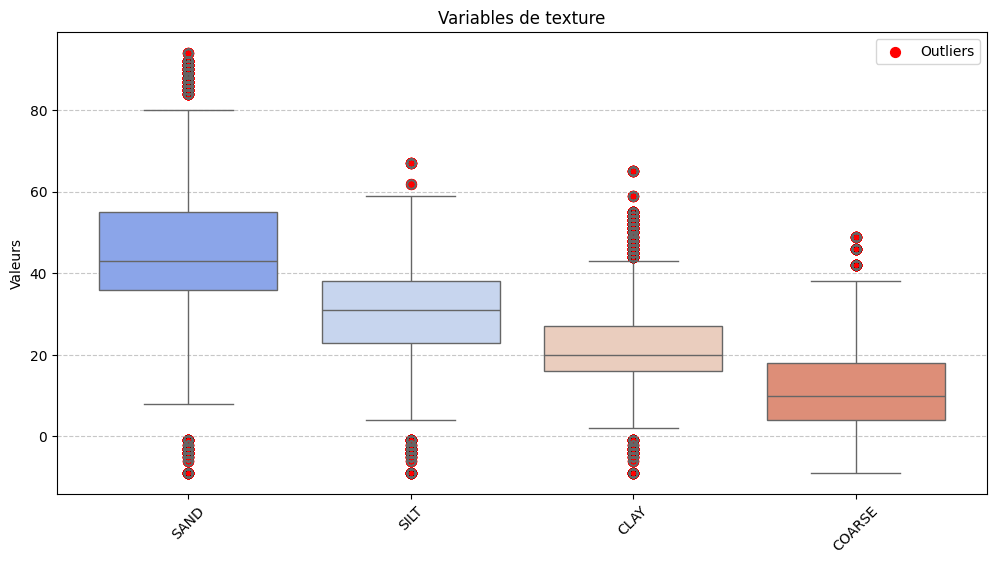

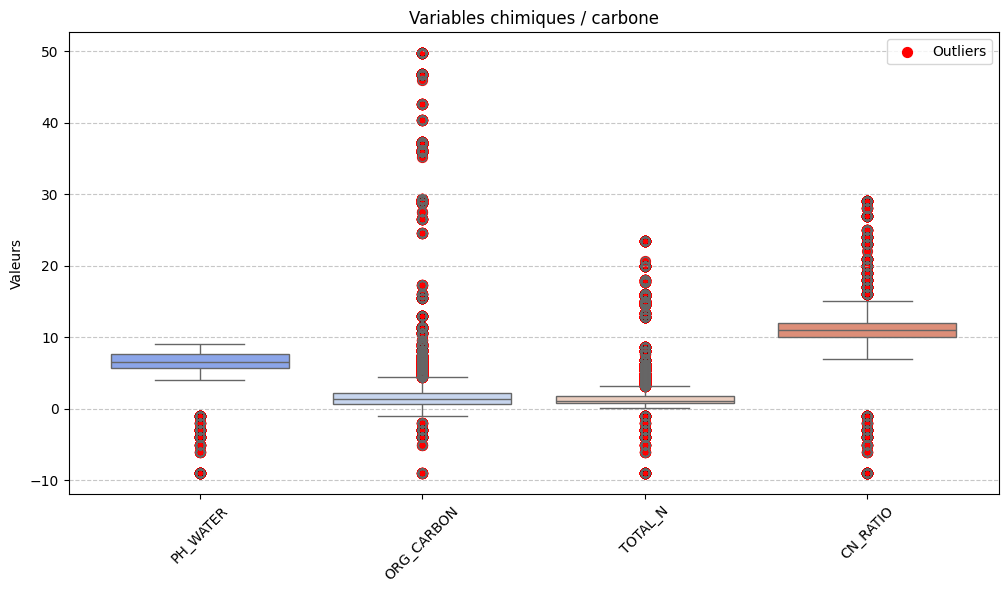

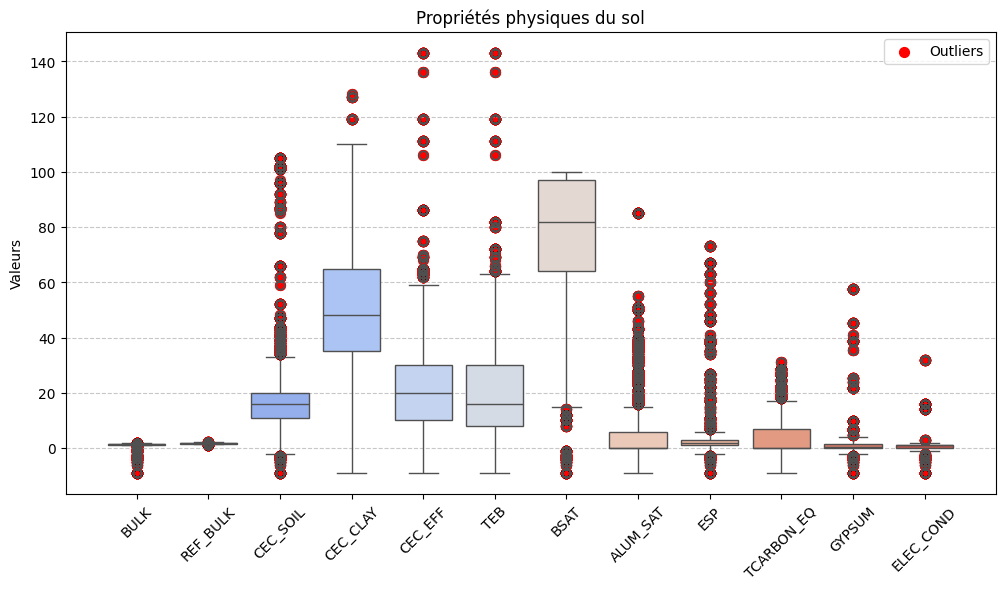

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Séparer les variables par type / échelle
texture_vars = ["SAND", "SILT", "CLAY", "COARSE"]
chem_vars = ["PH_WATER", "ORG_CARBON", "TOTAL_N", "CN_RATIO"]
phys_vars = ["BULK", "REF_BULK", "CEC_SOIL", "CEC_CLAY", "CEC_EFF", "TEB", 
             "BSAT", "ALUM_SAT", "ESP", "TCARBON_EQ", "GYPSUM", "ELEC_COND"]

def plot_box_with_outliers(df, cols, title, outliers_dict):
    plt.figure(figsize=(12,6))
    sns.boxplot(data=df[cols], palette="coolwarm", showfliers=True)
    
    # Ajouter les outliers détectés par IQR en rouge
    for i, col in enumerate(cols):
        y = outliers_dict[col].values
        x = [i] * len(y)
        plt.scatter(x, y, color='red', s=50, label='Outliers' if i==0 else "")
    
    plt.title(title)
    plt.ylabel("Valeurs")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    if any(len(outliers_dict[col]) > 0 for col in cols):
        plt.legend()
    plt.show()

# Boxplots séparés avec outliers
plot_box_with_outliers(df_soil, texture_vars, "Variables de texture", outliers_dict)
plot_box_with_outliers(df_soil, chem_vars, "Variables chimiques / carbone", outliers_dict)
plot_box_with_outliers(df_soil, phys_vars, "Propriétés physiques du sol", outliers_dict)


### Histogrammes

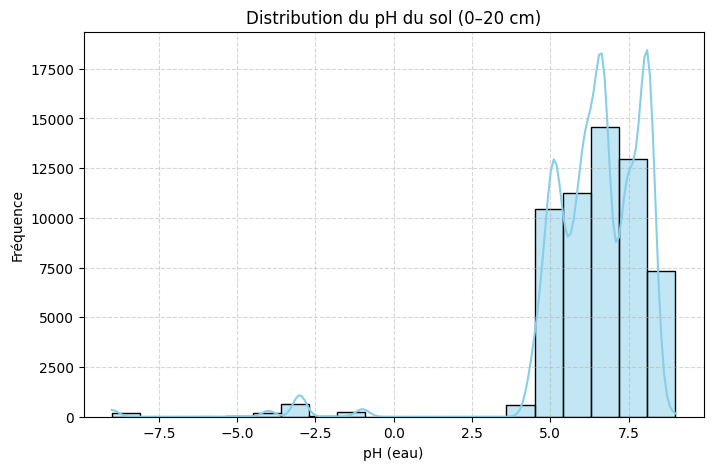

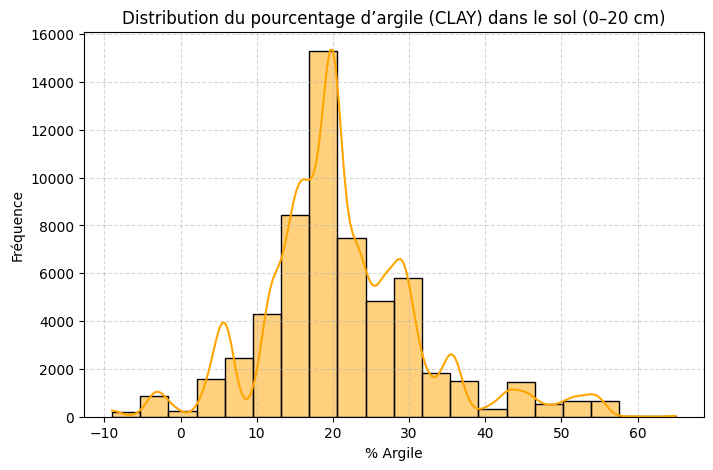

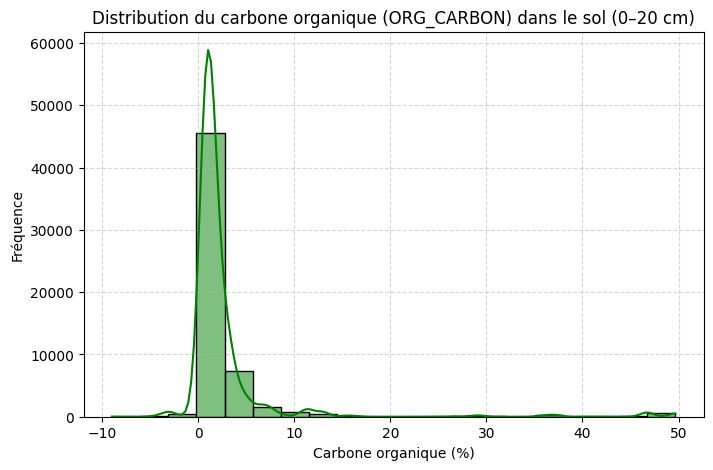

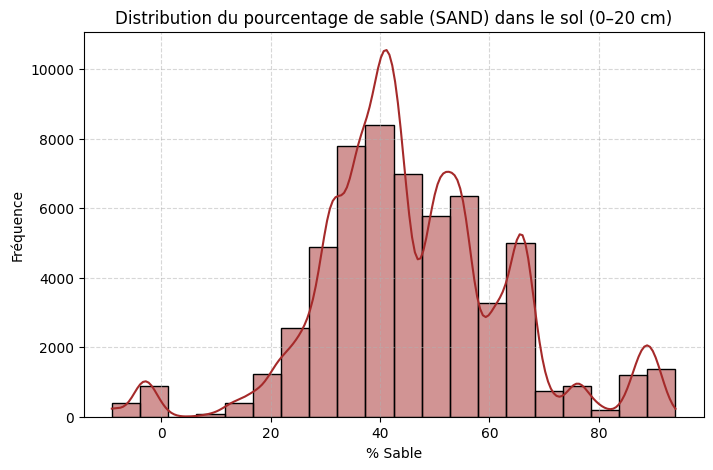

In [ ]:
# Exemple 1 : histogramme du pH
if "PH_WATER" in df_soil.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df_soil["PH_WATER"].dropna(), bins=20, kde=True, color="skyblue")
    plt.title("Distribution du pH du sol (0–20 cm)")
    plt.xlabel("pH (eau)")
    plt.ylabel("Fréquence")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

# Exemple 2 : histogramme du % d’argile
if "CLAY" in df_soil.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df_soil["CLAY"].dropna(), bins=20, kde=True, color="orange")
    plt.title("Distribution du pourcentage d’argile (CLAY) dans le sol (0–20 cm)")
    plt.xlabel("% Argile")
    plt.ylabel("Fréquence")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

# Exemple 3 : histogramme du carbone organique
if "ORG_CARBON" in df_soil.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df_soil["ORG_CARBON"].dropna(), bins=20, kde=True, color="green")
    plt.title("Distribution du carbone organique (ORG_CARBON) dans le sol (0–20 cm)")
    plt.xlabel("Carbone organique (%)")
    plt.ylabel("Fréquence")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show() 

# Exemple 4 : histogramme du % de sable
if "SAND" in df_soil.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df_soil["SAND"].dropna(), bins=20, kde=True, color="brown")
    plt.title("Distribution du pourcentage de sable (SAND) dans le sol (0–20 cm)")
    plt.xlabel("% Sable")
    plt.ylabel("Fréquence")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


## __Bivariante__

### Scatter plot 

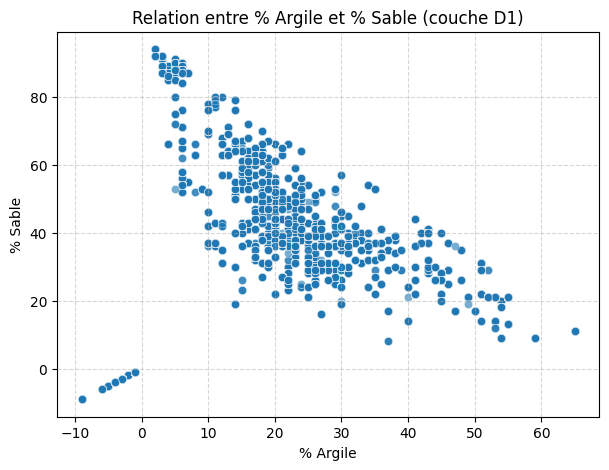

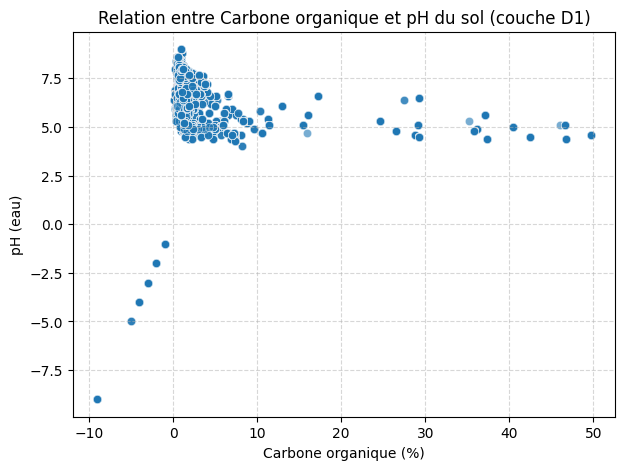

In [ ]:
if "CLAY" in df_soil.columns and "SAND" in df_soil.columns:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df_soil, x="CLAY", y="SAND", alpha=0.6)
    plt.title("Relation entre % Argile et % Sable (couche D1)")
    plt.xlabel("% Argile")
    plt.ylabel("% Sable")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

if "ORG_CARBON" in df_soil.columns and "PH_WATER" in df_soil.columns:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df_soil, x="ORG_CARBON", y="PH_WATER", alpha=0.6)
    plt.title("Relation entre Carbone organique et pH du sol (couche D1)")
    plt.xlabel("Carbone organique (%)")
    plt.ylabel("pH (eau)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show() 

### Matrice de correlation 


 MATRICE DE CORRÉLATION :
                COARSE      SAND      SILT      CLAY  TEXTURE_USDA      BULK  \
COARSE        1.000000  0.312652 -0.000165 -0.096840      0.260192  0.200897   
SAND          0.312652  1.000000 -0.453381 -0.459114      0.792771  0.437539   
SILT         -0.000165 -0.453381  1.000000  0.274511     -0.362413  0.309863   
CLAY         -0.096840 -0.459114  0.274511  1.000000     -0.861217  0.319763   
TEXTURE_USDA  0.260192  0.792771 -0.362413 -0.861217      1.000000  0.153285   
BULK          0.200897  0.437539  0.309863  0.319763      0.153285  1.000000   
REF_BULK     -0.151584 -0.760483  0.258960  0.923629     -0.761995 -0.017184   
ORG_CARBON    0.126583 -0.204800  0.313807  0.088329     -0.186451 -0.265799   
PH_WATER      0.207284  0.336669  0.361853  0.285090      0.094547  0.841356   
TOTAL_N       0.158980 -0.142200  0.478567  0.204604     -0.229044  0.135588   
CN_RATIO      0.348674  0.227112  0.360137  0.118127     -0.057612  0.386088   
CEC_SOIL     

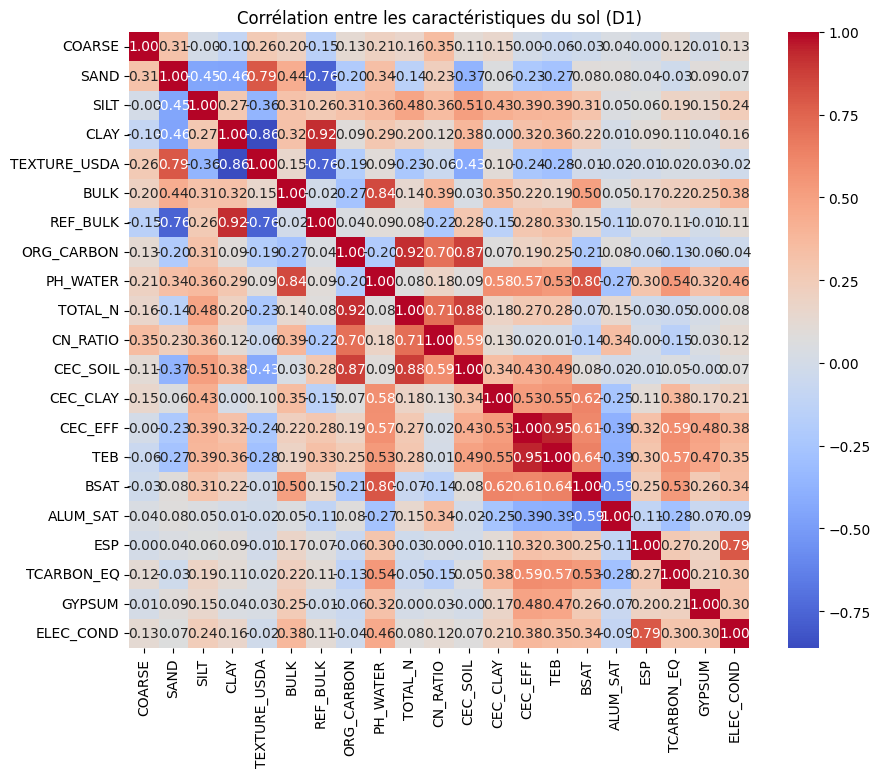

In [ ]:
# Matrice de corrélation
corr = df_soil[cols_numeriques].corr()
print("\n MATRICE DE CORRÉLATION :")
print(corr)

# Heatmap de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélation entre les caractéristiques du sol (D1)")
plt.show()

<div class="alert alert-block alert-success">
<b>Step 1.2</b> Data Preprocessing
</div>

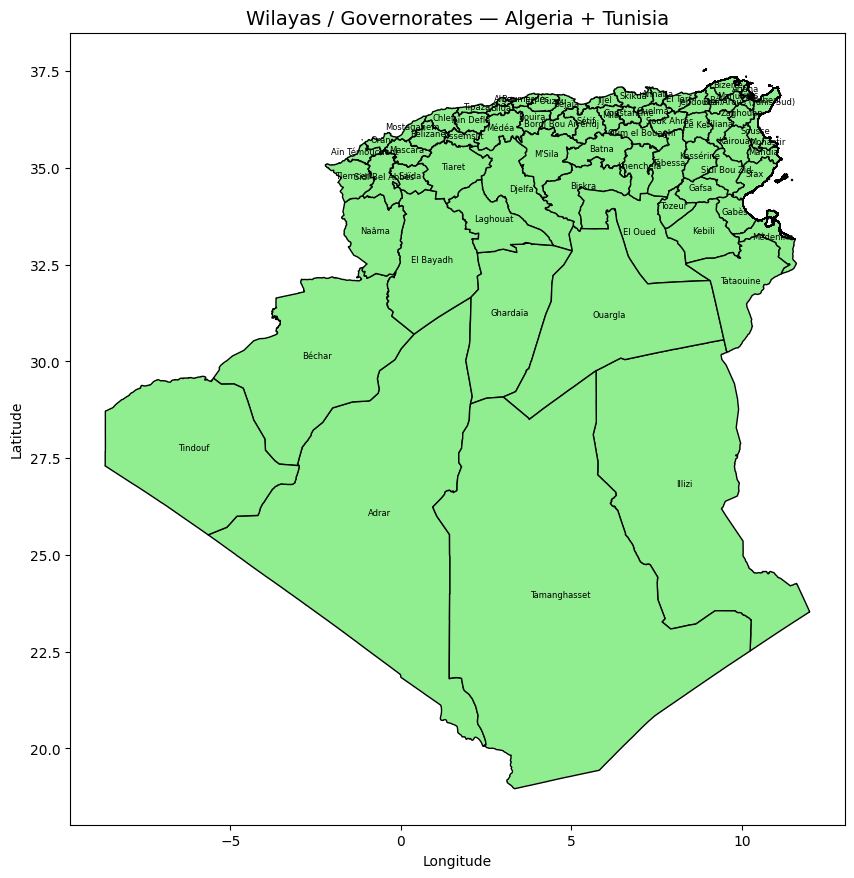

In [22]:
# Lecture des shapefiles
algeria = gpd.read_file("Datasets/dz_shp/gadm41_DZA_1.shp")
tunisia = gpd.read_file("Datasets/tun_shp/gadm41_TUN_shp/gadm41_TUN_1.shp")

# Harmonisation du système de coordonnées
algeria = algeria.to_crs("EPSG:4326")
tunisia = tunisia.to_crs("EPSG:4326")

# Fusion des shapefiles (Algérie + Tunisie)
north_africa = pd.concat([algeria, tunisia])


# Plot the merged shapefile
fig, ax = plt.subplots(figsize=(10, 12))
north_africa.plot(ax=ax, edgecolor='black', facecolor='lightgreen')

# Optional: add labels for each wilaya/governorate
for idx, row in north_africa.iterrows():
    x, y = row.geometry.centroid.coords[0]  # get centroid coordinates
    ax.text(x, y, row['NAME_1'], horizontalalignment='center', fontsize=6)

ax.set_title("Wilayas / Governorates — Algeria + Tunisia", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## _Fire Datasets_

### _Handling missing values_

`No missing values`

### _Removing outliers_

`is it okay to use log on here to reduce skew?`

In [77]:
cols_fire = ['bright_ti4', 'bright_ti5', 'frp']

# Detect outlier bounds
outlier_bounds = {}
for col in cols_fire:
    Q1 = gdf_fire[col].quantile(0.25)
    Q3 = gdf_fire[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_bounds[col] = (lower, upper)
    print(f"{col}: lower={lower:.2f}, upper={upper:.2f}")

# Handle outliers in-place (cap only negative values)
for col in cols_fire:
    gdf_fire[col] = gdf_fire[col].clip(lower=0)


bright_ti4: lower=257.35, upper=385.43
bright_ti5: lower=260.10, upper=320.90
frp: lower=-3.01, upper=8.07


### _Handling errors_

In [78]:
# Check duplicates
duplicates = gdf_fire.duplicated()
print(f"Number of duplicates: {duplicates.sum()}")

Number of duplicates: 0


### _Removing useless columns_

In [16]:
print(gdf_fire.columns)

Index(['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_ti5', 'frp', 'daynight', 'type', 'country', 'geometry'],
      dtype='object')


In [17]:
gdf_fire = gdf_fire[['latitude', 'longitude']]


In [18]:
gdf_fire['fire'] = 1

C:\Users\dell\AppData\Local\Temp\ipykernel_10256\690081166.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf_fire['fire'] = 1


In [19]:
gdf_fire.head()

,latitude,longitude,fire
0,27.72818,9.87200,1
1,28.63288,9.77909,1
2,28.64012,9.77953,1
3,36.74886,6.25409,1
4,35.87978,4.44782,1


In [14]:
# File path
save_path = os.path.join(save_dir, "gdf_fire.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(gdf_fire, f);

## _Land Cover Datasets_

### _Handling missing values_

In [79]:
print(merged_countries_landcover.isnull().sum())

LCCMode         14872
LCCOwnLabel     14872
ID                  0
LC              14872
MapCode         14872
GRIDCODE            0
LPos            14872
LCCLevel        14872
LCCLabel        14872
geometry            0
LCCOwnDescr    438513
dtype: int64


`Dropping LCCOwnDescr`

In [23]:
merged_countries_landcover.drop(columns=['LCCOwnDescr'], inplace=True)

### _Removing outliers_

`We can't because they're all codes`

### _Inconsistencies in spelling or case_

In [24]:
merged_countries_landcover['LCCLabel'] = merged_countries_landcover['LCCLabel'].str.strip().str.lower()
merged_countries_landcover['LC'] = merged_countries_landcover['LC'].str.strip().str.lower()

### _Saving dataset_

In [26]:
# Folder path
save_dir = "data/processed"
os.makedirs(save_dir, exist_ok=True)  # Create folder if it doesn't exist

# File path
save_path = os.path.join(save_dir, "merged_countries_landcover.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(merged_countries_landcover, f);

In [13]:
# Folder path
save_dir = "data/processed"
os.makedirs(save_dir, exist_ok=True)  # Create folder if it doesn't exist

# File path
save_path = os.path.join(save_dir, "merged_countries_landcover_no_legend.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(merged_countries_landcover_no_legend, f);

### __Loading__

In [4]:
save_path = "data/processed/merged_countries_landcover.pkl"

with open(save_path, "rb") as f:
    merged_countries_landcover = pickle.load(f)


## _Climate Datasets_

In [27]:
def extraire_moyenne_par_wilaya(files, shapefile):
    """
    Calcule la moyenne par wilaya pour chaque raster.
    
    files     : liste des fichiers .tif
    shapefile : GeoDataFrame des wilayas (level 1)
    
    Retourne : DataFrame avec colonnes [wilaya, annee, mois, variable, moyenne]
    """
    results = []

    for f in files:
        # Extraire nom de fichier et informations
        fname = os.path.basename(f).replace(".tif","")
        parts = fname.split("_")  # ex: ['wc2.1','cruts4.09','5m','prec','2020-01']
        variable = parts[3]       # prec / tmax / tmin
        year, month = map(int, parts[4].split("-"))

        # Calcul des statistiques zonales (moyenne par wilaya)
        stats = zonal_stats(
            shapefile,
            f,
            stats=['mean'],
            nodata=np.nan,
            geojson_out=True
        )

        # Stocker les résultats
        for s in stats:
            wilaya_name = s['properties']['NAME_1']  # niveau 1 = wilaya
            results.append({
                "wilaya": wilaya_name,
                "annee": year,
                "mois": month,
                "variable": variable,
                "moyenne": s['properties']['mean']
            })

    return pd.DataFrame(results)

In [48]:
# Paths to separate folders
prec_dir = "Datasets\Climate\clip_prec"
tmax_dir = "Datasets\Climate\clip_tmax"
tmin_dir = "Datasets\Climate\clip_tmin"

# Get files from each folder
files_prec = glob.glob(os.path.join(prec_dir, "*.tif"))
files_tmax = glob.glob(os.path.join(tmax_dir, "*.tif"))
files_tmin = glob.glob(os.path.join(tmin_dir, "*.tif"))

# Calcul des moyennes par wilaya
#df_prec = extraire_moyenne_par_wilaya(files_prec, north_africa)
#df_tmax = extraire_moyenne_par_wilaya(files_tmax, north_africa)
#df_tmin = extraire_moyenne_par_wilaya(files_tmin, north_africa)

# Combiner tout dans un seul DataFrame
df_wilaya_climate = pd.concat([df_prec, df_tmax, df_tmin], ignore_index=True)

In [30]:
df_wilaya_climate.head()

,wilaya,annee,mois,variable,moyenne
0,Adrar,2020,1,prec,0.503346
1,Aïn Defla,2020,1,prec,58.566271
2,Aïn Témouchent,2020,1,prec,31.811764
3,Alger,2020,1,prec,60.985413
4,Annaba,2020,1,prec,76.967505


### _Handling missing data_

In [31]:
df_wilaya_climate.isnull().sum()

wilaya      0
annee       0
mois        0
variable    0
moyenne     0
dtype: int64

In [32]:
df_prec.sum

<bound method DataFrame.sum of               wilaya  annee  mois variable    moyenne
0              Adrar   2020     1     prec   0.503346
1          Aïn Defla   2020     1     prec  58.566271
2     Aïn Témouchent   2020     1     prec  31.811764
3              Alger   2020     1     prec  60.985413
4             Annaba   2020     1     prec  76.967505
...              ...    ...   ...      ...        ...
4315          Sousse   2024    12     prec  31.266454
4316       Tataouine   2024    12     prec  10.452982
4317          Tozeur   2024    12     prec   5.126190
4318           Tunis   2024    12     prec  54.524999
4319        Zaghouan   2024    12     prec  44.916025

[4320 rows x 5 columns]>

### _Outliers_

In [33]:
def detect_outliers_iqr(df, variable_name):
    """
    Detects outliers in the 'moyenne' column for a specific variable using IQR.
    """
    sub = df[df['variable'] == variable_name]['moyenne']
    Q1 = sub.quantile(0.25)
    Q3 = sub.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = sub[(sub < lower_bound) | (sub > upper_bound)]
    print(f"{variable_name} → {len(outliers)} outliers")
    return outliers


# Example:
outliers_prec = detect_outliers_iqr(df_wilaya_climate, "prec")
outliers_tmax = detect_outliers_iqr(df_wilaya_climate, "tmax")
outliers_tmin = detect_outliers_iqr(df_wilaya_climate, "tmin")


prec → 262 outliers
tmax → 0 outliers
tmin → 0 outliers


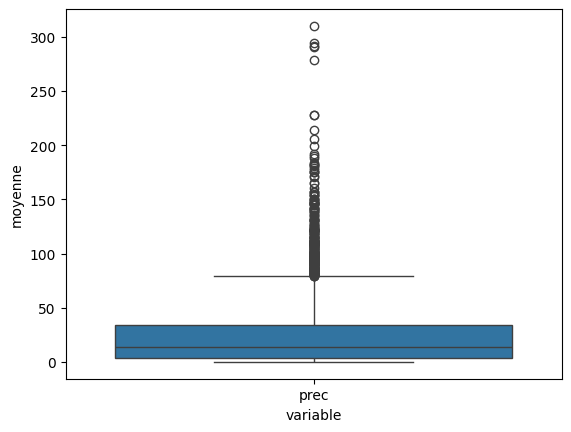

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x='variable', y='moyenne', data=df_wilaya_climate[df_wilaya_climate['variable']=='prec'])
plt.show()


In [ ]:
def cap_outliers(df, variable, lower_percentile=1, upper_percentile=99):
    sub = df[df['variable']==variable]
    low = np.percentile(sub['moyenne'], lower_percentile)
    high = np.percentile(sub['moyenne'], upper_percentile)
    
    df.loc[df['variable']==variable, 'moyenne'] = np.clip(sub['moyenne'], low, high)
    print(f"{variable} capped at {low:.2f} (lower) and {high:.2f} (upper)")
    return df

df_wilaya_climate = cap_outliers(df_wilaya_climate, 'prec')

Keeps most values intact.

Removes extreme spikes that can bias models.

In [39]:
# Folder path
save_dir = "data/processed"
os.makedirs(save_dir, exist_ok=True)  # Create folder if it doesn't exist

# File path
save_path = os.path.join(save_dir, "df_wilaya_climate.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(df_wilaya_climate, f);

# File path
save_path = os.path.join(save_dir, "df_prec.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(df_prec, f);

# File path
save_path = os.path.join(save_dir, "df_tmax.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(df_tmax, f);

# File path
save_path = os.path.join(save_dir, "df_tmin.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(df_tmin, f);

### _Loading Files_

In [5]:
save_path = "data/processed/df_wilaya_climate.pkl"

with open(save_path, "rb") as f:
    df_wilaya_climate = pickle.load(f)


save_path = "data/processed/df_prec.pkl"

with open(save_path, "rb") as f:
    df_prec = pickle.load(f)

save_path = "data/processed/df_tmin.pkl"

with open(save_path, "rb") as f:
    df_tmin = pickle.load(f)

save_path = "data/processed/df_tmax.pkl"

with open(save_path, "rb") as f:
    df_tmax = pickle.load(f)

## _Elevation Datasets_

`Here we're going to load our .tif file and the loaded thingy will be a numpy array`

In [38]:
elevation_clipped = "Datasets/Elevation/clip_north_africa/elevation_north_africa.tif"



# Open the clipped raster
with rasterio.open(elevation_clipped) as src:
    data = src.read(1)  # read first (and usually only) band
    mask = data != src.nodata
    # Get coordinates of valid pixels
    rows, cols = np.where(mask)
    xs, ys = src.transform * (cols, rows)
    values = data[mask]

# Create DataFrame
df_elev = pd.DataFrame({
    'x': xs,
    'y': ys,
    'elevation': values
})

print(df_elev.head(30))

           x          y  elevation
0   8.954028  37.558194          0
1   8.945694  37.554028          0
2   8.941528  37.541528          1
3   8.945694  37.541528          0
4   8.937361  37.537361          0
5   8.941528  37.537361         12
6   8.945694  37.537361          0
7   8.916528  37.533194          0
8   8.920694  37.533194          0
9   8.924861  37.533194          0
10  8.929028  37.533194          0
11  8.933194  37.533194          0
12  8.937361  37.533194         12
13  8.941528  37.533194        127
14  8.945694  37.533194         58
15  8.949861  37.533194          0
16  8.908194  37.529028          0
17  8.912361  37.529028         37
18  8.916528  37.529028         36
19  8.920694  37.529028        149
20  8.924861  37.529028        145
21  8.929028  37.529028        166
22  8.933194  37.529028         80
23  8.937361  37.529028         50
24  8.941528  37.529028         81
25  8.945694  37.529028        112
26  8.949861  37.529028         90
27  8.954028  37.529

### _Handling missing data_

`here 0 isnt counted as na`

In [ ]:

df_elev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13119560 entries, 0 to 13119559
Data columns (total 3 columns):
 #   Column     Dtype  
---  ------     -----  
 0   x          float64
 1   y          float64
 2   elevation  int16  
dtypes: float64(2), int16(1)
memory usage: 225.2 MB


In [18]:
missing_counts = df_elev.isna().sum()
print(missing_counts)

x            0
y            0
elevation    0
dtype: int64


### _Handling outliers_

In [42]:
def detect_outliers_iqr(df, column_name):
    """
    Detects outliers in a numeric column of a DataFrame using the IQR method.
    """
    sub = df[column_name]
    Q1 = sub.quantile(0.25)
    Q3 = sub.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = sub[(sub < lower_bound) | (sub > upper_bound)]
    print(f"{column_name} → {len(outliers)} outliers")
    return outliers

# Example usage:
outliers_elev = detect_outliers_iqr(df_elev, "elevation")



elevation → 382107 outliers


`i dont think we can deal with outliers here? + some of them are out of the borders`

### _Saving_

In [44]:
# Folder path
save_dir = "data/processed"
os.makedirs(save_dir, exist_ok=True)  # Create folder if it doesn't exist

# File path
save_path = os.path.join(save_dir, "df_elev.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(df_elev, f);


In [6]:
save_path = "data/processed/df_elev.pkl"

with open(save_path, "rb") as f:
    df_elev = pickle.load(f)

## _Soil Datasets_

### _Loading clipped raster_

`have to add here loading all those df that we saved up`

In [3]:
clipped_soil_path = "Datasets/Soil/Clip/hwsd2_north_africa.tif"
cols = [
    "COARSE", "SAND", "SILT", "CLAY", "TEXTURE_USDA", "TEXTURE_SOTER",
    "BULK", "REF_BULK", "ORG_CARBON", "PH_WATER", "TOTAL_N", "CN_RATIO",
    "CEC_SOIL", "CEC_CLAY", "CEC_EFF", "TEB", "BSAT", "ALUM_SAT", "ESP",
    "TCARBON_EQ", "GYPSUM", "ELEC_COND"
]

with rasterio.open(clipped_soil_path) as src:
    bands = src.read()  # (num_bands, rows, cols)
    transform = src.transform
    nodata = src.nodata

num_bands, n_rows, n_cols = bands.shape
print("Bands:", num_bands, "Rows:", n_rows, "Cols:", n_cols)

Bands: 1 Rows: 2233 Cols: 2480


In [4]:
print(df_mu.columns)
print(df_layers.columns)


Index(['ID', 'HWSD2_SMU_ID', 'WISE30s_SMU_ID', 'HWSD1_SMU_ID', 'COVERAGE',
       'SHARE', 'WRB4', 'WRB_PHASES', 'WRB2', 'WRB2_CODE', 'FAO90', 'KOPPEN',
       'TEXTURE_USDA', 'REF_BULK_DENSITY', 'BULK_DENSITY', 'DRAINAGE',
       'ROOT_DEPTH', 'AWC', 'PHASE1', 'PHASE2', 'ROOTS', 'IL', 'ADD_PROP'],
      dtype='object')
Index(['ID', 'HWSD2_SMU_ID', 'NSC_MU_SOURCE1', 'NSC_MU_SOURCE2',
       'WISE30s_SMU_ID', 'HWSD1_SMU_ID', 'COVERAGE', 'SEQUENCE', 'SHARE',
       'NSC', 'WRB_PHASES', 'WRB4', 'WRB2', 'FAO90', 'ROOT_DEPTH', 'PHASE1',
       'PHASE2', 'ROOTS', 'IL', 'SWR', 'DRAINAGE', 'AWC', 'ADD_PROP', 'LAYER',
       'TOPDEP', 'BOTDEP', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA',
       'TEXTURE_SOTER', 'BULK', 'REF_BULK', 'ORG_CARBON', 'PH_WATER',
       'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT',
       'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND'],
      dtype='object')


In [5]:
# Path to clipped raster
clipped_raster = "Datasets/Soil/Clip/hwsd2_north_africa.tif"

# Load raster
with rasterio.open(clipped_raster) as src:
    mu_raster = src.read(1).astype(int)  # Map Unit IDs
    transform = src.transform
    nodata = src.nodata

# Mask nodata
mask_valid = mu_raster != nodata

# Get coordinates for each pixel
rows, cols = np.where(mask_valid)
xs, ys = rasterio.transform.xy(transform, rows, cols)

# Extract MU IDs for valid pixels
mu_ids = mu_raster[rows, cols]

# Create initial DataFrame
df_pixels = pd.DataFrame({
    "MU_ID": mu_ids,
    "x": xs,
    "y": ys
})

# Join soil properties from HWSD
# Ensure your df_layers is filtered to D1 and columns uppercased
df_layers_d1 = df_layers[df_layers["LAYER"] == "D1"].copy()
df_layers_d1.columns = df_layers_d1.columns.str.upper()
df_mu_upper = df_mu.copy()
df_mu_upper.columns = df_mu_upper.columns.str.upper()

# Merge MU info
df_pixels = df_pixels.merge(
    df_mu_upper[["HWSD2_SMU_ID"]],
    left_on="MU_ID",
    right_on="HWSD2_SMU_ID",
    how="left"
)

# Merge soil properties
cols_properties = [
    "COARSE", "SAND", "SILT", "CLAY", "TEXTURE_USDA", "TEXTURE_SOTER",
    "BULK", "REF_BULK", "ORG_CARBON", "PH_WATER", "TOTAL_N", "CN_RATIO",
    "CEC_SOIL", "CEC_CLAY", "CEC_EFF", "TEB", "BSAT", "ALUM_SAT", "ESP",
    "TCARBON_EQ", "GYPSUM", "ELEC_COND"
]
df_pixels = df_pixels.merge(
    df_layers_d1[["HWSD2_SMU_ID"] + cols_properties],
    left_on="MU_ID",
    right_on="HWSD2_SMU_ID",
    how="left"
)

# Drop redundant columns
#df_pixels = df_pixels.drop(columns=["HWSD2_SMU_ID"])

print(df_pixels.head())
print("Shape:", df_pixels.shape)
df_pixels.columns

   MU_ID         x          y  HWSD2_SMU_ID_x  HWSD2_SMU_ID_y  COARSE  SAND  \
0  31805  8.945833  37.537500           31805           31805       9    87   
1  31805  8.945833  37.537500           31805           31805       5    33   
2  31802  8.912500  37.529167           31802           31802      11    40   
3  31802  8.912500  37.529167           31802           31802       9    25   
4  31802  8.920833  37.529167           31802           31802      11    40   

   SILT  CLAY  TEXTURE_USDA  ... CEC_SOIL  CEC_CLAY  CEC_EFF   TEB  BSAT  \
0     9     4          12.0  ...        4        33      3.0   3.0    76   
1    31    36           5.0  ...       20        34     15.0  17.0    82   
2    41    19           9.0  ...       11        26      6.0   5.0    47   
3    53    22           7.0  ...       15        51     14.0  12.0    65   
4    41    19           9.0  ...       11        26      6.0   5.0    47   

   ALUM_SAT  ESP  TCARBON_EQ  GYPSUM  ELEC_COND  
0         6    2  

Index(['MU_ID', 'x', 'y', 'HWSD2_SMU_ID_x', 'HWSD2_SMU_ID_y', 'COARSE', 'SAND',
       'SILT', 'CLAY', 'TEXTURE_USDA', 'TEXTURE_SOTER', 'BULK', 'REF_BULK',
       'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY',
       'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM',
       'ELEC_COND'],
      dtype='object')

In [6]:
df_pixels = df_pixels.drop(columns=['HWSD2_SMU_ID_x', 'HWSD2_SMU_ID_y'])

### _Handling missing data_

In [15]:
df_pixels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7070412 entries, 0 to 7070411
Data columns (total 27 columns):
 #   Column          Dtype  
---  ------          -----  
 0   MU_ID           int32  
 1   x               float64
 2   y               float64
 3   HWSD2_SMU_ID_x  int64  
 4   HWSD2_SMU_ID_y  int64  
 5   COARSE          int64  
 6   SAND            int64  
 7   SILT            int64  
 8   CLAY            int64  
 9   TEXTURE_USDA    float64
 10  TEXTURE_SOTER   object 
 11  BULK            float64
 12  REF_BULK        float64
 13  ORG_CARBON      float64
 14  PH_WATER        float64
 15  TOTAL_N         float64
 16  CN_RATIO        float64
 17  CEC_SOIL        int64  
 18  CEC_CLAY        int64  
 19  CEC_EFF         float64
 20  TEB             float64
 21  BSAT            int64  
 22  ALUM_SAT        int64  
 23  ESP             int64  
 24  TCARBON_EQ      float64
 25  GYPSUM          float64
 26  ELEC_COND       int64  
dtypes: float64(13), int32(1), int64(12), obje

In [23]:
missing_counts = df_pixels.isna().sum()
print(missing_counts)

MU_ID                  0
x                      0
y                      0
COARSE                 0
SAND                   0
SILT                   0
CLAY                   0
TEXTURE_USDA     1340051
TEXTURE_SOTER          0
BULK                   0
REF_BULK         1340051
ORG_CARBON             0
PH_WATER               0
TOTAL_N                0
CN_RATIO               0
CEC_SOIL               0
CEC_CLAY               0
CEC_EFF                0
TEB                    0
BSAT                   0
ALUM_SAT               0
ESP                    0
TCARBON_EQ             0
GYPSUM                 0
ELEC_COND              0
dtype: int64


In [8]:
# -------------------------------
# 1. TEXTURE_USDA (catégorielle)
# -------------------------------
df_pixels['TEXTURE_USDA'] = (
    df_pixels.groupby('MU_ID')['TEXTURE_USDA']
             .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))
)

# -------------------------------
# 2. REF_BULK (numérique)
# -------------------------------
df_pixels['REF_BULK'] = (
    df_pixels.groupby('MU_ID')['REF_BULK']
             .transform(lambda x: x.fillna(x.median()))
)

# Backup global si un MU_ID n'avait aucune valeur du tout
df_pixels['REF_BULK'] = df_pixels['REF_BULK'].fillna(df_pixels['REF_BULK'].median())


c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keep

In [9]:
df_pixels.isna().sum()


MU_ID            0
x                0
y                0
COARSE           0
SAND             0
SILT             0
CLAY             0
TEXTURE_USDA     0
TEXTURE_SOTER    0
BULK             0
REF_BULK         0
ORG_CARBON       0
PH_WATER         0
TOTAL_N          0
CN_RATIO         0
CEC_SOIL         0
CEC_CLAY         0
CEC_EFF          0
TEB              0
BSAT             0
ALUM_SAT         0
ESP              0
TCARBON_EQ       0
GYPSUM           0
ELEC_COND        0
dtype: int64

### _Handling outliers_

In [24]:
def summarize_outliers(df):
    """
    Detects and summarizes outliers in all numeric columns of a DataFrame using the IQR method.

    Returns a DataFrame with columns: 'Column', 'Num_Outliers', 'Percent_Outliers'.
    """
    numeric_cols = df.select_dtypes(include=["number"]).columns
    summary = []

    for col in numeric_cols:
        sub = df[col]
        Q1 = sub.quantile(0.25)
        Q3 = sub.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = sub[(sub < lower_bound) | (sub > upper_bound)]
        num_outliers = len(outliers)
        percent_outliers = (num_outliers / len(sub)) * 100

        summary.append({
            "Column": col,
            "Num_Outliers": num_outliers,
            "Percent_Outliers": percent_outliers
        })

    return pd.DataFrame(summary)

# Usage
outlier_summary = summarize_outliers(df_pixels)
print(outlier_summary)


          Column  Num_Outliers  Percent_Outliers
0          MU_ID       1656317         23.426032
1              x             0          0.000000
2              y             0          0.000000
3         COARSE         23581          0.333517
4           SAND       1340051         18.952941
5           SILT       1341469         18.972996
6           CLAY       1714225         24.245051
7   TEXTURE_USDA        370542          5.240741
8           BULK       1417594         20.049666
9       REF_BULK        166890          2.360400
10    ORG_CARBON       1893221         26.776672
11      PH_WATER       1428044         20.197465
12       TOTAL_N       1698067         24.016521
13      CN_RATIO       1341519         18.973703
14      CEC_SOIL         51720          0.731499
15      CEC_CLAY             0          0.000000
16       CEC_EFF        749933         10.606638
17           TEB        272714          3.857116
18          BSAT       1340051         18.952941
19      ALUM_SAT    

### _Dupes_

In [7]:
# Remove duplicates
df_pixels = df_pixels.drop_duplicates()


In [10]:
output_path = "data/processed/df_pixels.pkl"
df_pixels.to_pickle(output_path)
print(f" Dataset saved as pickle at: {output_path}")

 Dataset saved as pickle at: data/processed/df_pixels.pkl


## _Data Integration_

### __Loading the country shapefile__

In [18]:
north_africa.to_crs("EPSG:4326")
print(north_africa)

  GID_0  COUNTRY                                           geometry
0   DZA  Algeria  MULTIPOLYGON (((2.84187 36.7369, 2.84413 36.74...
0   TUN  Tunisia  MULTIPOLYGON (((8.35588 32.51756, 8.35474 32.5...


In [33]:
lat_res = 0.01
lon_res = 0.01

### __Prepare existing fire points__

In [35]:
fire_points = gdf_fire[['latitude', 'longitude']].copy()
fire_points['fire'] = 1
print(f"Points feu originaux: {len(fire_points):,}")

Points feu originaux: 90,250


In [20]:
gdf_fire.columns

Index(['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_ti5', 'frp', 'daynight', 'type', 'country', 'geometry', 'fire'],
      dtype='object')

### __GRID CREATION__

In [36]:
lat_min = np.floor(fire_points['latitude'].min() / lat_res) * lat_res
lat_max = np.ceil(fire_points['latitude'].max() / lat_res) * lat_res
lon_min = np.floor(fire_points['longitude'].min() / lon_res) * lon_res
lon_max = np.ceil(fire_points['longitude'].max() / lon_res) * lon_res

lat_grid = np.round(np.arange(lat_min, lat_max + lat_res/2, lat_res), 6)
lon_grid = np.round(np.arange(lon_min, lon_max + lon_res/2, lon_res), 6)

grid_points = pd.MultiIndex.from_product([lat_grid, lon_grid], names=['latitude', 'longitude']).to_frame(index=False)
print(f" Grille: {len(lat_grid)} × {len(lon_grid)} = {len(grid_points):,} cellules")

 Grille: 1774 × 1925 = 3,414,950 cellules


### __IDENTIFYING NON FIRES__

In [37]:
# Merge to find which grid points have no fire
df_no_fire = grid_points.merge(
    fire_points,
    on=['latitude','longitude'],
    how='left',
    indicator=True
)

df_no_fire = df_no_fire[df_no_fire['_merge'] == 'left_only'].copy()
df_no_fire['fire'] = 0
df_no_fire = df_no_fire.drop(columns=['_merge'])
print(f"✅ Points non-feu générés: {len(df_no_fire):,}")

✅ Points non-feu générés: 3,414,950


### __MERGING THEM__

In [38]:
df_final = pd.concat([fire_points, df_no_fire], ignore_index=True)
print(f"📊 Dataset combiné: {len(df_final):,} points")

# Shuffle dataset
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

📊 Dataset combiné: 3,505,200 points


In [39]:
output_path = "data/df_fire_full_0.01deg_allfires.csv"
df_final.to_csv(output_path, index=False)
print(f"💾 Dataset sauvegardé: {output_path}")

💾 Dataset sauvegardé: data/df_fire_full_0.01deg_allfires.csv


### __PLOT__

c:\Program Files\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


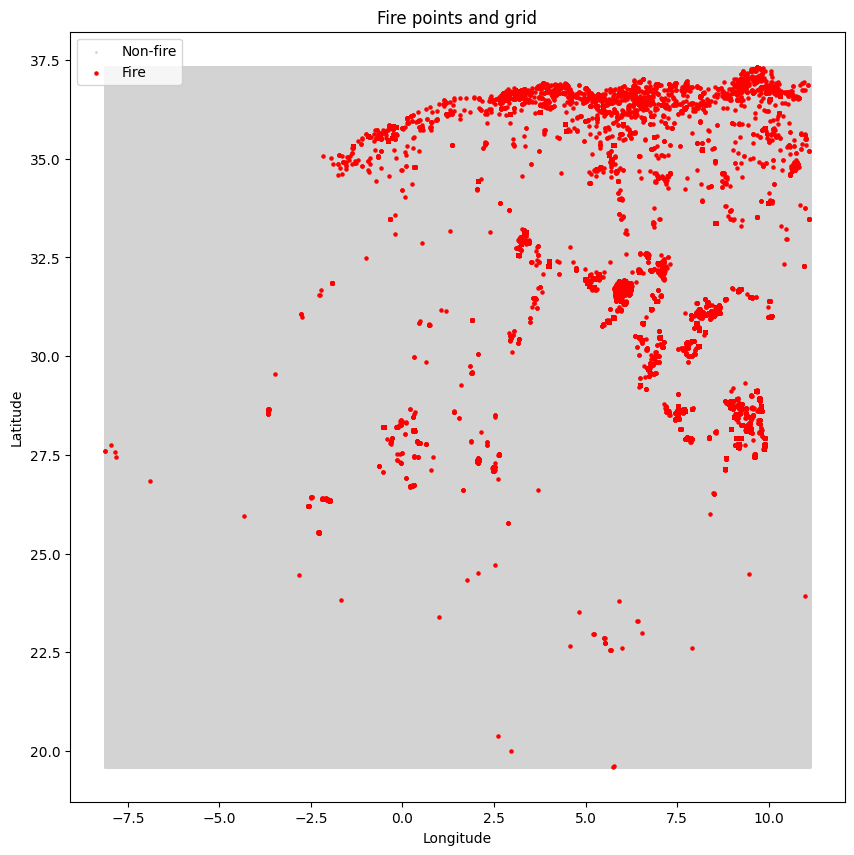

In [40]:
# Sample plotting (all points)
plt.figure(figsize=(10, 10))

# Plot non-fire points in light grey
plt.scatter(
    df_final[df_final['fire']==0]['longitude'], 
    df_final[df_final['fire']==0]['latitude'], 
    s=1, color='lightgrey', label='Non-fire'
)

# Plot fire points in red
plt.scatter(
    df_final[df_final['fire']==1]['longitude'], 
    df_final[df_final['fire']==1]['latitude'], 
    s=5, color='red', label='Fire'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Fire points and grid")
plt.legend()
plt.show()


In [42]:
# Separate fire and non-fire points
df_fire_points = df_final[df_final['fire']==1].copy()
df_non_fire = df_final[df_final['fire']==0].copy()

# Convert non-fire points to GeoDataFrame
gdf_non_fire = gpd.GeoDataFrame(
    df_non_fire,
    geometry=[Point(xy) for xy in zip(df_non_fire['longitude'], df_non_fire['latitude'])],
    crs="EPSG:4326"
)

# Clip non-fire points using spatial join
gdf_non_fire_clipped = gpd.sjoin(
    gdf_non_fire,
    north_africa,
    how="inner",
    predicate="within"
)

# Drop extra columns from sjoin
gdf_non_fire_clipped = gdf_non_fire_clipped[df_non_fire.columns]

# Combine clipped non-fire points with all fire points
df_final_clipped = pd.concat([df_fire_points, gdf_non_fire_clipped], ignore_index=True)

c:\Program Files\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


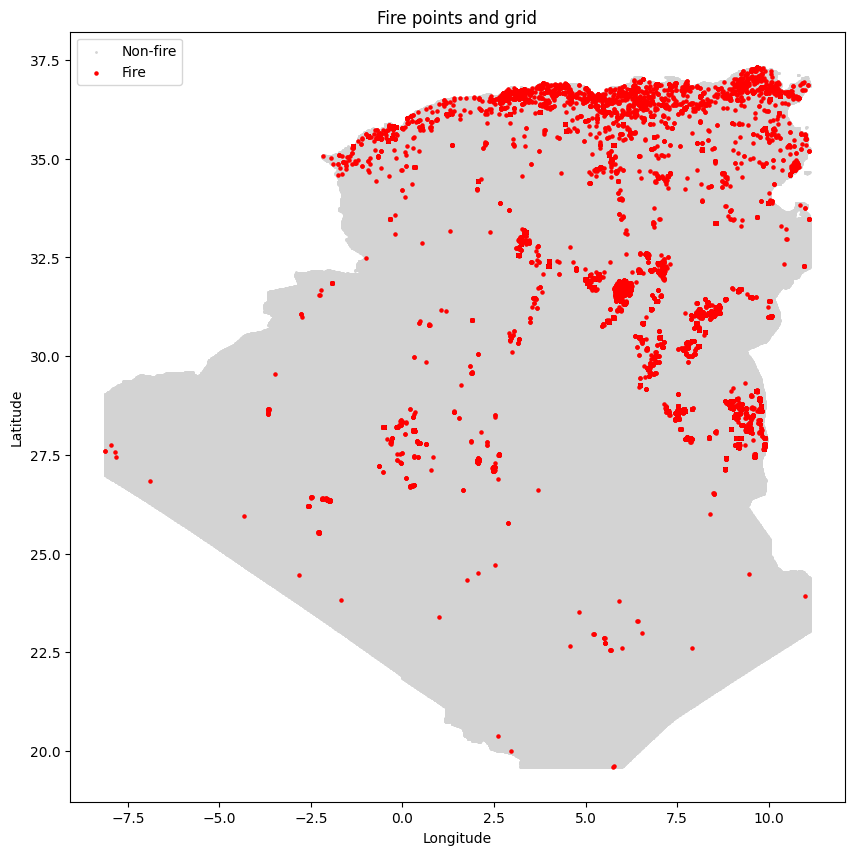

In [43]:
# Sample plotting (all points)
plt.figure(figsize=(10, 10))

# Plot non-fire points in light grey
plt.scatter(
    df_final_clipped[df_final_clipped['fire']==0]['longitude'], 
    df_final_clipped[df_final_clipped['fire']==0]['latitude'], 
    s=1, color='lightgrey', label='Non-fire'
)

# Plot fire points in red
plt.scatter(
    df_final_clipped[df_final_clipped['fire']==1]['longitude'], 
    df_final_clipped[df_final_clipped['fire']==1]['latitude'], 
    s=5, color='red', label='Fire'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Fire points and grid")
plt.legend()
plt.show()


In [44]:
# Count points per class
counts = df_final_clipped['fire'].value_counts()
print(counts)

# Optional: print percentages
total = len(df_final_clipped)
for cls, count in counts.items():
    label = "Fire" if cls==1 else "Non-fire"
    print(f"{label}: {count:,} points ({count/total*100:.2f}%)")


fire
0    2246876
1      90250
Name: count, dtype: int64
Non-fire: 2,246,876 points (96.14%)
Fire: 90,250 points (3.86%)


In [45]:
output_path = "data/df_fire_clipped.pkl"
df_final_clipped.to_pickle(output_path)
print(f"💾 Dataset saved as pickle at: {output_path}")


💾 Dataset saved as pickle at: data/df_fire_clipped.pkl


<div class="alert alert-block alert-success">
<b>Step 1.1</b> Merging
</div>

## Merging with climate

In [64]:
import re

def filter_year(file_list, year=2024):
    filtered = []
    for f in file_list:
        m = re.search(r'_(\d{4})-(\d{2})\.tif$', f)
        if m and int(m.group(1)) == year:
            filtered.append(f)
    return filtered

files_prec = filter_year(files_prec, 2024)
files_tmax = filter_year(files_tmax, 2024)
files_tmin = filter_year(files_tmin, 2024)


print(files_prec)


['Datasets\\Climate\\clip_prec\\wc2.1_cruts4.09_5m_prec_2024-01.tif', 'Datasets\\Climate\\clip_prec\\wc2.1_cruts4.09_5m_prec_2024-02.tif', 'Datasets\\Climate\\clip_prec\\wc2.1_cruts4.09_5m_prec_2024-03.tif', 'Datasets\\Climate\\clip_prec\\wc2.1_cruts4.09_5m_prec_2024-04.tif', 'Datasets\\Climate\\clip_prec\\wc2.1_cruts4.09_5m_prec_2024-05.tif', 'Datasets\\Climate\\clip_prec\\wc2.1_cruts4.09_5m_prec_2024-06.tif', 'Datasets\\Climate\\clip_prec\\wc2.1_cruts4.09_5m_prec_2024-07.tif', 'Datasets\\Climate\\clip_prec\\wc2.1_cruts4.09_5m_prec_2024-08.tif', 'Datasets\\Climate\\clip_prec\\wc2.1_cruts4.09_5m_prec_2024-09.tif', 'Datasets\\Climate\\clip_prec\\wc2.1_cruts4.09_5m_prec_2024-10.tif', 'Datasets\\Climate\\clip_prec\\wc2.1_cruts4.09_5m_prec_2024-11.tif', 'Datasets\\Climate\\clip_prec\\wc2.1_cruts4.09_5m_prec_2024-12.tif']


sort by month

In [69]:
def filter_year(file_list, year=2024):
    filtered = []
    for f in file_list:
        m = re.search(r'_(\d{4})-(\d{2})\.tif$', f)
        if m and int(m.group(1)) == year:
            filtered.append(f)
    return filtered

# -----------------------------
# 2. SORT RASTERS BY MONTH
# -----------------------------

def sort_by_month(file_list):
    def get_month(f):
        m = re.search(r'_(\d{4})-(\d{2})\.tif$', f)
        return int(m.group(2)) if m else 0
    return sorted(file_list, key=get_month)

# -----------------------------
# 3. EXTRACT (LON, LAT, VALUE) FROM A RASTER
# -----------------------------

def raster_to_xy_array(raster_file):
    with rasterio.open(raster_file) as src:
        data = src.read(1)
        transform = src.transform

    rows, cols = data.shape
    xs, ys = np.meshgrid(np.arange(cols), np.arange(rows))
    lon, lat = rasterio.transform.xy(transform, ys, xs)

    df = pd.DataFrame({
        "longitude": np.array(lon).flatten(),
        "latitude": np.array(lat).flatten(),
        "value": data.flatten()
    })
    return df

# -----------------------------
# 4. STACK 12 MONTHLY RASTERS INTO ONE DATAFRAME
# -----------------------------

def stack_monthly_rasters(file_list, feature_name):
    monthly_dfs = []
    
    for i, f in enumerate(file_list, start=1):
        df = raster_to_xy_array(f)
        df = df.rename(columns={"value": f"{feature_name}_month{i}"})
        monthly_dfs.append(df)

    df_merged = reduce(lambda left, right: pd.merge(left, right, on=["longitude","latitude"]), monthly_dfs)
    return df_merged


# -------------------------------------------------------------------
# 5. LOAD YOUR FILE LISTS AND FILTER THEM FOR 2024 ONLY
# -------------------------------------------------------------------

prec_dir = "Datasets/Climate/clip_prec"
tmax_dir = "Datasets/Climate/clip_tmax"
tmin_dir = "Datasets/Climate/clip_tmin"

files_prec = glob.glob(os.path.join(prec_dir, "*.tif"))
files_tmax = glob.glob(os.path.join(tmax_dir, "*.tif"))
files_tmin = glob.glob(os.path.join(tmin_dir, "*.tif"))

files_prec = sort_by_month(filter_year(files_prec, 2024))
files_tmax = sort_by_month(filter_year(files_tmax, 2024))
files_tmin = sort_by_month(filter_year(files_tmin, 2024))

print("prec:", files_prec)
print("tmax:", files_tmax)
print("tmin:", files_tmin)

# --------------------------------------------
# 6. BUILD CLIMATE DATASET (NO NANS)
# --------------------------------------------

df_prec = stack_monthly_rasters(files_prec, "prec")
df_tmax = stack_monthly_rasters(files_tmax, "tmax")
df_tmin = stack_monthly_rasters(files_tmin, "tmin")

df_climate = df_prec.merge(df_tmax, on=["longitude","latitude"])
df_climate = df_climate.merge(df_tmin, on=["longitude","latitude"])

prec: ['Datasets/Climate/clip_prec\\wc2.1_cruts4.09_5m_prec_2024-01.tif', 'Datasets/Climate/clip_prec\\wc2.1_cruts4.09_5m_prec_2024-02.tif', 'Datasets/Climate/clip_prec\\wc2.1_cruts4.09_5m_prec_2024-03.tif', 'Datasets/Climate/clip_prec\\wc2.1_cruts4.09_5m_prec_2024-04.tif', 'Datasets/Climate/clip_prec\\wc2.1_cruts4.09_5m_prec_2024-05.tif', 'Datasets/Climate/clip_prec\\wc2.1_cruts4.09_5m_prec_2024-06.tif', 'Datasets/Climate/clip_prec\\wc2.1_cruts4.09_5m_prec_2024-07.tif', 'Datasets/Climate/clip_prec\\wc2.1_cruts4.09_5m_prec_2024-08.tif', 'Datasets/Climate/clip_prec\\wc2.1_cruts4.09_5m_prec_2024-09.tif', 'Datasets/Climate/clip_prec\\wc2.1_cruts4.09_5m_prec_2024-10.tif', 'Datasets/Climate/clip_prec\\wc2.1_cruts4.09_5m_prec_2024-11.tif', 'Datasets/Climate/clip_prec\\wc2.1_cruts4.09_5m_prec_2024-12.tif']
tmax: ['Datasets/Climate/clip_tmax\\wc2.1_cruts4.09_5m_tmax_2024-01.tif', 'Datasets/Climate/clip_tmax\\wc2.1_cruts4.09_5m_tmax_2024-02.tif', 'Datasets/Climate/clip_tmax\\wc2.1_cruts4.09_5m_

In [71]:
df_climate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55776 entries, 0 to 55775
Data columns (total 38 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   longitude     55776 non-null  float64
 1   latitude      55776 non-null  float64
 2   prec_month1   32791 non-null  float32
 3   prec_month2   32791 non-null  float32
 4   prec_month3   32791 non-null  float32
 5   prec_month4   32791 non-null  float32
 6   prec_month5   32791 non-null  float32
 7   prec_month6   32791 non-null  float32
 8   prec_month7   32791 non-null  float32
 9   prec_month8   32791 non-null  float32
 10  prec_month9   32791 non-null  float32
 11  prec_month10  32791 non-null  float32
 12  prec_month11  32791 non-null  float32
 13  prec_month12  32791 non-null  float32
 14  tmax_month1   32791 non-null  float32
 15  tmax_month2   32791 non-null  float32
 16  tmax_month3   32791 non-null  float32
 17  tmax_month4   32791 non-null  float32
 18  tmax_month5   32791 non-nu

In [72]:
df_climate.isna().sum()


longitude           0
latitude            0
prec_month1     22985
prec_month2     22985
prec_month3     22985
prec_month4     22985
prec_month5     22985
prec_month6     22985
prec_month7     22985
prec_month8     22985
prec_month9     22985
prec_month10    22985
prec_month11    22985
prec_month12    22985
tmax_month1     22985
tmax_month2     22985
tmax_month3     22985
tmax_month4     22985
tmax_month5     22985
tmax_month6     22985
tmax_month7     22985
tmax_month8     22985
tmax_month9     22985
tmax_month10    22985
tmax_month11    22985
tmax_month12    22985
tmin_month1     22985
tmin_month2     22985
tmin_month3     22985
tmin_month4     22985
tmin_month5     22985
tmin_month6     22985
tmin_month7     22985
tmin_month8     22985
tmin_month9     22985
tmin_month10    22985
tmin_month11    22985
tmin_month12    22985
dtype: int64

In [73]:
climate_cols = [c for c in df_climate.columns if "month" in c]
df_empty = df_climate[df_climate[climate_cols].isna().all(axis=1)]

print(len(df_empty))
print(df_empty.head())


22985
   longitude   latitude  prec_month1  prec_month2  prec_month3  prec_month4  \
0  -8.708333  37.541667          NaN          NaN          NaN          NaN   
1  -8.625000  37.541667          NaN          NaN          NaN          NaN   
2  -8.541667  37.541667          NaN          NaN          NaN          NaN   
3  -8.458333  37.541667          NaN          NaN          NaN          NaN   
4  -8.375000  37.541667          NaN          NaN          NaN          NaN   

   prec_month5  prec_month6  prec_month7  prec_month8  ...  tmin_month3  \
0          NaN          NaN          NaN          NaN  ...          NaN   
1          NaN          NaN          NaN          NaN  ...          NaN   
2          NaN          NaN          NaN          NaN  ...          NaN   
3          NaN          NaN          NaN          NaN  ...          NaN   
4          NaN          NaN          NaN          NaN  ...          NaN   

   tmin_month4  tmin_month5  tmin_month6  tmin_month7  tmin_month8  

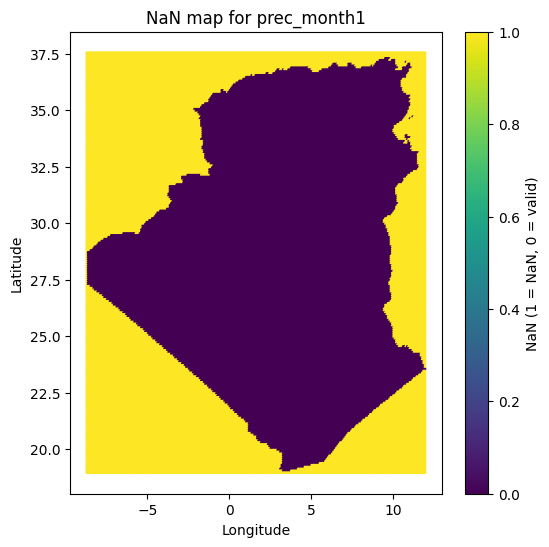

In [75]:
plt.figure(figsize=(6,6))
sc = plt.scatter(
    df_climate["longitude"],
    df_climate["latitude"],
    c=df_climate["prec_month1"].isna(),
    s=1,
    cmap="viridis"
)

plt.colorbar(sc, label="NaN (1 = NaN, 0 = valid)")
plt.title("NaN map for prec_month1")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [76]:
climate_cols = [c for c in df_climate.columns if "month" in c]
df_climate = df_climate.dropna(subset=climate_cols, how="all")


In [78]:
df_climate = df_climate.reset_index(drop=True)
df_climate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32791 entries, 0 to 32790
Data columns (total 38 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   longitude     32791 non-null  float64
 1   latitude      32791 non-null  float64
 2   prec_month1   32791 non-null  float32
 3   prec_month2   32791 non-null  float32
 4   prec_month3   32791 non-null  float32
 5   prec_month4   32791 non-null  float32
 6   prec_month5   32791 non-null  float32
 7   prec_month6   32791 non-null  float32
 8   prec_month7   32791 non-null  float32
 9   prec_month8   32791 non-null  float32
 10  prec_month9   32791 non-null  float32
 11  prec_month10  32791 non-null  float32
 12  prec_month11  32791 non-null  float32
 13  prec_month12  32791 non-null  float32
 14  tmax_month1   32791 non-null  float32
 15  tmax_month2   32791 non-null  float32
 16  tmax_month3   32791 non-null  float32
 17  tmax_month4   32791 non-null  float32
 18  tmax_month5   32791 non-nu

In [79]:
def make_season(df, feature):
    df[f"{feature}_winter"] = df[[f"{feature}_month12",
                                 f"{feature}_month1",
                                 f"{feature}_month2"]].mean(axis=1)

    df[f"{feature}_spring"] = df[[f"{feature}_month3",
                                 f"{feature}_month4",
                                 f"{feature}_month5"]].mean(axis=1)

    df[f"{feature}_summer"] = df[[f"{feature}_month6",
                                 f"{feature}_month7",
                                 f"{feature}_month8"]].mean(axis=1)

    df[f"{feature}_fall"] = df[[f"{feature}_month9",
                               f"{feature}_month10",
                               f"{feature}_month11"]].mean(axis=1)

# Apply to all 3 features
make_season(df_climate, "prec")
make_season(df_climate, "tmax")
make_season(df_climate, "tmin")


In [80]:
monthly_cols = [col for col in df_climate.columns if "_month" in col]
df_climate = df_climate.drop(columns=monthly_cols)


In [81]:
df_climate.head()

,longitude,latitude,prec_winter,prec_spring,prec_summer,prec_fall,tmax_winter,tmax_spring,tmax_summer,tmax_fall,tmin_winter,tmin_spring,tmin_summer,tmin_fall
0,9.541667,37.291667,80.641670,26.216667,4.091667,43.299999,16.583334,21.416666,31.333334,25.250000,8.416667,11.916667,20.833334,16.500000
1,9.625000,37.291667,77.791664,25.383337,4.133334,43.241669,16.666666,21.750000,31.583334,25.666666,8.250000,11.750000,20.750000,16.250000
2,9.708333,37.291667,74.816666,24.641665,4.283333,43.699997,16.750000,22.000000,31.916666,26.166666,8.250000,11.666667,20.666666,16.166666
3,9.791667,37.291667,72.299995,24.641668,4.358334,43.891666,16.833334,22.000000,32.333332,26.333334,8.333333,11.666667,20.666666,16.250000
4,9.208333,37.208333,88.300011,28.158335,4.091667,44.033337,17.000000,21.750000,31.333334,25.666666,8.750000,12.416667,21.000000,16.833334


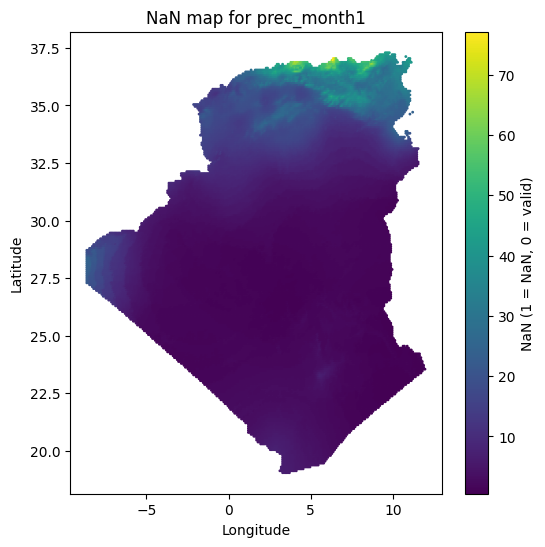

In [86]:
plt.figure(figsize=(6,6))
sc = plt.scatter(
    df_climate["longitude"],
    df_climate["latitude"],
    c=df_climate["prec_fall"],
    s=1,
    cmap="viridis"
)

plt.colorbar(sc, label="NaN (1 = NaN, 0 = valid)")
plt.title("NaN map for prec_month1")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

merging climate with fire using: nearest neighbors.

Choose how many nearest climate points to average


In [112]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
K = 4


Seasonal variables in climate dataset


In [113]:
seasonal_vars = [
    'prec_winter','prec_spring','prec_summer','prec_fall',
    'tmax_winter','tmax_spring','tmax_summer','tmax_fall',
    'tmin_winter','tmin_spring','tmin_summer','tmin_fall'
]

Extract coordinates of climate points


In [114]:
climate_coords = df_climate[['lat','lon']].values

Fit nearest neighbors model


In [ ]:
# Build the KNN model
nn_model = NearestNeighbors(n_neighbors=K, algorithm='auto')
nn_model.fit(climate_coords)


,n_neighbors,4
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,None


In [115]:
# Coordinates of fire/non-fire points
fire_coords = df_final_clipped[['lat', 'lon']].values  # (n_fire, 2)

# Find K nearest neighbors for all fire points at once
distances, indices = nn_model.kneighbors(fire_coords)  # indices shape: (n_fire, K)

# Stack climate seasonal variables into NumPy array
climate_values = df_climate[seasonal_vars].to_numpy()  # shape: (n_climate, 12)

# Get the K-neighbor values for all points
neighbor_values = climate_values[indices]  # shape: (n_fire, K, 12)

# Take mean along the K neighbors
averaged_values = neighbor_values.mean(axis=1)  # shape: (n_fire, 12)

# Assign averaged values back to df_final_clipped
df_final_clipped[seasonal_vars] = averaged_values

In [116]:
print(df_final_clipped[seasonal_vars].isna().sum())


prec_winter    0
prec_spring    0
prec_summer    0
prec_fall      0
tmax_winter    0
tmax_spring    0
tmax_summer    0
tmax_fall      0
tmin_winter    0
tmin_spring    0
tmin_summer    0
tmin_fall      0
dtype: int64


In [117]:
print(df_final_clipped[seasonal_vars].describe())


        prec_winter   prec_spring   prec_summer     prec_fall   tmax_winter  \
count  2.337126e+06  2.337126e+06  2.337126e+06  2.337126e+06  2.337126e+06   
mean   6.893497e+00  4.943941e+00  2.411054e+00  7.238431e+00  2.108926e+01   
std    1.631384e+01  7.327064e+00  2.598299e+00  9.635613e+00  3.694271e+00   
min    0.000000e+00  0.000000e+00  0.000000e+00  5.000000e-01  7.479167e+00   
25%    7.479166e-01  8.562500e-01  5.291666e-01  1.564583e+00  1.927083e+01   
50%    2.083333e+00  2.022917e+00  1.233333e+00  2.800000e+00  2.133333e+01   
75%    4.064583e+00  5.093750e+00  3.547917e+00  8.629167e+00  2.387500e+01   
max    1.975375e+02  5.474792e+01  1.383125e+01  7.465625e+01  2.862500e+01   

        tmax_spring   tmax_summer     tmax_fall   tmin_winter   tmin_spring  \
count  2.337126e+06  2.337126e+06  2.337126e+06  2.337126e+06  2.337126e+06   
mean   3.143200e+01  4.097151e+01  3.178704e+01  6.712864e+00  1.635882e+01   
std    4.550575e+00  3.553043e+00  3.691788e+00  2.

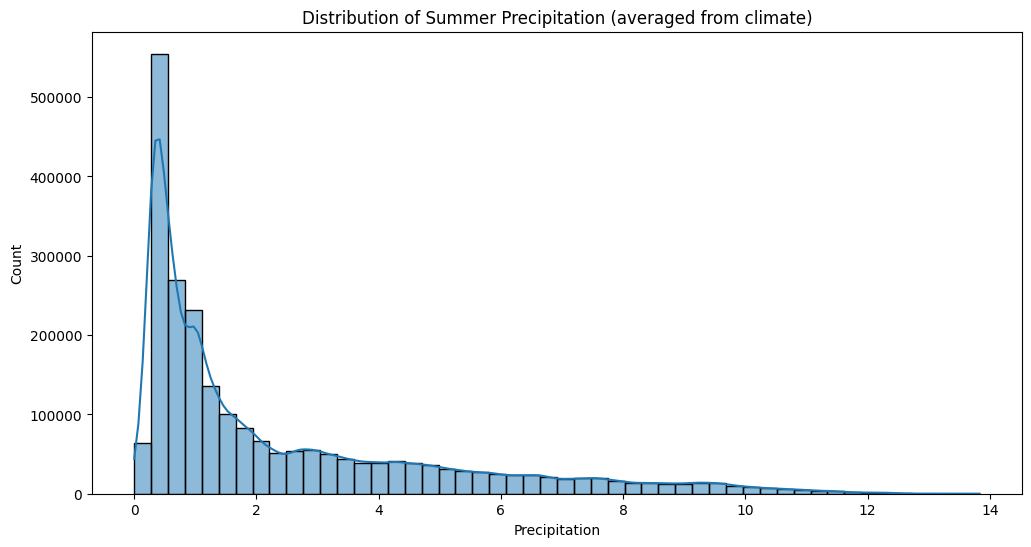

In [118]:
plt.figure(figsize=(12,6))
sns.histplot(df_final_clipped['prec_summer'], bins=50, kde=True)
plt.title("Distribution of Summer Precipitation (averaged from climate)")
plt.xlabel("Precipitation")
plt.ylabel("Count")
plt.show()


c:\Program Files\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


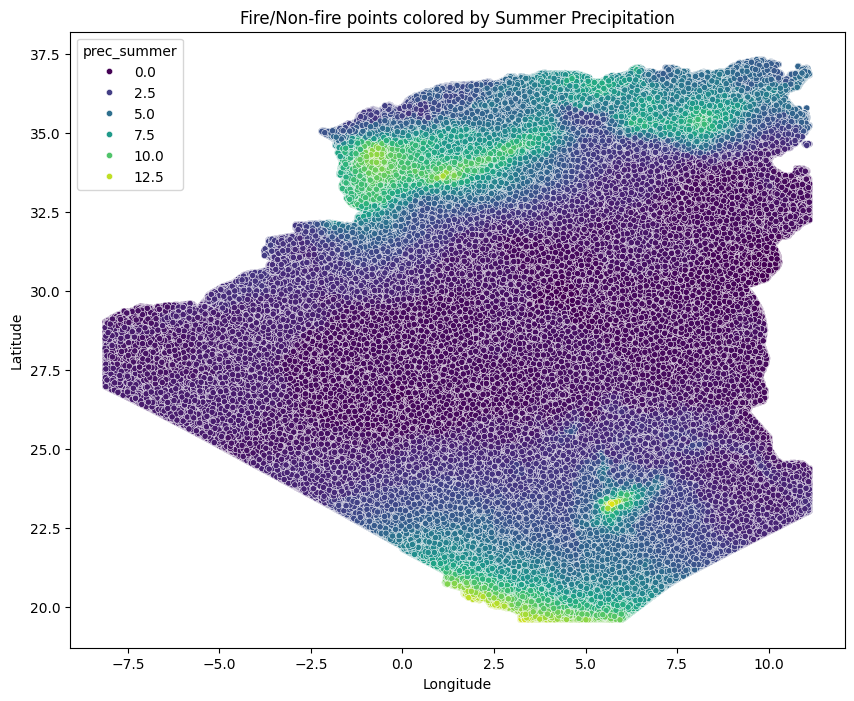

In [119]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=df_final_clipped,
    x='lon', y='lat',
    hue='prec_summer',  # or any variable
    palette='viridis',
    s=20
)
plt.title("Fire/Non-fire points colored by Summer Precipitation")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


c:\Program Files\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


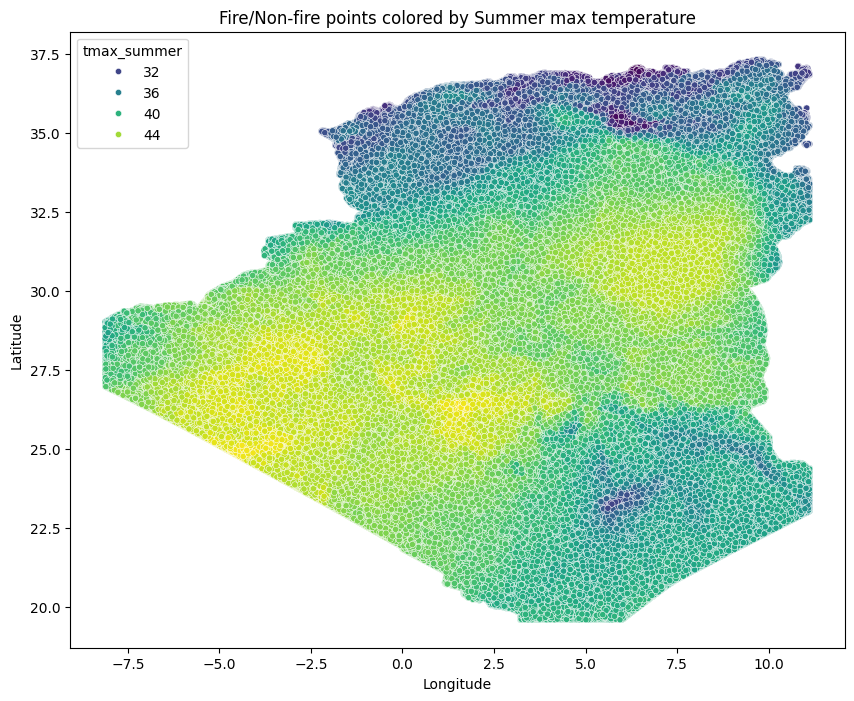

In [120]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=df_final_clipped,
    x='lon', y='lat',
    hue='tmax_summer',  # or any variable
    palette='viridis',
    s=20
)
plt.title("Fire/Non-fire points colored by Summer max temperature")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [8]:
"""df_final_clipped.to_pickle("data\Fire_with_climate.pkl")


df_final_clipped.to_pickle("data/processed/Fire_with_climate.pkl")"""

df_final_clipped.to_pickle("data/data/processed/Fire_with_climate.pkl")




<>:1: SyntaxWarning: invalid escape sequence '\F'
<>:1: SyntaxWarning: invalid escape sequence '\F'
C:\Users\HOME\AppData\Local\Temp\ipykernel_6188\601228958.py:1: SyntaxWarning: invalid escape sequence '\F'
  """df_final_clipped.to_pickle("data\Fire_with_climate.pkl")


NameError: name 'df_final_clipped' is not defined

## df_fire_climate

In [3]:
df_fire_with_climate.head()

,lat,lon,fire,prec_winter,prec_spring,prec_summer,prec_fall,tmax_winter,tmax_spring,tmax_summer,tmax_fall,tmin_winter,tmin_spring,tmin_summer,tmin_fall
0,27.73594,9.17977,1,2.254167,3.081250,0.333333,1.225000,21.749998,33.416668,43.166664,33.645832,5.270833,16.833332,26.708332,18.020834
1,30.47030,6.47282,1,3.137500,3.360417,0.375000,2.468750,21.125000,32.729168,44.666668,33.812500,6.625000,17.187500,28.645832,19.604166
2,32.27604,3.98588,1,1.791667,4.393750,1.241667,8.404167,18.979168,29.437500,41.708332,30.104168,6.958333,15.333333,27.250000,17.666666
3,31.39343,6.93652,1,3.337500,5.802083,0.587500,3.887500,20.666666,32.666668,44.666668,33.833336,6.687500,17.333334,29.000000,19.979166
4,36.49926,8.95615,1,47.950001,27.095833,4.943750,31.379166,17.104168,24.062502,36.541668,27.729166,6.583333,11.000000,20.979166,15.270833


### merge_avec_landcover

In [14]:
merged_countries_landcover_no_legend.head()


,ID,AREA_M2,geometry,LCCCode,GRIDCODE
0,4,6.228187e+06,"POLYGON ((6.41528 37.08696, 6.43103 37.0855, 6...",7001 // 8001,210
1,2,6.242408e+06,"POLYGON ((7.18084 37.07917, 7.17998 37.08091, ...",7001 // 8001,210
2,1,1.482995e+06,"POLYGON ((7.37137 37.08194, 7.3709 37.08717, 7...",7001 // 8001,210
3,8,4.590841e+08,"POLYGON ((6.12361 36.68472, 6.12361 36.69306, ...",21497-121340,50
4,13,6.371533e+06,"POLYGON ((6.26181 37.02361, 6.26193 37.02514, ...",7001 // 8001,210


In [27]:

# -----------------------------
# 1. Convertir les coordonnées Fire_Climate en GeoDataFrame temporaire
# -----------------------------
gdf_fire_temp = gpd.GeoDataFrame(
    df_fire_with_climate.copy(),  # on garde toutes les colonnes originales
    geometry=[Point(xy) for xy in zip(df_fire_with_climate['lon'], df_fire_with_climate['lat'])],
    crs="EPSG:4326"
)

# -----------------------------
# 2. Préparer Land Cover (geometry + LCCCode)
# -----------------------------
gdf_landcover_merge = merged_countries_landcover_no_legend[['geometry', 'LCCCode']].copy()
gdf_landcover_merge = gdf_landcover_merge.to_crs("EPSG:4326")

# -----------------------------
# 3. Fusion spatiale Fire + Land Cover
# -----------------------------
gdf_fire_landcover = gpd.sjoin(
    gdf_fire_temp,
    gdf_landcover_merge,
    how="left",
    predicate="within"
)

# -----------------------------
# 4. Créer le dataframe final sans geometry ni index_right
# -----------------------------
df_fire_landcover_final = gdf_fire_landcover.drop(columns=['geometry', 'index_right'])

# Remplacer les NaN dans LCCCode par 'Unknown'
df_fire_landcover_final['LCCCode'] = df_fire_landcover_final['LCCCode'].fillna('Unknown')

# Vérifier le résultat
print(df_fire_landcover_final.head())
print(df_fire_landcover_final.columns)


        lat      lon  fire  prec_winter  prec_spring  prec_summer  prec_fall  \
0  27.73594  9.17977     1     2.254167     3.081250     0.333333   1.225000   
1  30.47030  6.47282     1     3.137500     3.360417     0.375000   2.468750   
2  32.27604  3.98588     1     1.791667     4.393750     1.241667   8.404167   
3  31.39343  6.93652     1     3.337500     5.802083     0.587500   3.887500   
4  36.49926  8.95615     1    47.950001    27.095833     4.943750  31.379166   

   tmax_winter  tmax_spring  tmax_summer  tmax_fall  tmin_winter  tmin_spring  \
0    21.749998    33.416668    43.166664  33.645832     5.270833    16.833332   
1    21.125000    32.729168    44.666668  33.812500     6.625000    17.187500   
2    18.979168    29.437500    41.708332  30.104168     6.958333    15.333333   
3    20.666666    32.666668    44.666668  33.833336     6.687500    17.333334   
4    17.104168    24.062502    36.541668  27.729166     6.583333    11.000000   

   tmin_summer  tmin_fall LCCCod

In [28]:
output_path = "data/processed/df_fire_climate_land_cover.pkl"
df_fire_landcover_final.to_pickle(output_path)
print(f" Dataset saved as pickle at: {output_path}")


 Dataset saved as pickle at: data/processed/df_fire_climate_land_cover.pkl


### merge_avec_elevation

In [29]:
import numpy as np
from scipy.spatial import cKDTree

In [30]:
# -----------------------------
# 1. Préparer arrays NumPy pour l'elevation
# -----------------------------
elev_x = df_elev['x'].to_numpy()
elev_y = df_elev['y'].to_numpy()
elev_values = df_elev['elevation'].to_numpy()

# Créer un arbre KD pour recherche rapide
tree = cKDTree(np.column_stack((elev_x, elev_y)))

# -----------------------------
# 2. Préparer points de fire_climate_land_cover
# -----------------------------
fire_points = np.column_stack((df_fire_landcover_final['lon'], df_fire_landcover_final['lat']))

# -----------------------------
# 3. Trouver l'index du pixel d'elevation le plus proche
# -----------------------------
distances, indices = tree.query(fire_points, k=1)  # k=1 pour le plus proche

# -----------------------------
# 4. Récupérer l'élévation correspondante
# -----------------------------
fire_elevation = elev_values[indices]

# -----------------------------
# 5. Créer df_fire_landcover_final_2 + ajouter elevation
# -----------------------------
df_fire_landcover_final_2 = df_fire_landcover_final.copy()
df_fire_landcover_final_2['elevation'] = fire_elevation

# -----------------------------
# 6. Vérification
# -----------------------------
print(df_fire_landcover_final_2.head())


        lat      lon  fire  prec_winter  prec_spring  prec_summer  prec_fall  \
0  27.73594  9.17977     1     2.254167     3.081250     0.333333   1.225000   
1  30.47030  6.47282     1     3.137500     3.360417     0.375000   2.468750   
2  32.27604  3.98588     1     1.791667     4.393750     1.241667   8.404167   
3  31.39343  6.93652     1     3.337500     5.802083     0.587500   3.887500   
4  36.49926  8.95615     1    47.950001    27.095833     4.943750  31.379166   

   tmax_winter  tmax_spring  tmax_summer  tmax_fall  tmin_winter  tmin_spring  \
0    21.749998    33.416668    43.166664  33.645832     5.270833    16.833332   
1    21.125000    32.729168    44.666668  33.812500     6.625000    17.187500   
2    18.979168    29.437500    41.708332  30.104168     6.958333    15.333333   
3    20.666666    32.666668    44.666668  33.833336     6.687500    17.333334   
4    17.104168    24.062502    36.541668  27.729166     6.583333    11.000000   

   tmin_summer  tmin_fall LCCCod

In [31]:
output_path = "data/processed/df_fire_climate_land_cover_elevation.pkl"
df_fire_landcover_final_2.to_pickle(output_path)
print(f" Dataset saved as pickle at: {output_path}")


 Dataset saved as pickle at: data/processed/df_fire_climate_land_cover_elevation.pkl


## merge_avec_soil


In [5]:
# ============================================================
#                     IMPORTS
# ============================================================
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
import pickle


# ============================================================
#   PRÉPARATION DU KDTree POUR LE SOL
# ============================================================

print("Preparing KDTree for Soil...")

# Coordonnées du sol
soil_x = df_pixels["x"].to_numpy()
soil_y = df_pixels["y"].to_numpy()

# Colonnes de propriétés du sol
soil_properties = df_pixels.drop(columns=["x", "y", "MU_ID"]).columns

# Valeurs des propriétés (tableau numpy)
soil_values = df_pixels[soil_properties].to_numpy()

# Construction du KDTree
soil_tree = cKDTree(np.column_stack((soil_x, soil_y)))

print("KDTree ready.")

# ============================================================
#   PRÉPARATION DES POINTS FIRE
# ============================================================

fire_xy = np.column_stack((
    df_fire_landcover_final_2["lon"],
    df_fire_landcover_final_2["lat"]
))

print("Fire coordinates prepared:", fire_xy.shape)

# ============================================================
#   RECHERCHE DU PIXEL DU SOL LE PLUS PROCHE
# ============================================================

print("Querying nearest soil pixel...")

soil_dist, soil_idx = soil_tree.query(fire_xy, k=1)

print("Nearest neighbor search completed.")

# ============================================================
#   EXTRACTION DES VALEURS CORRESPONDANTES DU SOL
# ============================================================

fire_soil_values = soil_values[soil_idx]

print("Soil values extracted:", fire_soil_values.shape)

# ============================================================
#   CRÉATION DU DATASET FINAL df_fire_landcover_final_3
# ============================================================

df_fire_landcover_final_3 = df_fire_landcover_final_2.copy()

# Ajouter toutes les colonnes de sol
for i, col in enumerate(soil_properties):
    df_fire_landcover_final_3[col] = fire_soil_values[:, i]

print("Final dataset created:", df_fire_landcover_final_3.shape)



Preparing KDTree for Soil...
KDTree ready.
Fire coordinates prepared: (2337126, 2)
Querying nearest soil pixel...
Nearest neighbor search completed.
Soil values extracted: (2337126, 22)
Final dataset created: (2337126, 39)


In [6]:
# ============================================================
#   8. VÉRIFICATION DU DATASET FINAL
# ============================================================

# Afficher les 5 premières lignes
print(df_fire_landcover_final_3.head())

# Vérifier la forme (nombre de lignes et colonnes)
print("Shape:", df_fire_landcover_final_3.shape)

# Lister toutes les colonnes
print("Columns:", df_fire_landcover_final_3.columns.tolist())

# Vérifier les valeurs manquantes
missing_counts = df_fire_landcover_final_3.isna().sum()
print("Missing values per column:\n", missing_counts)

# Vérifier les types de données
print(df_fire_landcover_final_3.dtypes)


        lat      lon  fire  prec_winter  prec_spring  prec_summer  prec_fall  \
0  27.73594  9.17977     1     2.254167     3.081250     0.333333   1.225000   
1  30.47030  6.47282     1     3.137500     3.360417     0.375000   2.468750   
2  32.27604  3.98588     1     1.791667     4.393750     1.241667   8.404167   
3  31.39343  6.93652     1     3.337500     5.802083     0.587500   3.887500   
4  36.49926  8.95615     1    47.950001    27.095833     4.943750  31.379166   

   tmax_winter  tmax_spring  tmax_summer  ...  CEC_SOIL  CEC_CLAY  CEC_EFF  \
0    21.749998    33.416668    43.166664  ...        13        74     30.0   
1    21.125000    32.729168    44.666668  ...        13        74     30.0   
2    18.979168    29.437500    41.708332  ...        13        74     30.0   
3    20.666666    32.666668    44.666668  ...        -4        -4     -4.0   
4    17.104168    24.062502    36.541668  ...        17        62     18.0   

    TEB  BSAT ALUM_SAT  ESP TCARBON_EQ GYPSUM ELEC

In [ ]:
output_path = "data/processed/df_fire_landcover_final_3.pkl"
df_fire_landcover_final_3.to_pickle(output_path)
print(f" Dataset saved as pickle at: {output_path}")



 Dataset saved at: data/processed/df_fire_landcover_final_3.pkl


In [11]:
df_fire_landcover_final_4 = df_fire_landcover_final_3.copy()


In [12]:
# Colonnes de sol
first_soil_col = "COARSE"
soil_cols_final = df_fire_landcover_final_4.columns[
    df_fire_landcover_final_4.columns.get_loc(first_soil_col):
].tolist()

# Séparer numériques et catégorielles
numeric_soil_cols = [col for col in soil_cols_final if pd.api.types.is_numeric_dtype(df_fire_landcover_final_4[col])]
non_numeric_soil_cols = [col for col in soil_cols_final if not pd.api.types.is_numeric_dtype(df_fire_landcover_final_4[col])]

# Remplissage global
for col in numeric_soil_cols:
    df_fire_landcover_final_4[col] = df_fire_landcover_final_4[col].fillna(df_fire_landcover_final_4[col].median())

for col in non_numeric_soil_cols:
    mode = df_fire_landcover_final_4[col].mode()
    df_fire_landcover_final_4[col] = df_fire_landcover_final_4[col].fillna(mode[0] if not mode.empty else "Unknown")

# Vérification
missing_summary_after = df_fire_landcover_final_4[soil_cols_final].isna().sum()
print("Nombre de valeurs manquantes après remplissage global :")
print(missing_summary_after)


Nombre de valeurs manquantes après remplissage global :
COARSE           0
SAND             0
SILT             0
CLAY             0
TEXTURE_USDA     0
TEXTURE_SOTER    0
BULK             0
REF_BULK         0
ORG_CARBON       0
PH_WATER         0
TOTAL_N          0
CN_RATIO         0
CEC_SOIL         0
CEC_CLAY         0
CEC_EFF          0
TEB              0
BSAT             0
ALUM_SAT         0
ESP              0
TCARBON_EQ       0
GYPSUM           0
ELEC_COND        0
dtype: int64


In [13]:
output_path = "data/processed/df_fire_landcover_final_4.pkl"
df_fire_landcover_final_4.to_pickle(output_path)
print(f"Dataset saved as pickle at: {output_path}")


Dataset saved as pickle at: data/processed/df_fire_landcover_final_4.pkl


In [19]:
# ============================================================
#   8. VÉRIFICATION DU DATASET FINAL
# ============================================================

# Afficher les 5 premières lignes
print(df_fire_landcover_final_4.head())

# Vérifier la forme (nombre de lignes et colonnes)
print("Shape:", df_fire_landcover_final_4.shape)

# Lister toutes les colonnes
print("Columns:", df_fire_landcover_final_4.columns.tolist())

# Vérifier les valeurs manquantes
missing_counts = df_fire_landcover_final_4.isna().sum()
print("Missing values per column:\n", missing_counts)

# Vérifier les types de données
print(df_fire_landcover_final_4.dtypes)


        lat      lon  fire  prec_winter  prec_spring  prec_summer  prec_fall  \
0  27.73594  9.17977     1     2.254167     3.081250     0.333333   1.225000   
1  30.47030  6.47282     1     3.137500     3.360417     0.375000   2.468750   
2  32.27604  3.98588     1     1.791667     4.393750     1.241667   8.404167   
3  31.39343  6.93652     1     3.337500     5.802083     0.587500   3.887500   
4  36.49926  8.95615     1    47.950001    27.095833     4.943750  31.379166   

   tmax_winter  tmax_spring  tmax_summer  ...  CEC_SOIL  CEC_CLAY  CEC_EFF  \
0    21.749998    33.416668    43.166664  ...      13.0      74.0     30.0   
1    21.125000    32.729168    44.666668  ...      13.0      74.0     30.0   
2    18.979168    29.437500    41.708332  ...      13.0      74.0     30.0   
3    20.666666    32.666668    44.666668  ...      13.0      67.0     30.0   
4    17.104168    24.062502    36.541668  ...      17.0      62.0     18.0   

    TEB   BSAT ALUM_SAT  ESP  TCARBON_EQ  GYPSUM  

C:\Users\HOME\AppData\Local\Temp\ipykernel_19284\29223589.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fires_per_bin = df_fire_landcover_final_4.groupby('lat_bin')['fire'].sum()


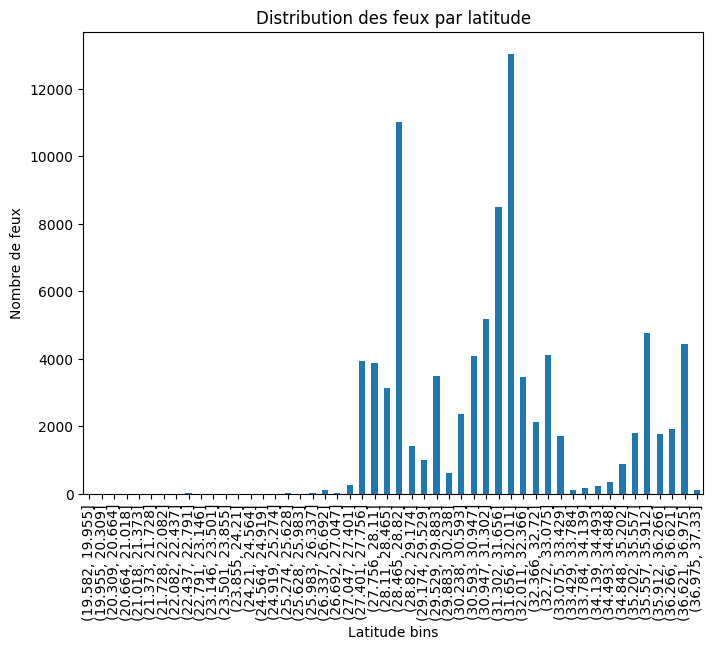

In [20]:
import matplotlib.pyplot as plt

# Compter le nombre de feux par tranche de latitude
df_fire_landcover_final_4['lat_bin'] = pd.cut(df_fire_landcover_final_4['lat'], bins=50)  # divise en 50 intervalles
fires_per_bin = df_fire_landcover_final_4.groupby('lat_bin')['fire'].sum()

# Visualiser
plt.figure(figsize=(8,6))
fires_per_bin.plot(kind='bar')
plt.xlabel('Latitude bins')
plt.ylabel('Nombre de feux')
plt.title('Distribution des feux par latitude')
plt.show()


## Decouper_Le_DataSet


In [21]:
df_fire_landcover_final_5 = df_fire_landcover_final_4[
    df_fire_landcover_final_4['lat'] >= 30.0
].copy()


In [ ]:
print("Nombre de points après filtrage :", len(df_fire_landcover_final_5))
print(df_fire_landcover_final_5['lat'].min(), df_fire_landcover_final_5['lat'].max())
print("=== Aperçu du DataFrame filtré ===")
print(df_fire_landcover_final_5.shape)
print(df_fire_landcover_final_5.head())


Nombre de points après filtrage : 921533
30.0 37.33
=== Aperçu du DataFrame filtré ===
(921533, 40)
        lat      lon  fire  prec_winter  prec_spring  prec_summer  prec_fall  \
1  30.47030  6.47282     1     3.137500     3.360417     0.375000   2.468750   
2  32.27604  3.98588     1     1.791667     4.393750     1.241667   8.404167   
3  31.39343  6.93652     1     3.337500     5.802083     0.587500   3.887500   
4  36.49926  8.95615     1    47.950001    27.095833     4.943750  31.379166   
7  31.18856  6.78761     1     3.481250     5.089583     0.600000   3.768750   

   tmax_winter  tmax_spring  tmax_summer  ...  CEC_CLAY  CEC_EFF   TEB   BSAT  \
1    21.125000    32.729168    44.666668  ...      74.0     30.0  30.0  100.0   
2    18.979168    29.437500    41.708332  ...      74.0     30.0  30.0  100.0   
3    20.666666    32.666668    44.666668  ...      67.0     30.0  30.0   99.0   
4    17.104168    24.062502    36.541668  ...      62.0     18.0  17.0   87.0   
7    21.000000

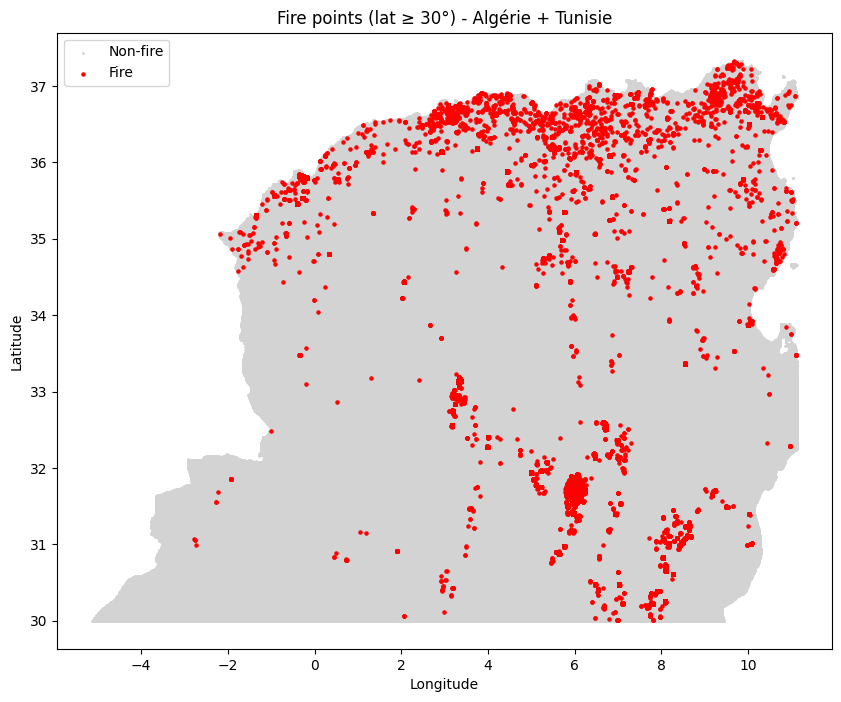

In [ ]:
# --- 1. Créer la figure ---
plt.figure(figsize=(10, 8))

# --- 2. Tracer les points non-feu en gris clair ---
plt.scatter(
    df_fire_landcover_final_5[df_fire_landcover_final_5['fire'] == 0]['lon'],
    df_fire_landcover_final_5[df_fire_landcover_final_5['fire'] == 0]['lat'],
    s=1,
    color='lightgrey',
    label='Non-fire'
)

# --- 3. Tracer les points feu en rouge ---
plt.scatter(
    df_fire_landcover_final_5[df_fire_landcover_final_5['fire'] == 1]['lon'],
    df_fire_landcover_final_5[df_fire_landcover_final_5['fire'] == 1]['lat'],
    s=5,
    color='red',
    label='Fire'
)

# --- 4. Personnalisation ---
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Fire points (lat ≥ 30°) - Algérie + Tunisie")
plt.legend()
plt.show()


In [27]:
output_path = "data/processed/df_fire_landcover_final_5.pkl"
df_fire_landcover_final_5.to_pickle(output_path)
print(f"Dataset saved as pickle at: {output_path}")


Dataset saved as pickle at: data/processed/df_fire_landcover_final_5.pkl


In [30]:
# Comptage des occurrences
counts = df_fire_landcover_final_5['fire'].value_counts()
total = len(df_fire_landcover_final_5)

# Pourcentages
percentages = counts / total * 100

print("Nombre de points par catégorie de feu :")
print(counts)
print("\nPourcentage de points par catégorie de feu :")
print(percentages)


Nombre de points par catégorie de feu :
fire
0    859737
1     61796
Name: count, dtype: int64

Pourcentage de points par catégorie de feu :
fire
0    93.294217
1     6.705783
Name: count, dtype: float64


In [8]:
df_fire_landcover_final_cut.head()

,lat,lon,fire,prec_winter,prec_spring,prec_summer,prec_fall,tmax_winter,tmax_spring,tmax_summer,...,CEC_SOIL,CEC_CLAY,CEC_EFF,TEB,BSAT,ALUM_SAT,ESP,TCARBON_EQ,GYPSUM,ELEC_COND
0,27.73594,9.17977,1,2.254167,3.081250,0.333333,1.225000,21.749998,33.416668,43.166664,...,13.0,74.0,30.0,30.0,100.0,0.0,3.0,8.0,4.0,1.0
1,30.47030,6.47282,1,3.137500,3.360417,0.375000,2.468750,21.125000,32.729168,44.666668,...,13.0,74.0,30.0,30.0,100.0,0.0,3.0,8.0,4.0,1.0
2,32.27604,3.98588,1,1.791667,4.393750,1.241667,8.404167,18.979168,29.437500,41.708332,...,13.0,74.0,30.0,30.0,100.0,0.0,3.0,8.0,4.0,1.0
3,31.39343,6.93652,1,3.337500,5.802083,0.587500,3.887500,20.666666,32.666668,44.666668,...,13.0,67.0,30.0,30.0,99.0,0.0,3.0,8.0,0.7,1.0
4,36.49926,8.95615,1,47.950001,27.095833,4.943750,31.379166,17.104168,24.062502,36.541668,...,17.0,62.0,18.0,17.0,87.0,0.0,2.0,6.0,0.6,2.0


## Making the non-fire grid smaller

``we noticed that with using 0.01 the ratio of fire points to non-fire points was so little so we decided to make the non-fire grid bigger : 0.02``

In [9]:
# Separate fire and non-fire points
df_fire = df_fire_landcover_final_cut[df_fire_landcover_final_cut['fire'] == 1]
df_non_fire = df_fire_landcover_final_cut[df_fire_landcover_final_cut['fire'] == 0]

# Approximate 2 km grid in degrees
lat_spacing = 0.018  # ~2 km
# For longitude, use cos(latitude) to approximate spacing
df_non_fire['lon_spacing'] = lat_spacing / np.cos(np.radians(df_non_fire['lat']))

# Assign each point to a grid cell
df_non_fire['lat_cell'] = (df_non_fire['lat'] / lat_spacing).astype(int)
df_non_fire['lon_cell'] = (df_non_fire['lon'] / df_non_fire['lon_spacing']).astype(int)

# Keep only one point per cell
df_non_fire_grid = df_non_fire.drop_duplicates(subset=['lat_cell', 'lon_cell'])

# Combine with all fire points
df_2km = pd.concat([df_fire, df_non_fire_grid])

# Shuffle
df_2km = df_2km.sample(frac=1, random_state=42).reset_index(drop=True)

# Check counts
print("Nombre de points par catégorie de feu :")
print(df_2km['fire'].value_counts())

print("\nPourcentage de points par catégorie de feu :")
print(df_2km['fire'].value_counts(normalize=True) * 100)




C:\Users\dell\AppData\Local\Temp\ipykernel_22864\2426223177.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_fire['lon_spacing'] = lat_spacing / np.cos(np.radians(df_non_fire['lat']))
C:\Users\dell\AppData\Local\Temp\ipykernel_22864\2426223177.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_fire['lat_cell'] = (df_non_fire['lat'] / lat_spacing).astype(int)
C:\Users\dell\AppData\Local\Temp\ipykernel_22864\2426223177.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of

Nombre de points par catégorie de feu :
fire
0    339967
1     89053
Name: count, dtype: int64

Pourcentage de points par catégorie de feu :
fire
0    79.242693
1    20.757307
Name: proportion, dtype: float64


In [13]:
# Drop the helper columns
df_2km = df_2km.drop(columns=['lat_cell', 'lon_cell', 'lon_spacing'], errors='ignore')

# check columns
print(df_2km.columns)



Index(['lat', 'lon', 'fire', 'prec_winter', 'prec_spring', 'prec_summer',
       'prec_fall', 'tmax_winter', 'tmax_spring', 'tmax_summer', 'tmax_fall',
       'tmin_winter', 'tmin_spring', 'tmin_summer', 'tmin_fall', 'LCCCode',
       'elevation', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA',
       'TEXTURE_SOTER', 'BULK', 'REF_BULK', 'ORG_CARBON', 'PH_WATER',
       'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT',
       'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND'],
      dtype='object')


In [14]:
# Check how many full duplicate rows exist
num_dupes = df_2km.duplicated().sum()
print("Number of full duplicate rows:", num_dupes)

# Remove full duplicates
df_2km = df_2km.drop_duplicates()

# Reset index after dropping
df_2km = df_2km.reset_index(drop=True)

# Optional: confirm
print("Total rows after removing duplicates:", len(df_2km))


Number of full duplicate rows: 61
Total rows after removing duplicates: 428959


c:\Program Files\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


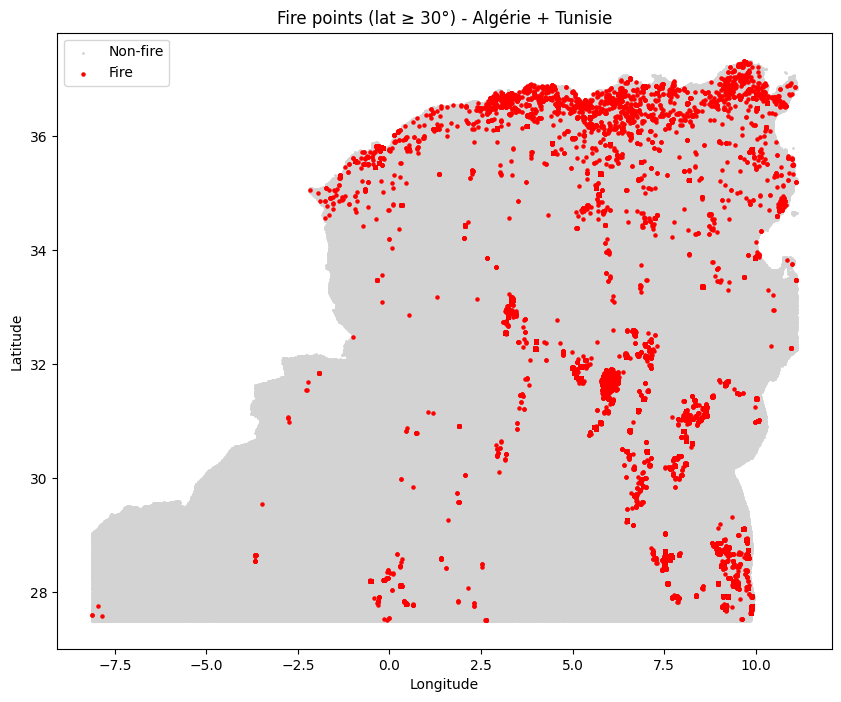

In [15]:
# --- 1. Créer la figure ---
plt.figure(figsize=(10, 8))

# --- 2. Tracer les points non-feu en gris clair ---
plt.scatter(
    df_2km[df_2km['fire'] == 0]['lon'],
    df_2km[df_2km['fire'] == 0]['lat'],
    s=1,
    color='lightgrey',
    label='Non-fire'
)

# --- 3. Tracer les points feu en rouge ---
plt.scatter(
    df_2km[df_2km['fire'] == 1]['lon'],
    df_2km[df_2km['fire'] == 1]['lat'],
    s=5,
    color='red',
    label='Fire'
)

# --- 4. Personnalisation ---
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Fire points (lat ≥ 30°) - Algérie + Tunisie")
plt.legend()
plt.show()

In [16]:
df_2km.dtypes


lat              float64
lon              float64
fire               int64
prec_winter      float32
prec_spring      float32
prec_summer      float32
prec_fall        float32
tmax_winter      float32
tmax_spring      float32
tmax_summer      float32
tmax_fall        float32
tmin_winter      float32
tmin_spring      float32
tmin_summer      float32
tmin_fall        float32
LCCCode           object
elevation          int16
COARSE           float64
SAND             float64
SILT             float64
CLAY             float64
TEXTURE_USDA      object
TEXTURE_SOTER     object
BULK             float64
REF_BULK         float64
ORG_CARBON       float64
PH_WATER         float64
TOTAL_N          float64
CN_RATIO         float64
CEC_SOIL         float64
CEC_CLAY         float64
CEC_EFF          float64
TEB              float64
BSAT             float64
ALUM_SAT         float64
ESP              float64
TCARBON_EQ       float64
GYPSUM           float64
ELEC_COND        float64
dtype: object

In [24]:
print(df_2km.head(50))


         lat       lon  fire  prec_winter  prec_spring  prec_summer  \
0   30.29000  -1.32000     0     2.022917     1.468750     1.639583   
1   30.08000  -1.22000     0     1.877083     1.364583     1.645833   
2   32.61000   1.10000     0     5.889583     3.704167     3.587500   
3   33.31000   0.74000     0    10.404167     7.195833     8.664583   
4   27.88000  -6.98000     0     3.131250     0.629167     0.693750   
5   36.33000   6.49000     0    77.695831    31.172918     6.206250   
6   36.55000   7.13000     0    91.168755    33.560417     5.462500   
7   31.01269   8.15791     1     2.587500     5.122917     0.341667   
8   29.42000   2.83000     0     1.254167     2.083333     0.602083   
9   32.78000  -1.11000     0     7.343750     6.514583     9.164583   
10  34.94000   4.51000     0    12.425000    11.172916     4.866667   
11  35.47000   8.36000     0    22.958334    29.972916     9.229166   
12  29.15000   4.10000     0     1.875000     2.056250     0.575000   
13  28

In [21]:
df_2km['fire'].value_counts(normalize=True)


fire
0    0.79254
1    0.20746
Name: proportion, dtype: float64

## Feature Engineering

### Feature Extraction

``we already did seasonal precipitation and tmax tmix, its part of feature extraction``

### Feature Selection

``no irrelevant features``

### Feature Encoding

In [25]:
# Show all unique values
df_2km['TEXTURE_USDA'].unique()


array([11.0, 'Unknown', 9.0, 5.0, 3.0, 12.0, 10.0, 7.0], dtype=object)

In [28]:
# Count unique values per column
unique_counts = df_2km.nunique()
print(unique_counts.sort_values())




fire                 2
TEXTURE_SOTER        4
ELEC_COND            6
TEXTURE_USDA         8
CN_RATIO            10
ALUM_SAT            12
ESP                 19
LCCCode             21
COARSE              25
GYPSUM              28
CEC_SOIL            29
BSAT                31
SILT                31
PH_WATER            31
CLAY                32
CEC_CLAY            41
BULK                42
REF_BULK            43
SAND                44
CEC_EFF             47
TEB                 50
TCARBON_EQ          54
TOTAL_N             70
ORG_CARBON          87
tmin_winter       1213
tmin_fall         1352
tmin_spring       1591
tmin_summer       1654
tmax_winter       1777
tmax_fall         1797
elevation         1899
tmax_summer       1977
tmax_spring       2050
prec_summer      11681
prec_spring      25690
prec_winter      28130
prec_fall        30285
lat              54944
lon              57816
dtype: int64


In [29]:
# List of categorical columns to encode
categorical_cols = ['TEXTURE_SOTER', 'ELEC_COND', 'TEXTURE_USDA', 'LCCCode']

# Convert everything to string first (important if there are numbers)
for col in categorical_cols:
    df_2km[col] = df_2km[col].astype(str)

# One-hot encode them, including a column for missing values if any
df_encoded = pd.get_dummies(df_2km, columns=categorical_cols, dummy_na=True)

# Check new shape
print("New dataset shape:", df_encoded.shape)


New dataset shape: (428959, 78)


## SAVING

In [30]:
# Folder path
save_dir = "data/processed"
os.makedirs(save_dir, exist_ok=True)  # Create folder if it doesn't exist

# File path
save_path = os.path.join(save_dir, "df_2km.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(df_2km, f);

In [31]:
# Folder path
save_dir = "data/processed"
os.makedirs(save_dir, exist_ok=True)  # Create folder if it doesn't exist

# File path
save_path = os.path.join(save_dir, "df_encoded.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(df_encoded, f);